# <a id='toc1_'></a>[Exploratory Data Analysis - EDA](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Exploratory Data Analysis - EDA](#toc1_)    
    - [Import and setup](#toc1_1_1_)    
  - [Upload of dataset](#toc1_2_)    
  - [Plotting for clearance](#toc1_3_)    
  - [First attempt - plot of one variable](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

### <a id='toc1_1_1_'></a>[Import and setup](#toc0_)

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from src.config import set_seeds, get_complete_path, MODELS_DIR
import src.pipeline as pipe
import src.models as mod
import src.models.nn as nn
import src.evaluation as eval
import src.visualization as visual
import src.reporting as rep
import pandas as pd
import tensorflow as tf
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

set_seeds()

Random seeds set to 42. Deterministic operations enabled.


## <a id='toc1_2_'></a>[Upload of dataset](#toc0_)

In [6]:
df = pipe.load_data()
display(df.head())

Dataset caricato: 65 anni, 28 variabili.


,Year,Agricultural land (% of land area),Agricultural land (sq. km),Agricultural raw materials exports (% of merchandise exports),Agricultural raw materials imports (% of merchandise imports),"Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value added (current US$)","Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)",Arable land (% of land area),Arable land (hectares per person),...,Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land under cereal production (hectares),Livestock production index (2014-2016 = 100),Permanent cropland (% of land area),Rural population,Rural population (% of total population),Rural population growth (annual %)
0,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20400656.0,40.639,NaN
1,1961,70.324028,206830.0,NaN,NaN,NaN,NaN,NaN,43.731937,0.254510,...,67.795055,85.93,NaN,NaN,6387203.0,70.91,9.336643,20287312.0,40.144,-0.557139
2,1962,70.218626,206520.0,2.563660,16.566057,NaN,NaN,NaN,43.504131,0.251477,...,69.362485,86.90,NaN,NaN,6485855.0,72.59,9.435245,20171158.0,39.645,-0.574190
3,1963,69.735813,205100.0,2.651714,14.571604,NaN,NaN,NaN,43.092720,0.247288,...,68.764636,86.37,NaN,NaN,6299467.0,65.95,9.319642,20063620.0,39.147,-0.534554
4,1964,69.572609,204620.0,2.792923,15.115329,NaN,NaN,NaN,42.834314,0.243791,...,74.639625,90.28,NaN,NaN,6244904.0,69.57,9.438645,19972523.0,38.650,-0.455075


## <a id='toc1_3_'></a>[Plotting and saving](#toc0_)

Cartella creata: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\00_EDA
Plotting 27 variables
Saved: eda_agriland_percent.png


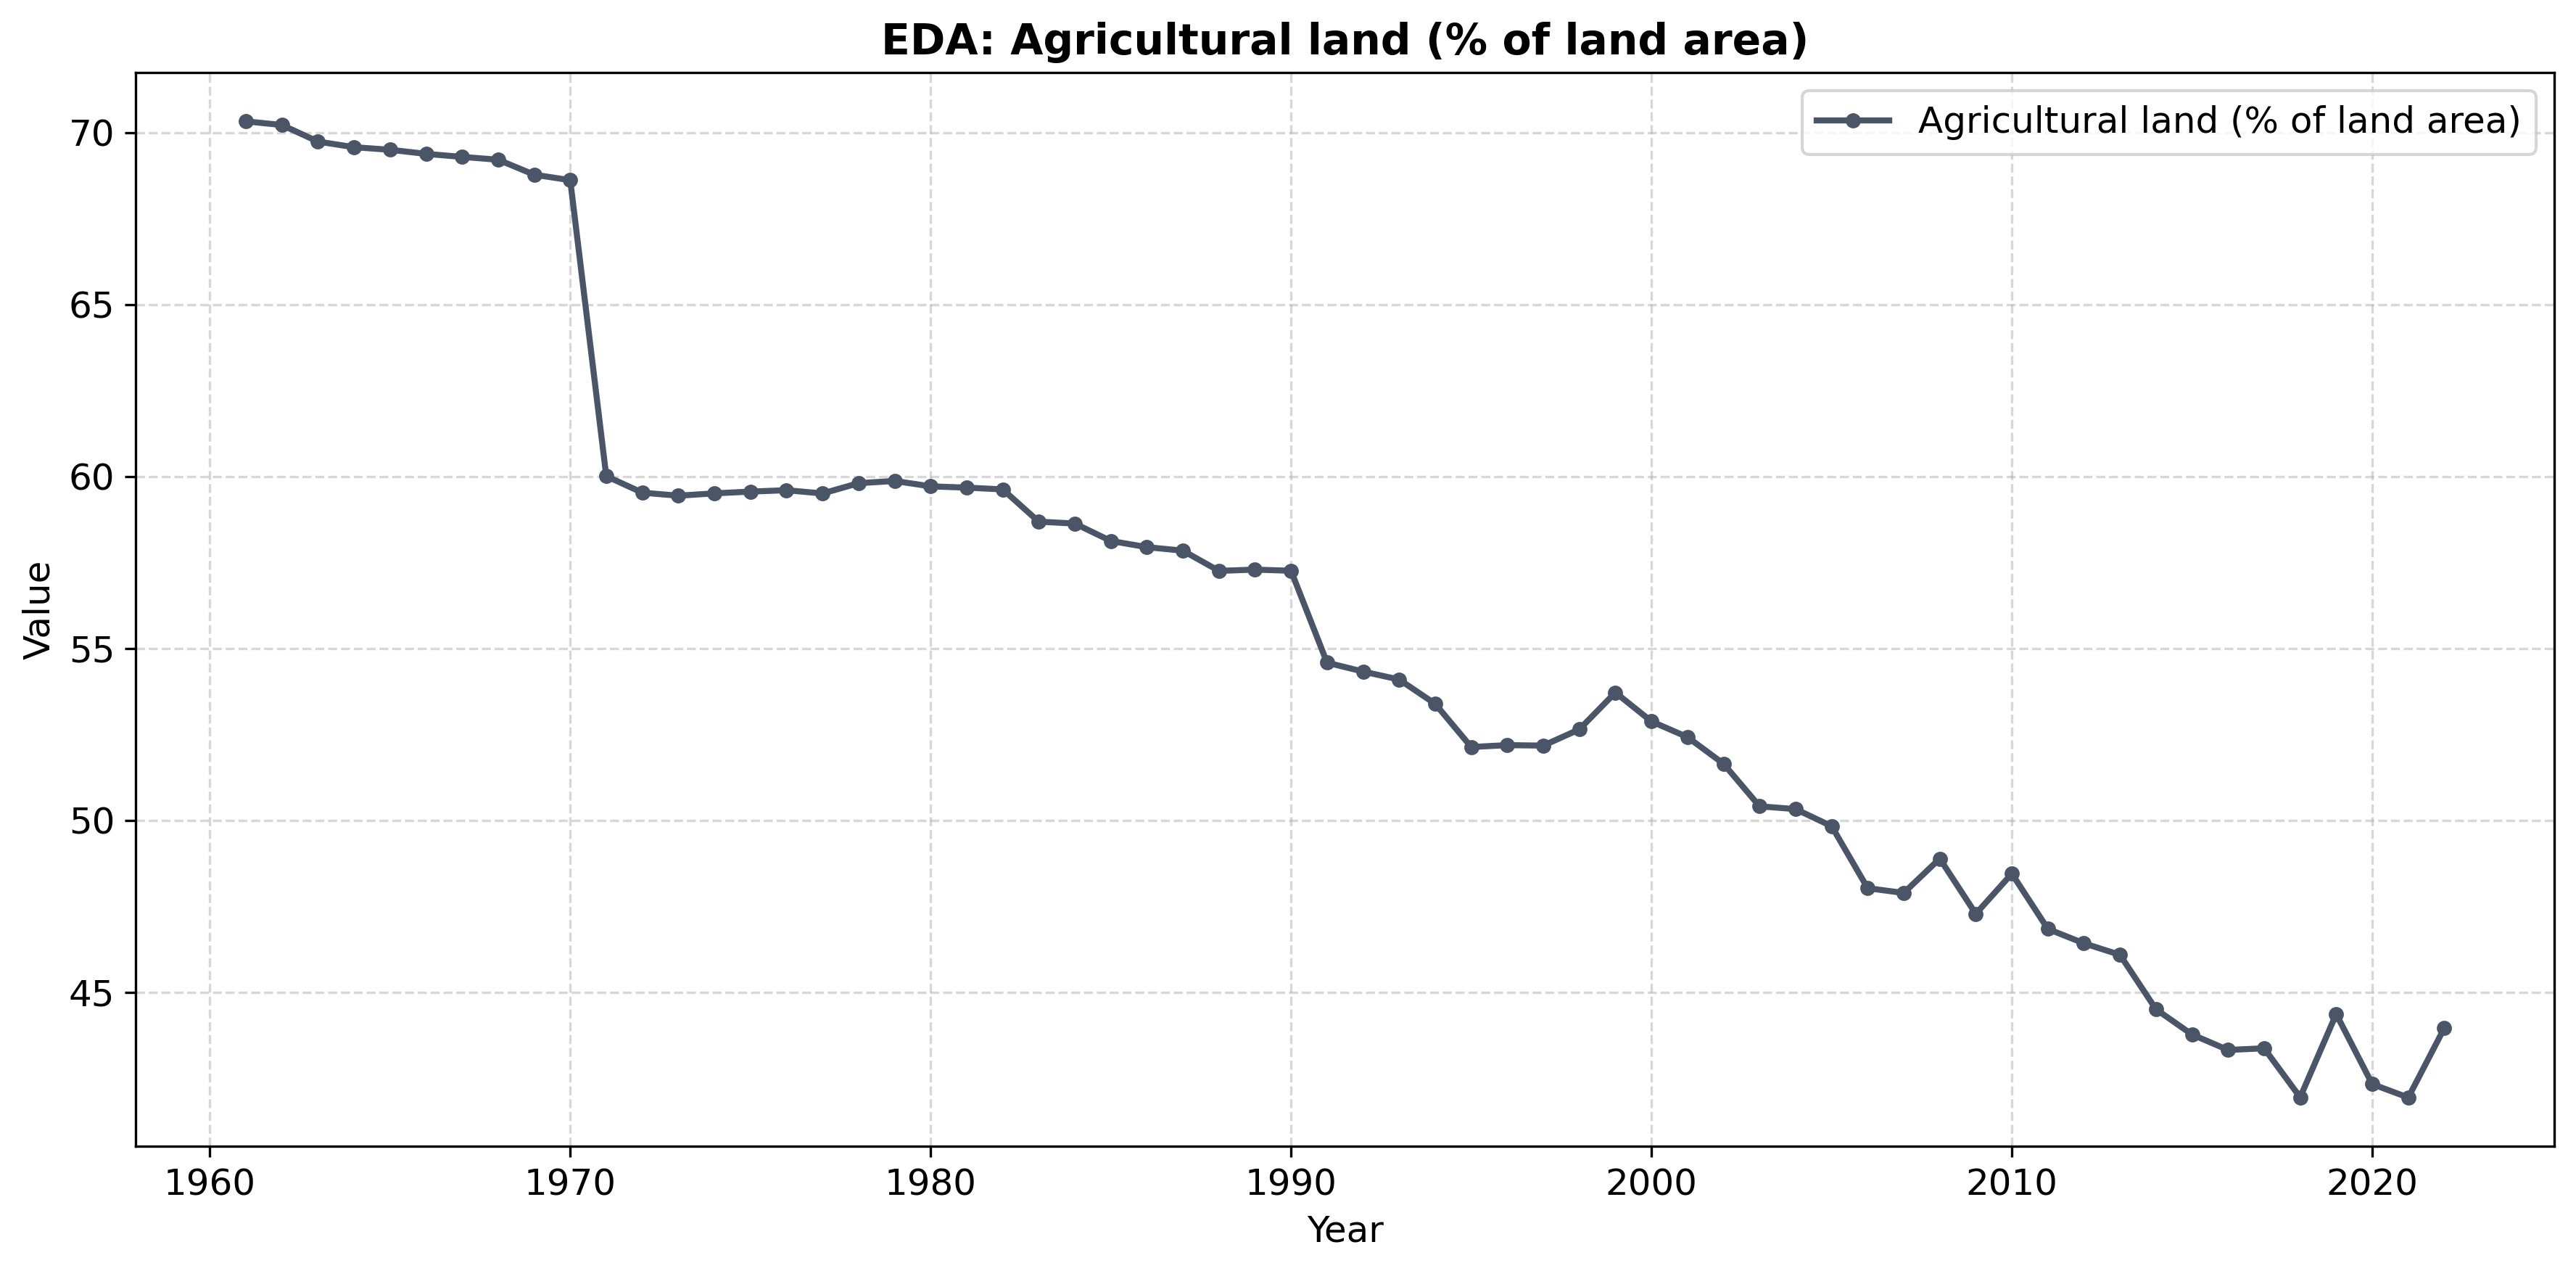

Saved: eda_agriland_abs.png


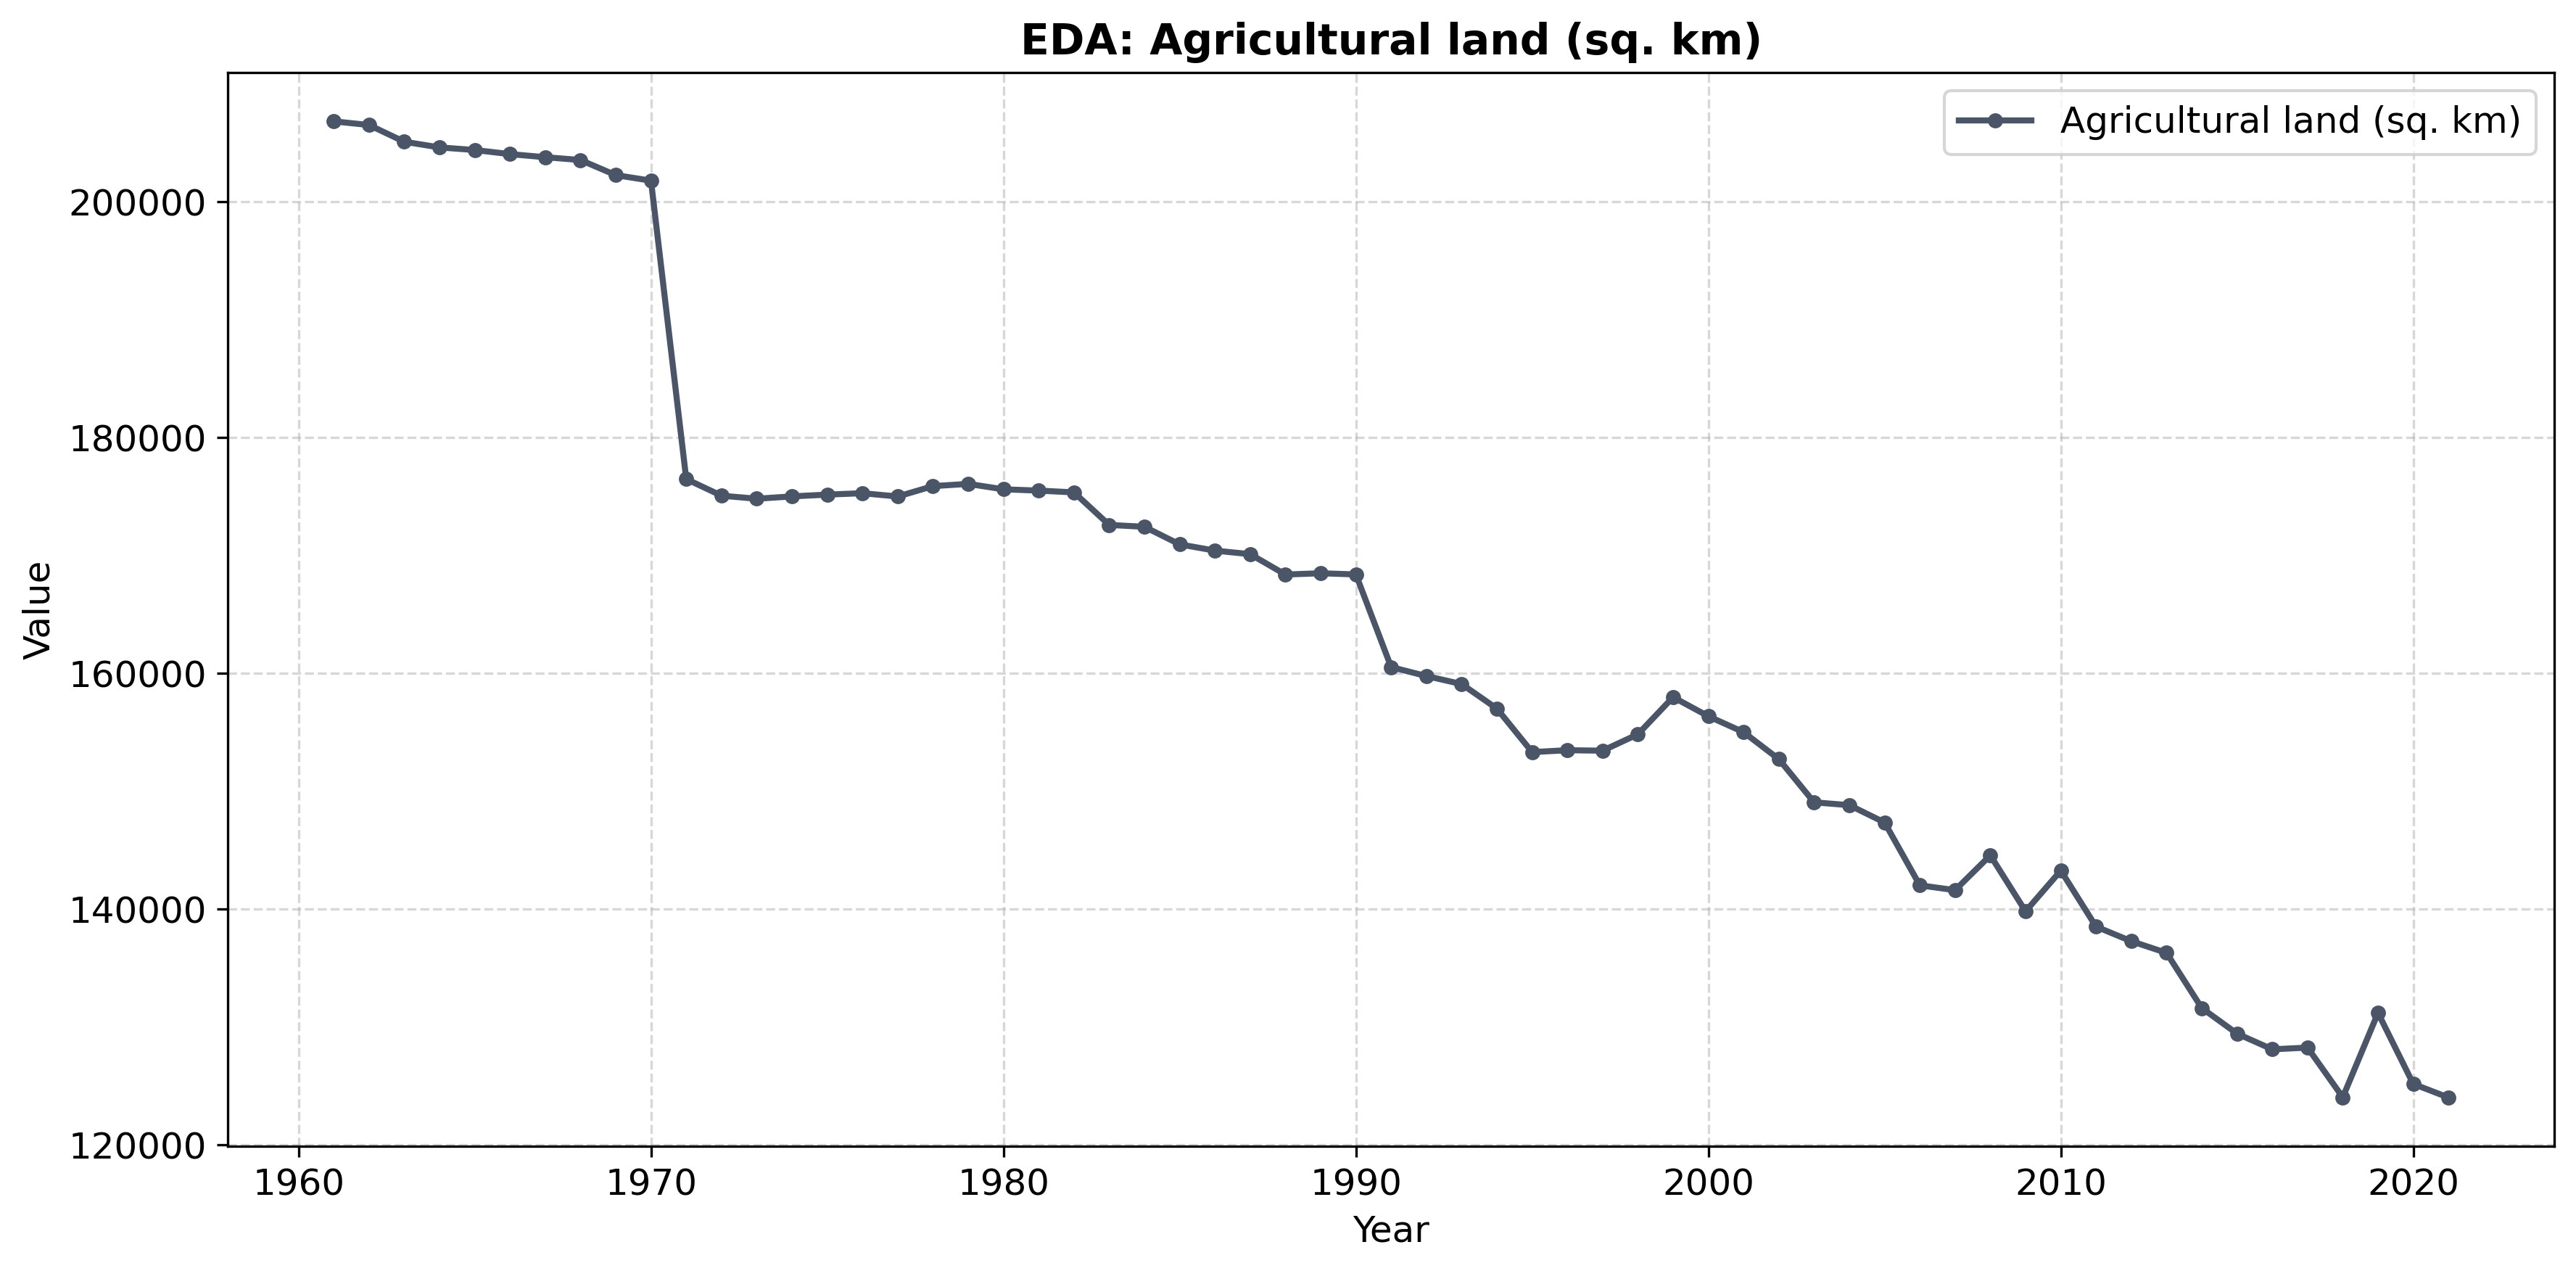

Saved: eda_exports_percent.png


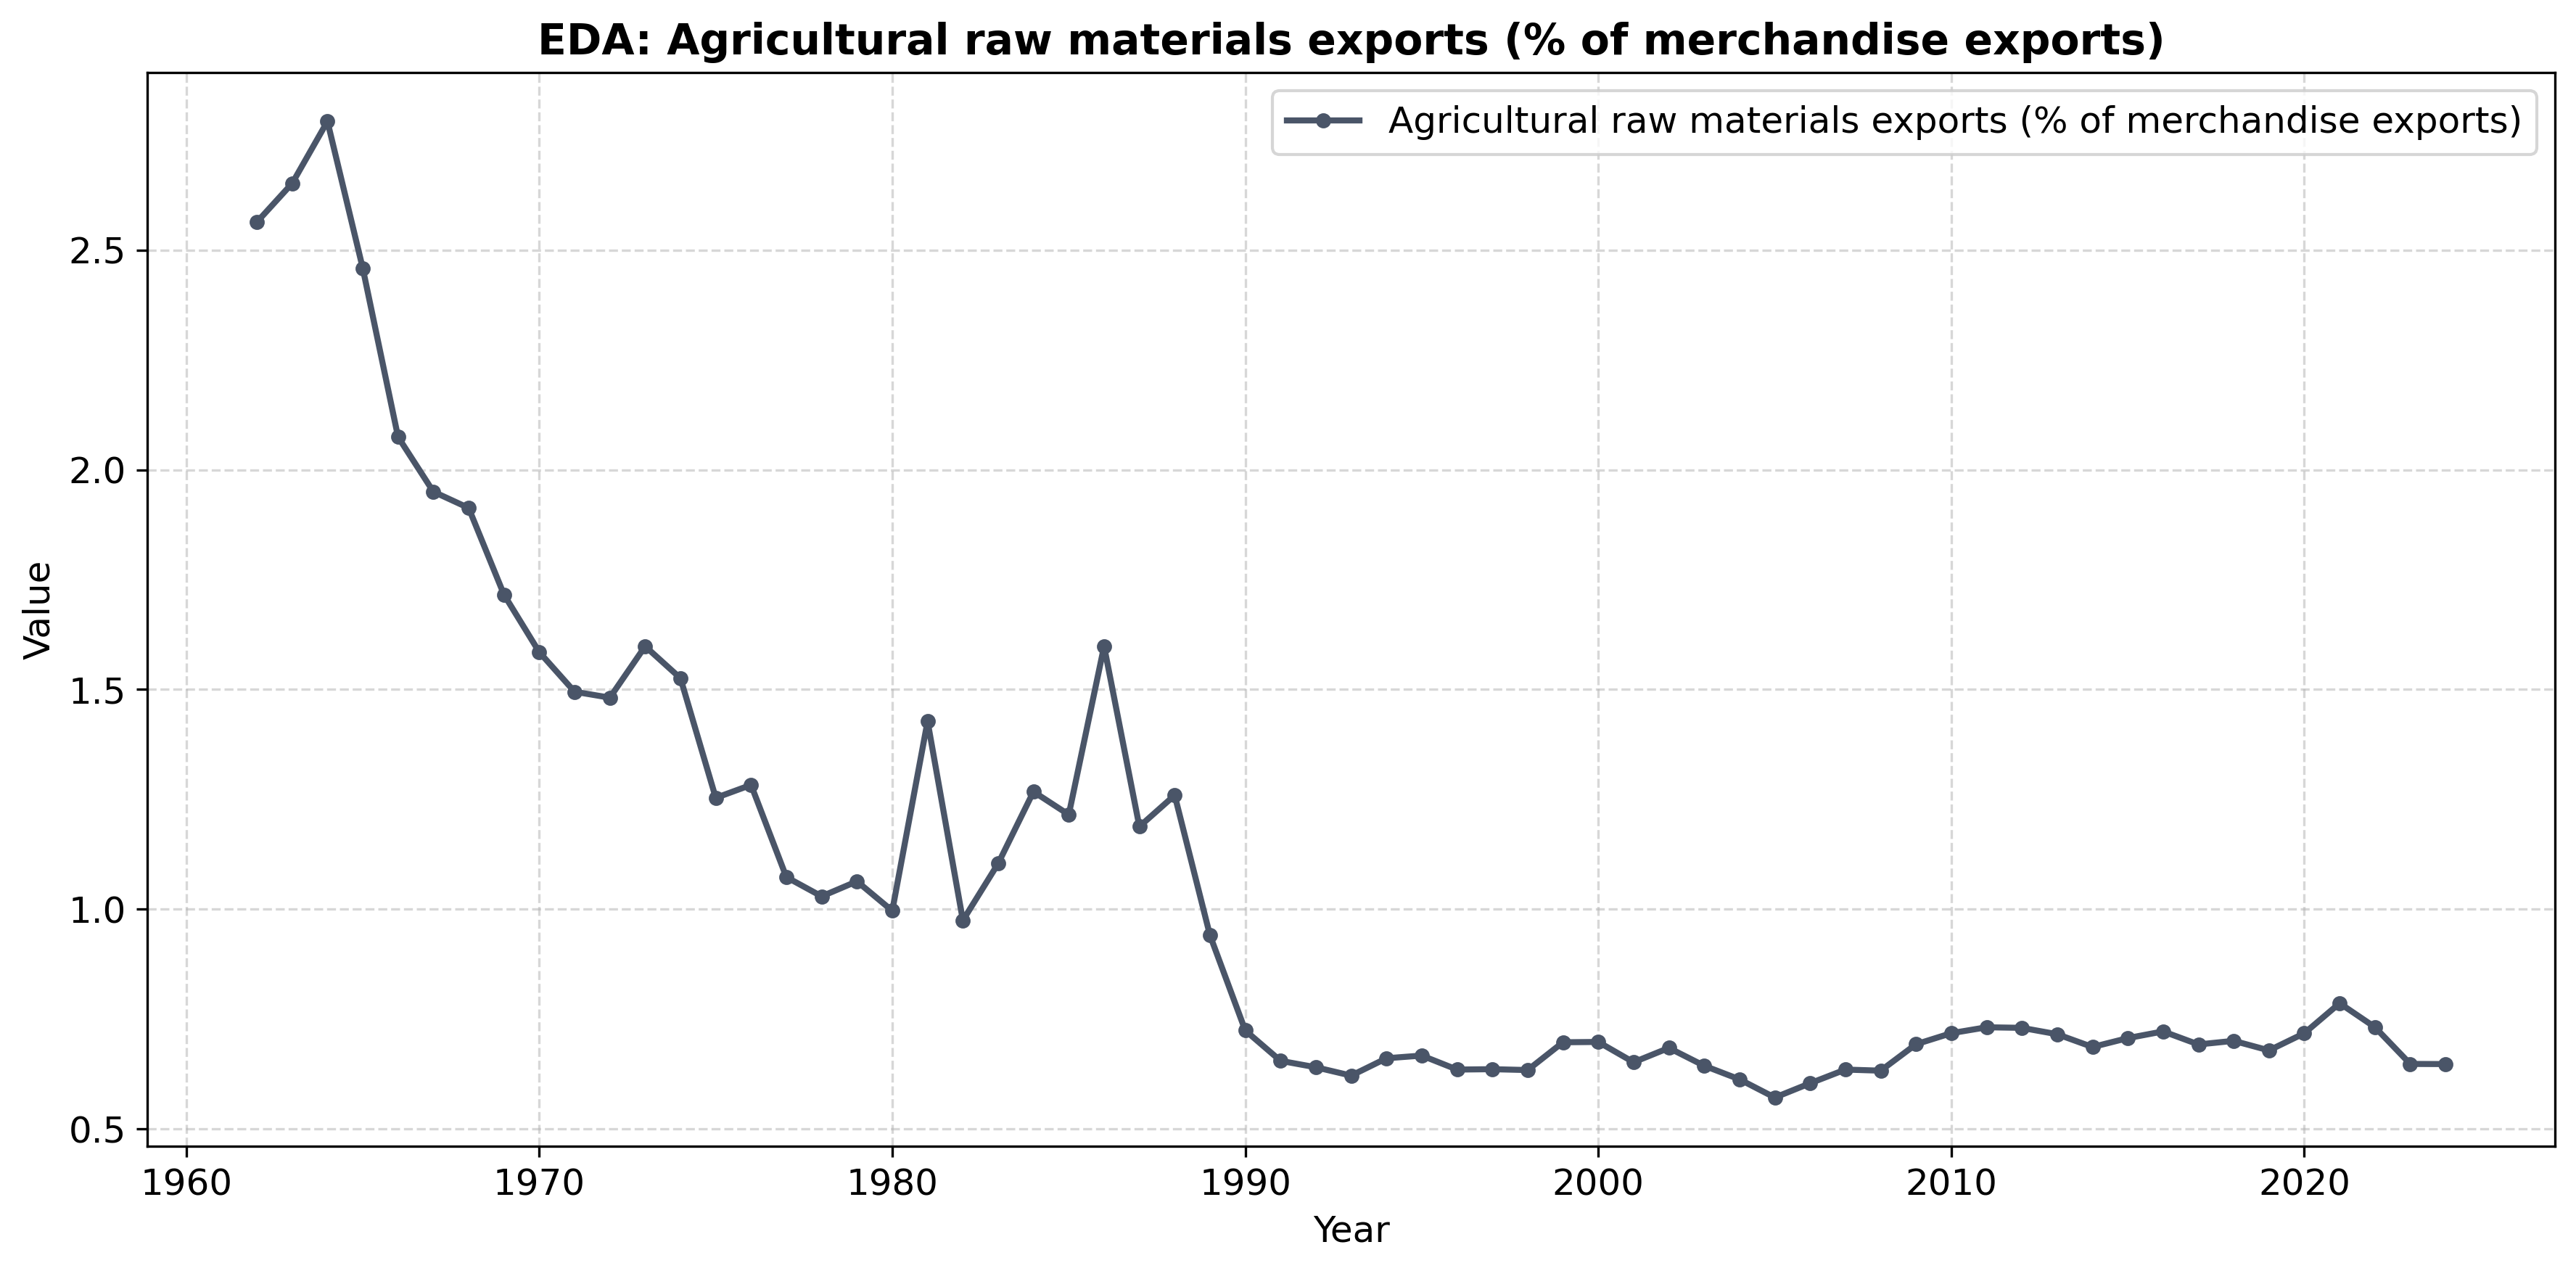

Saved: eda_imports_percent.png


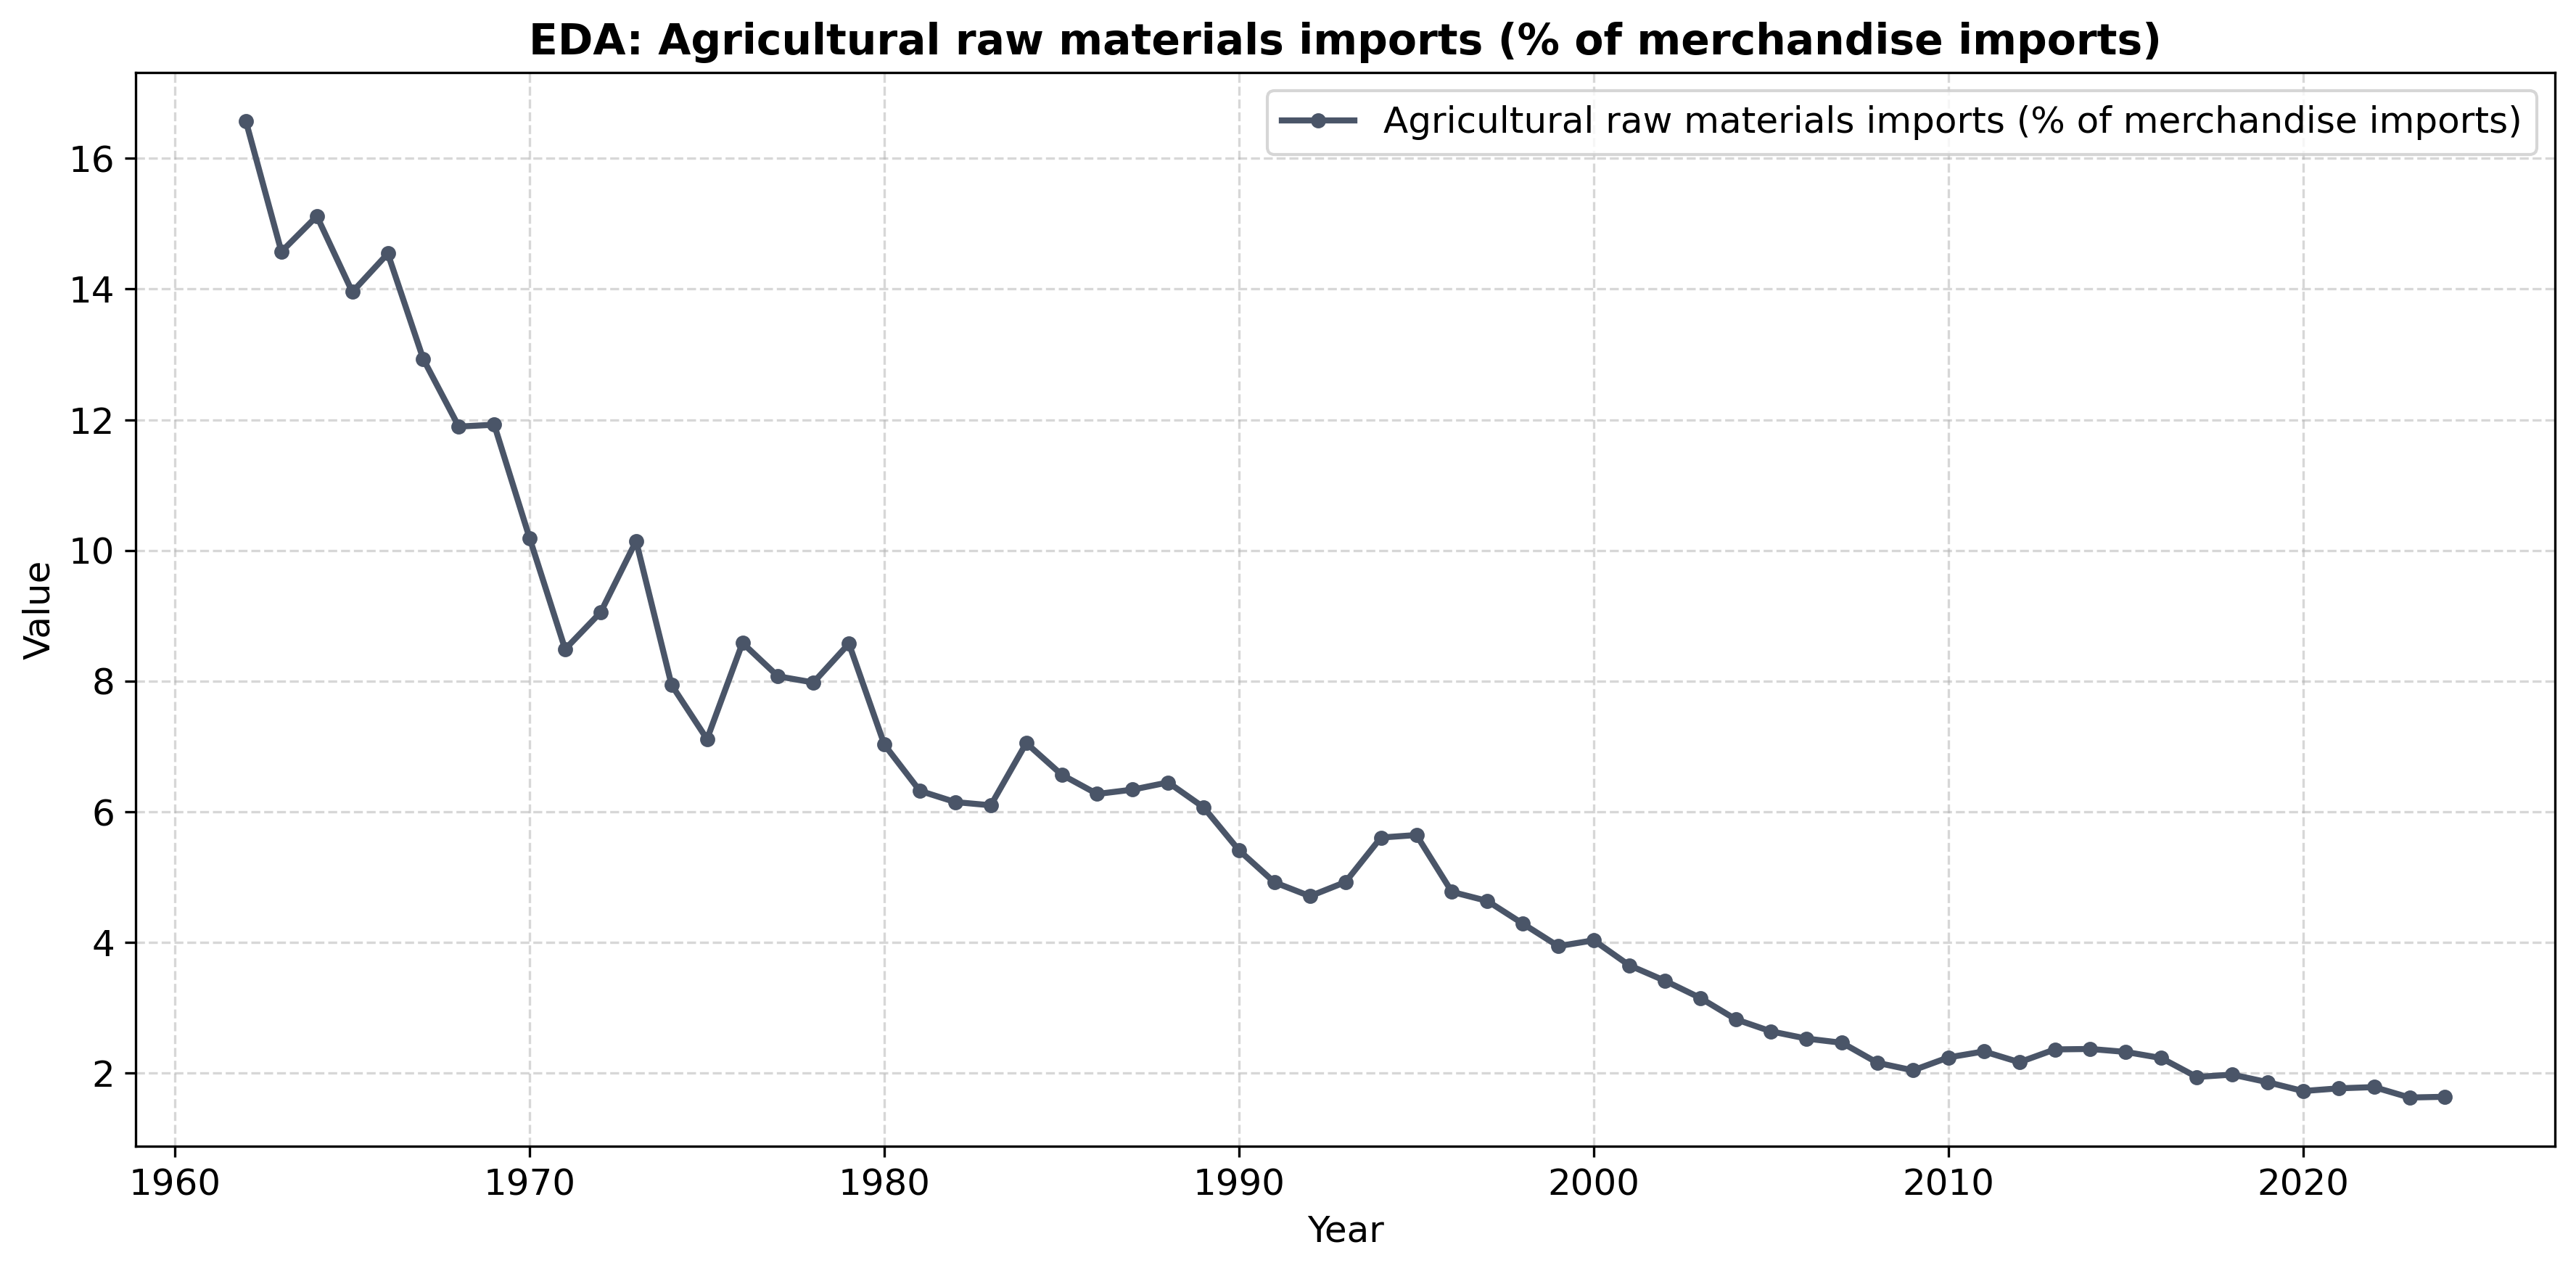

Saved: eda_valueadded_percent.png


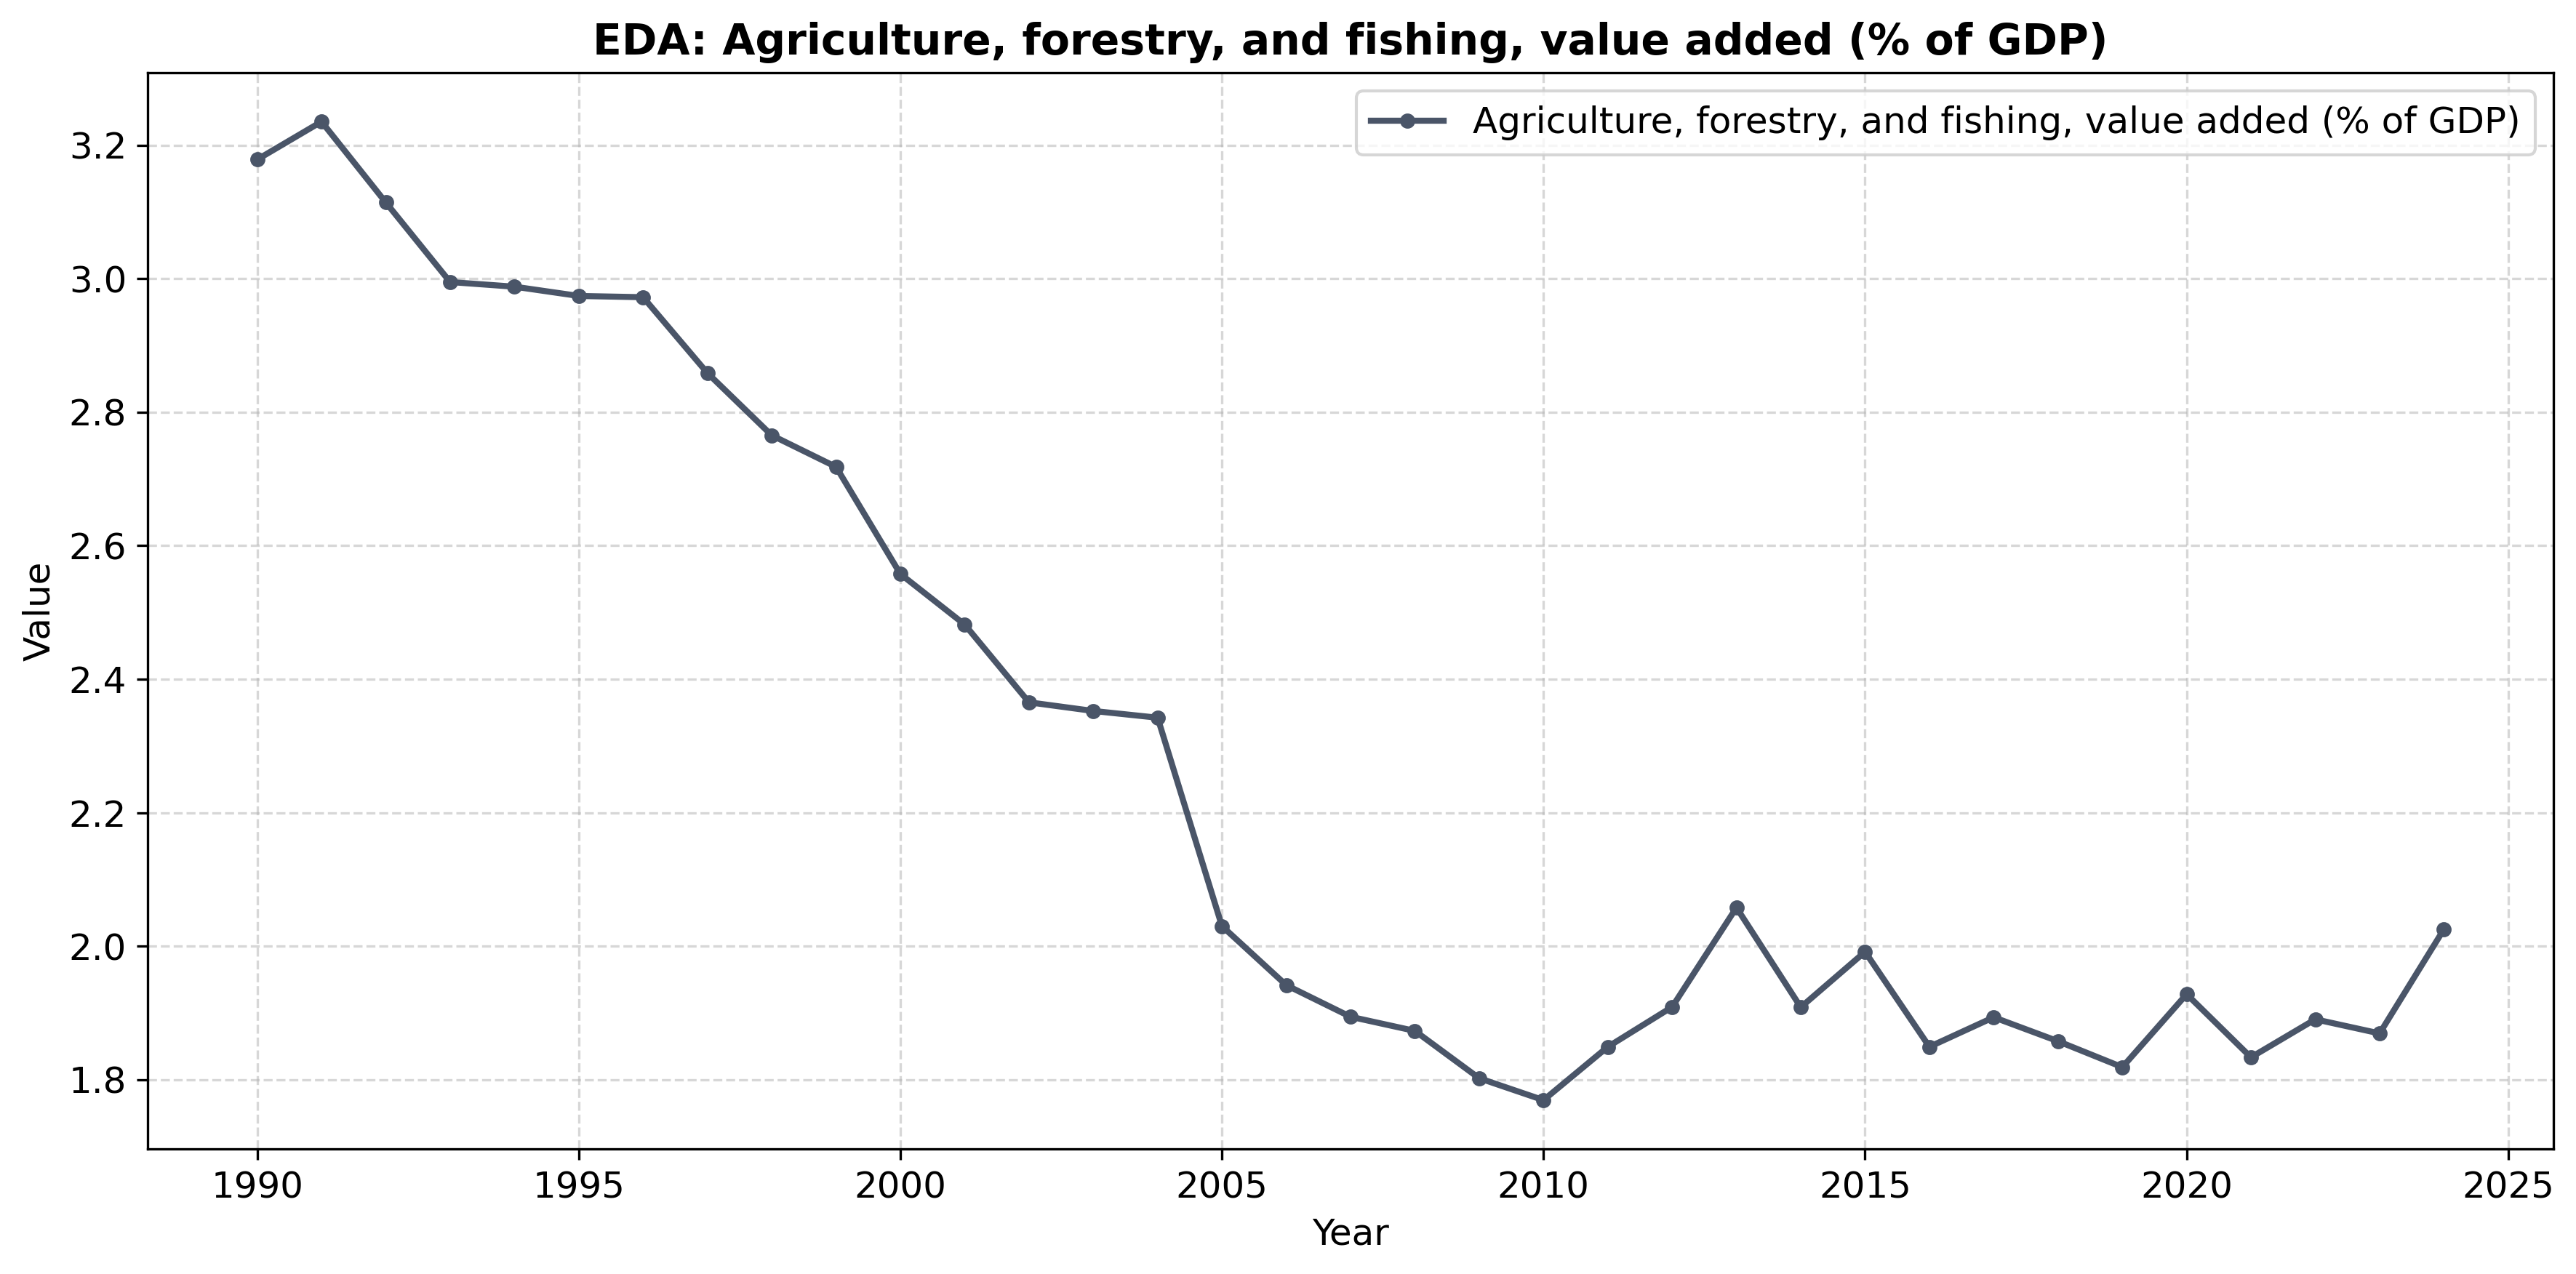

Saved: eda_valueadded_dollars.png


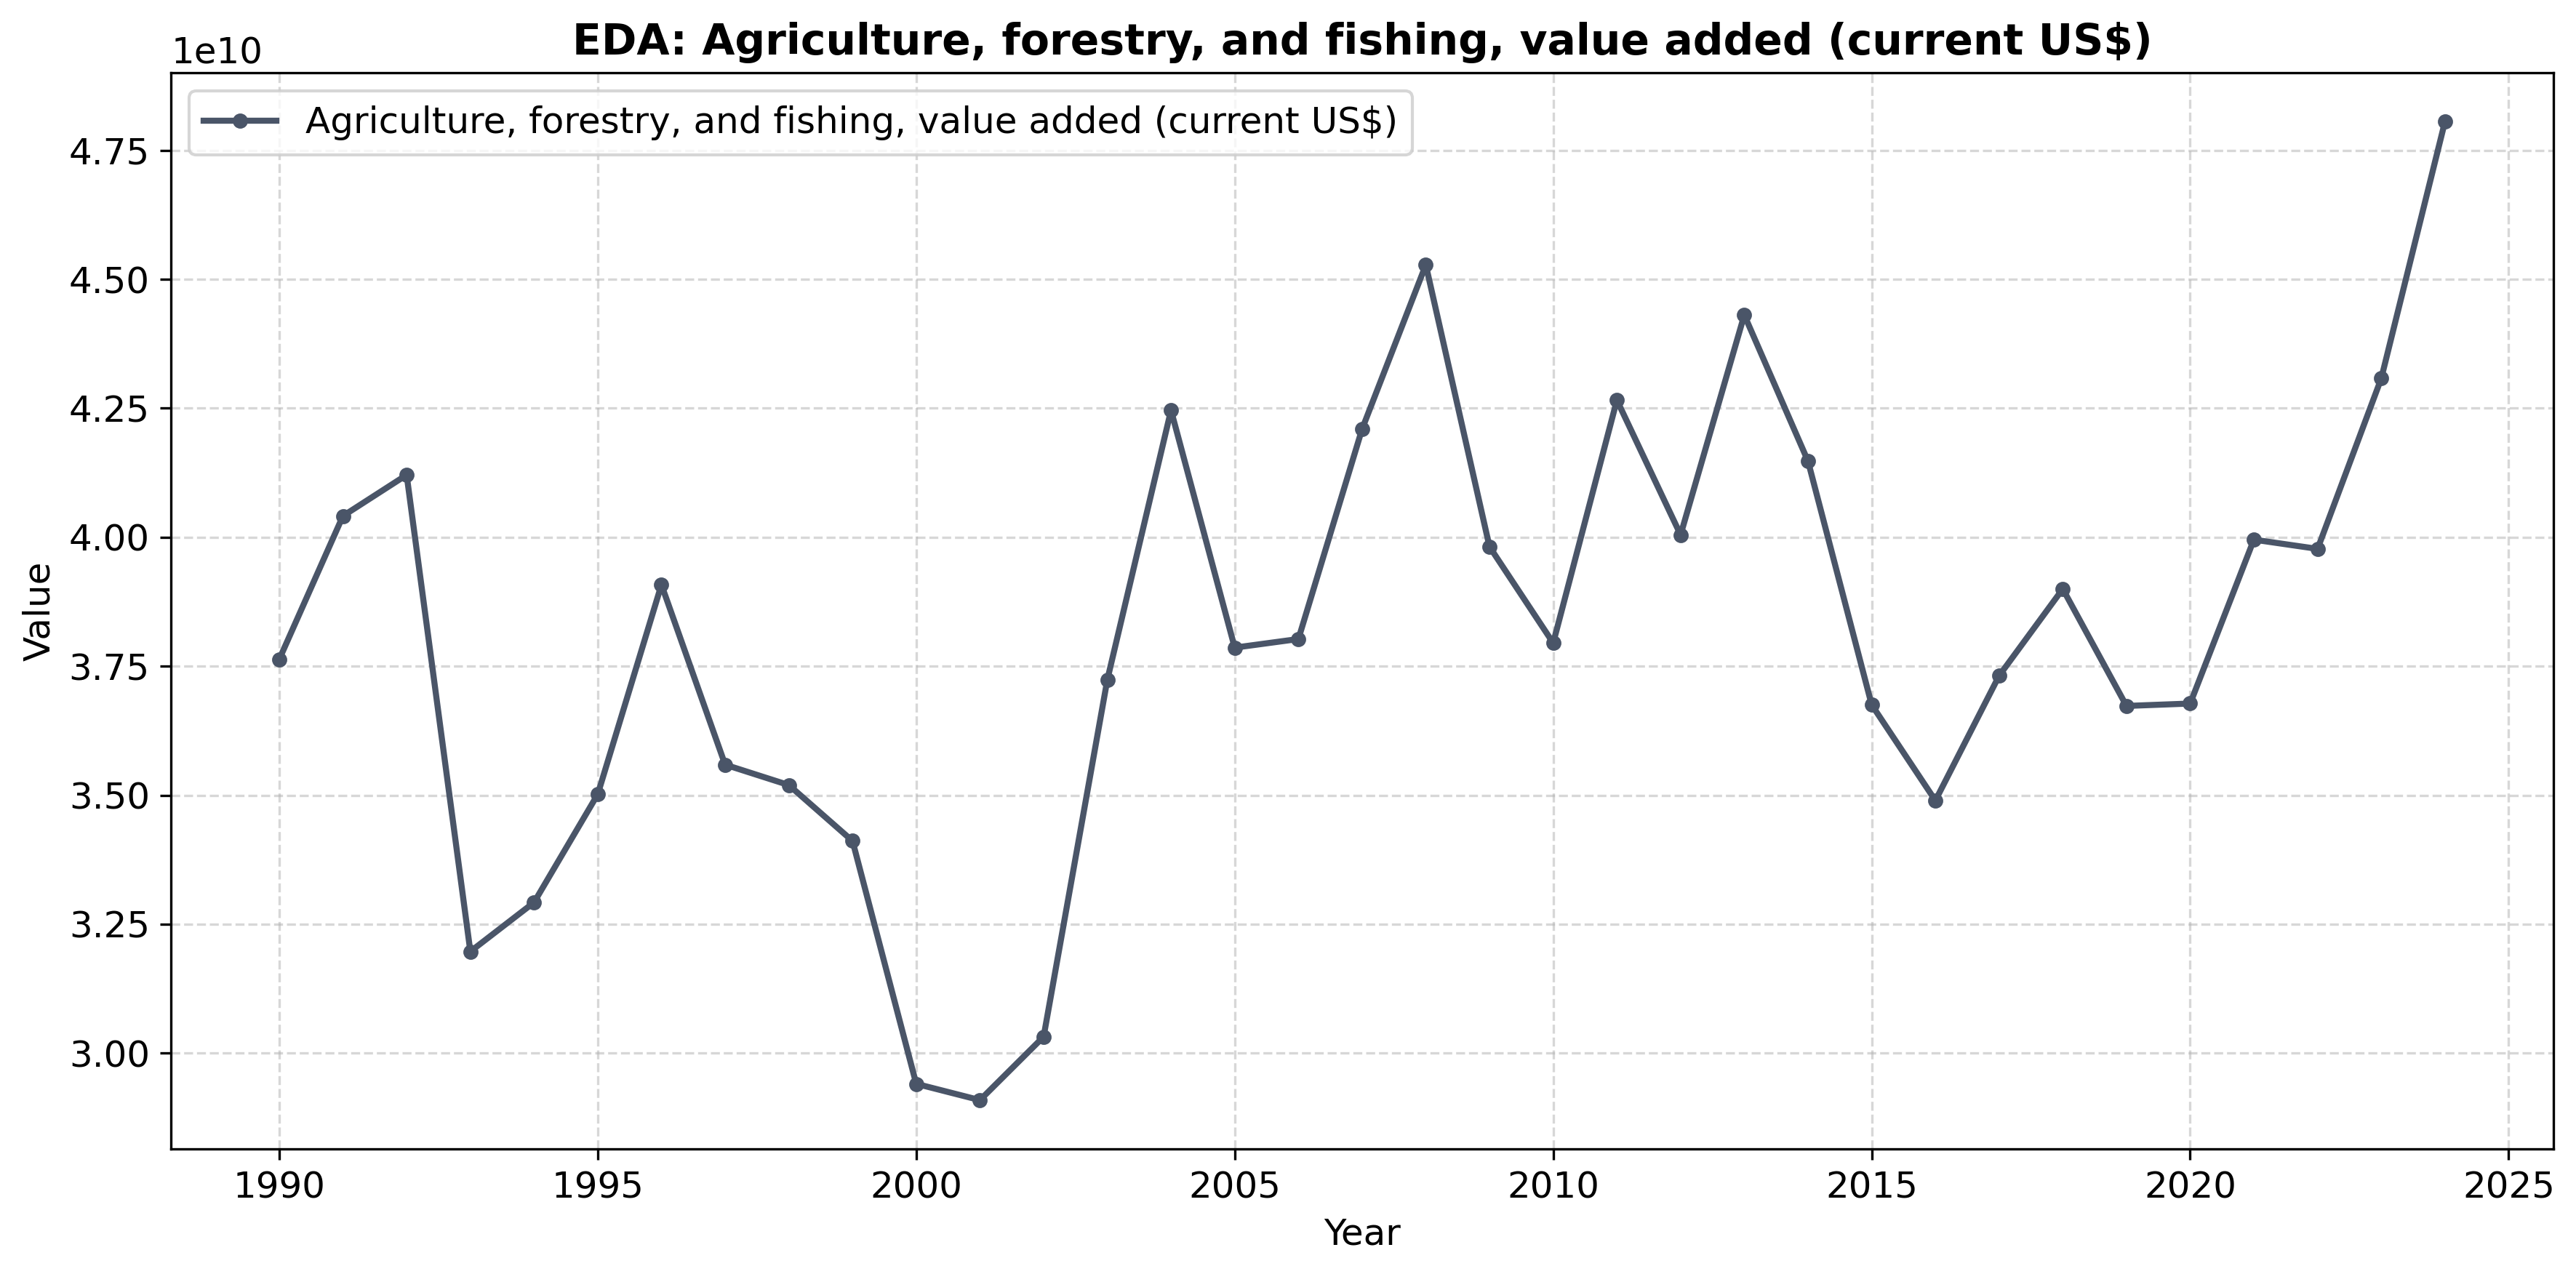

Saved: eda_withdrawals_percent.png


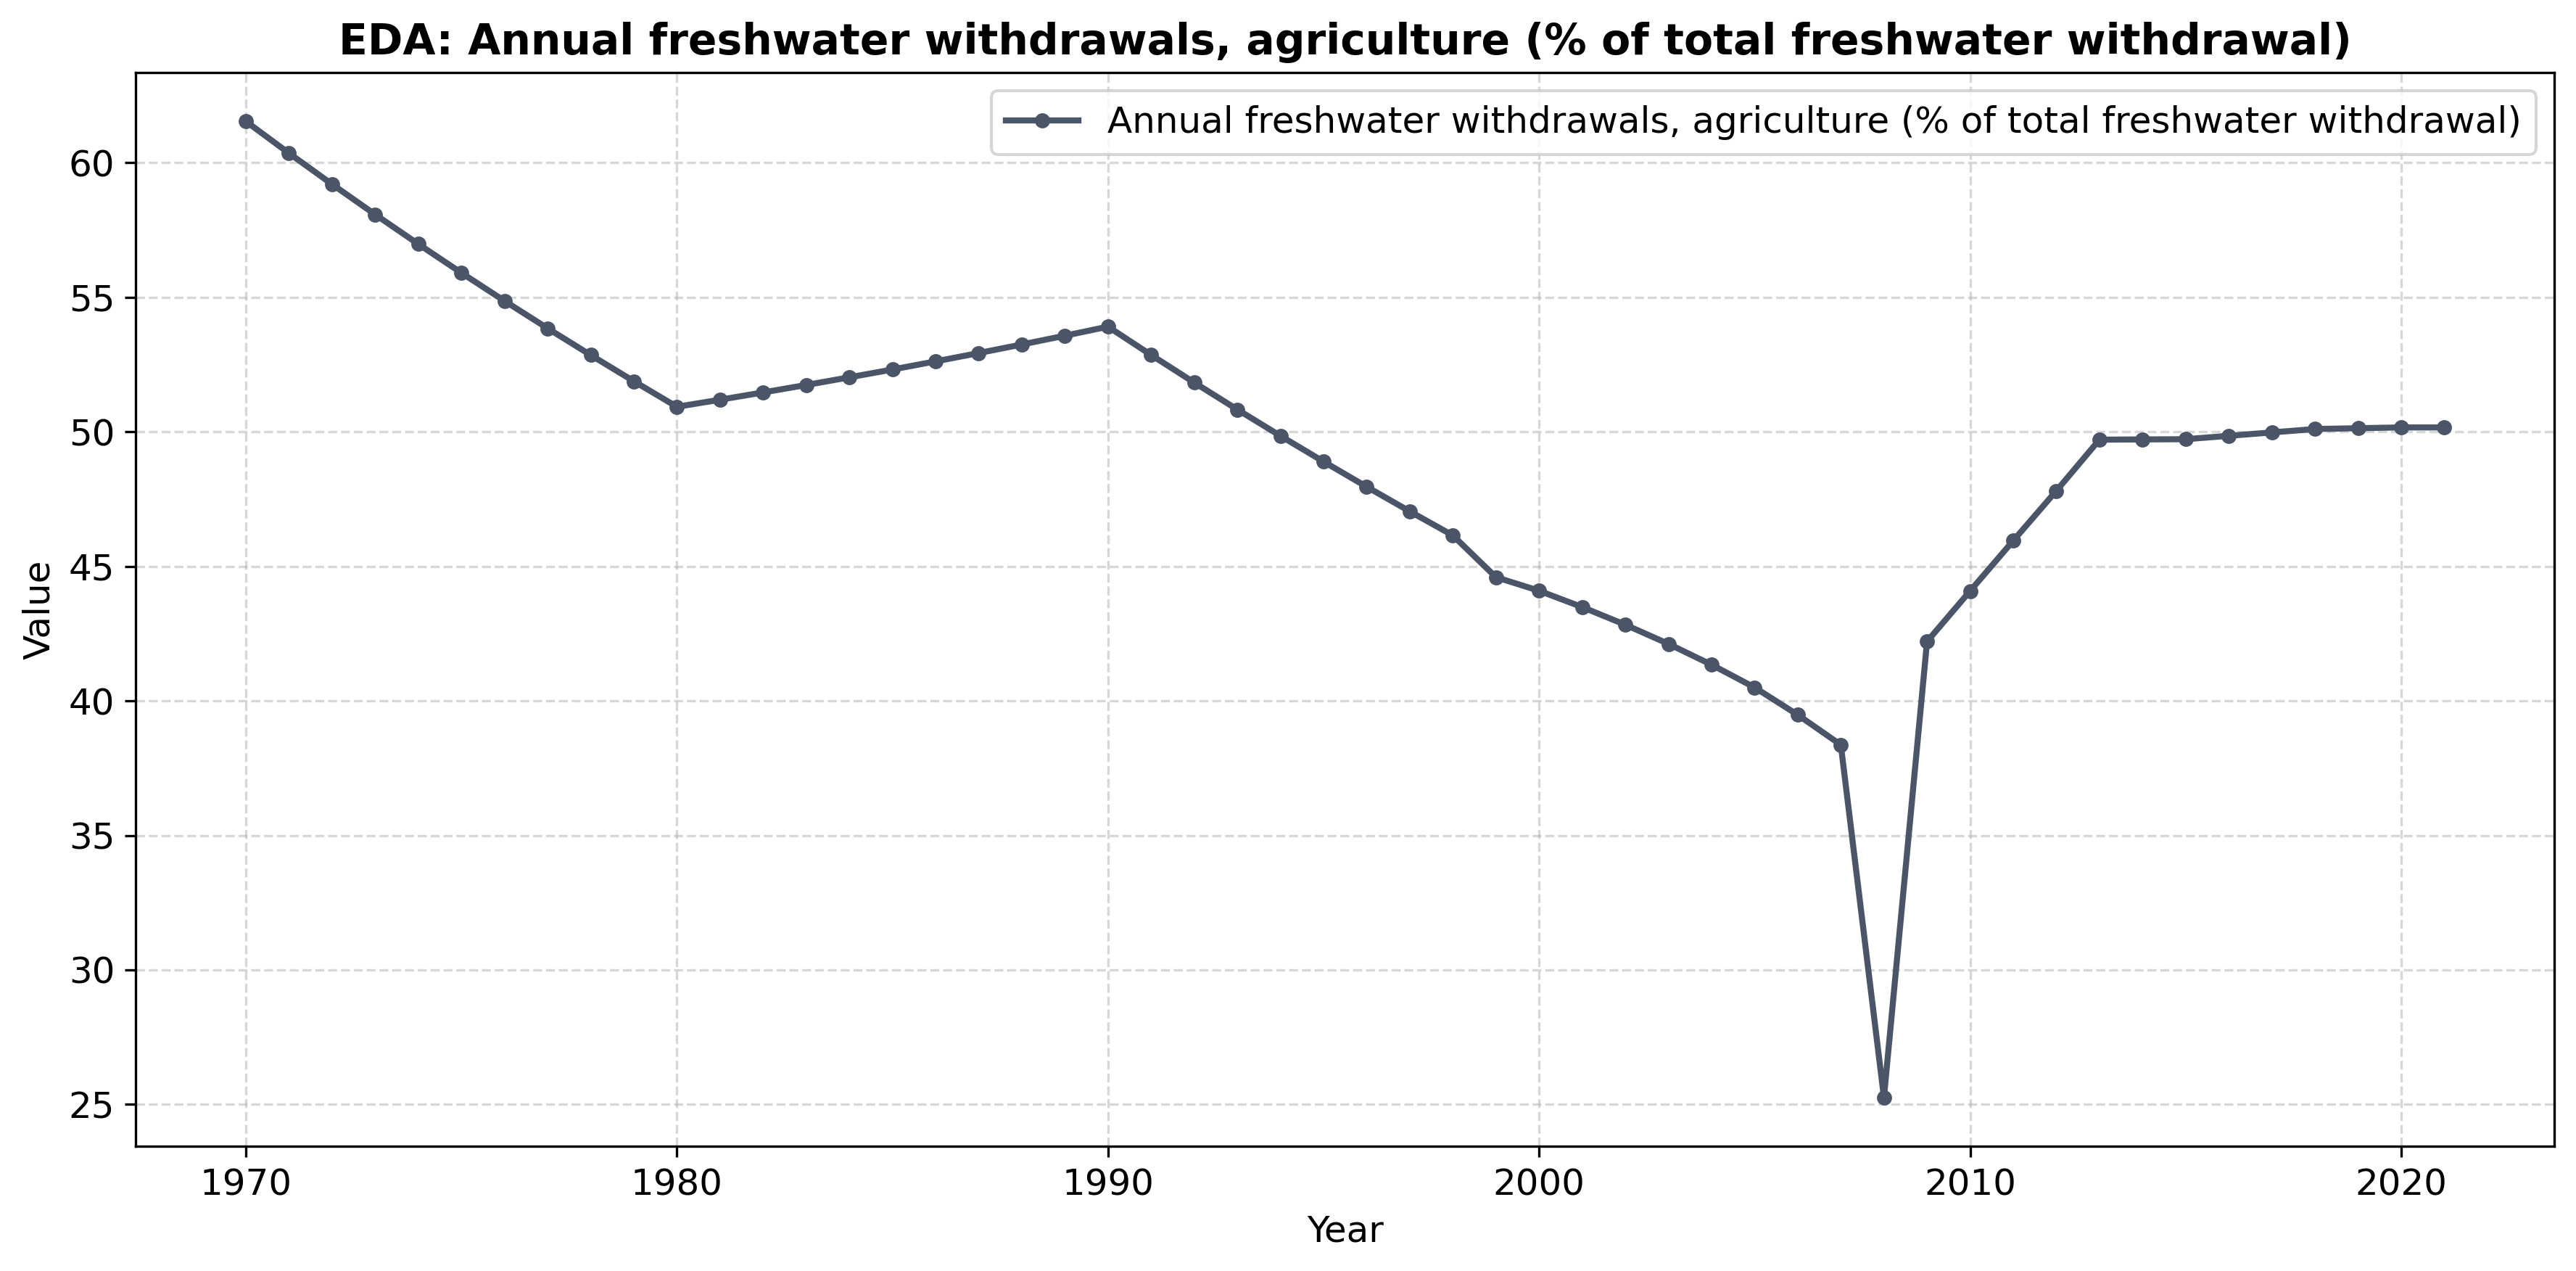

Saved: eda_arableland_percent.png


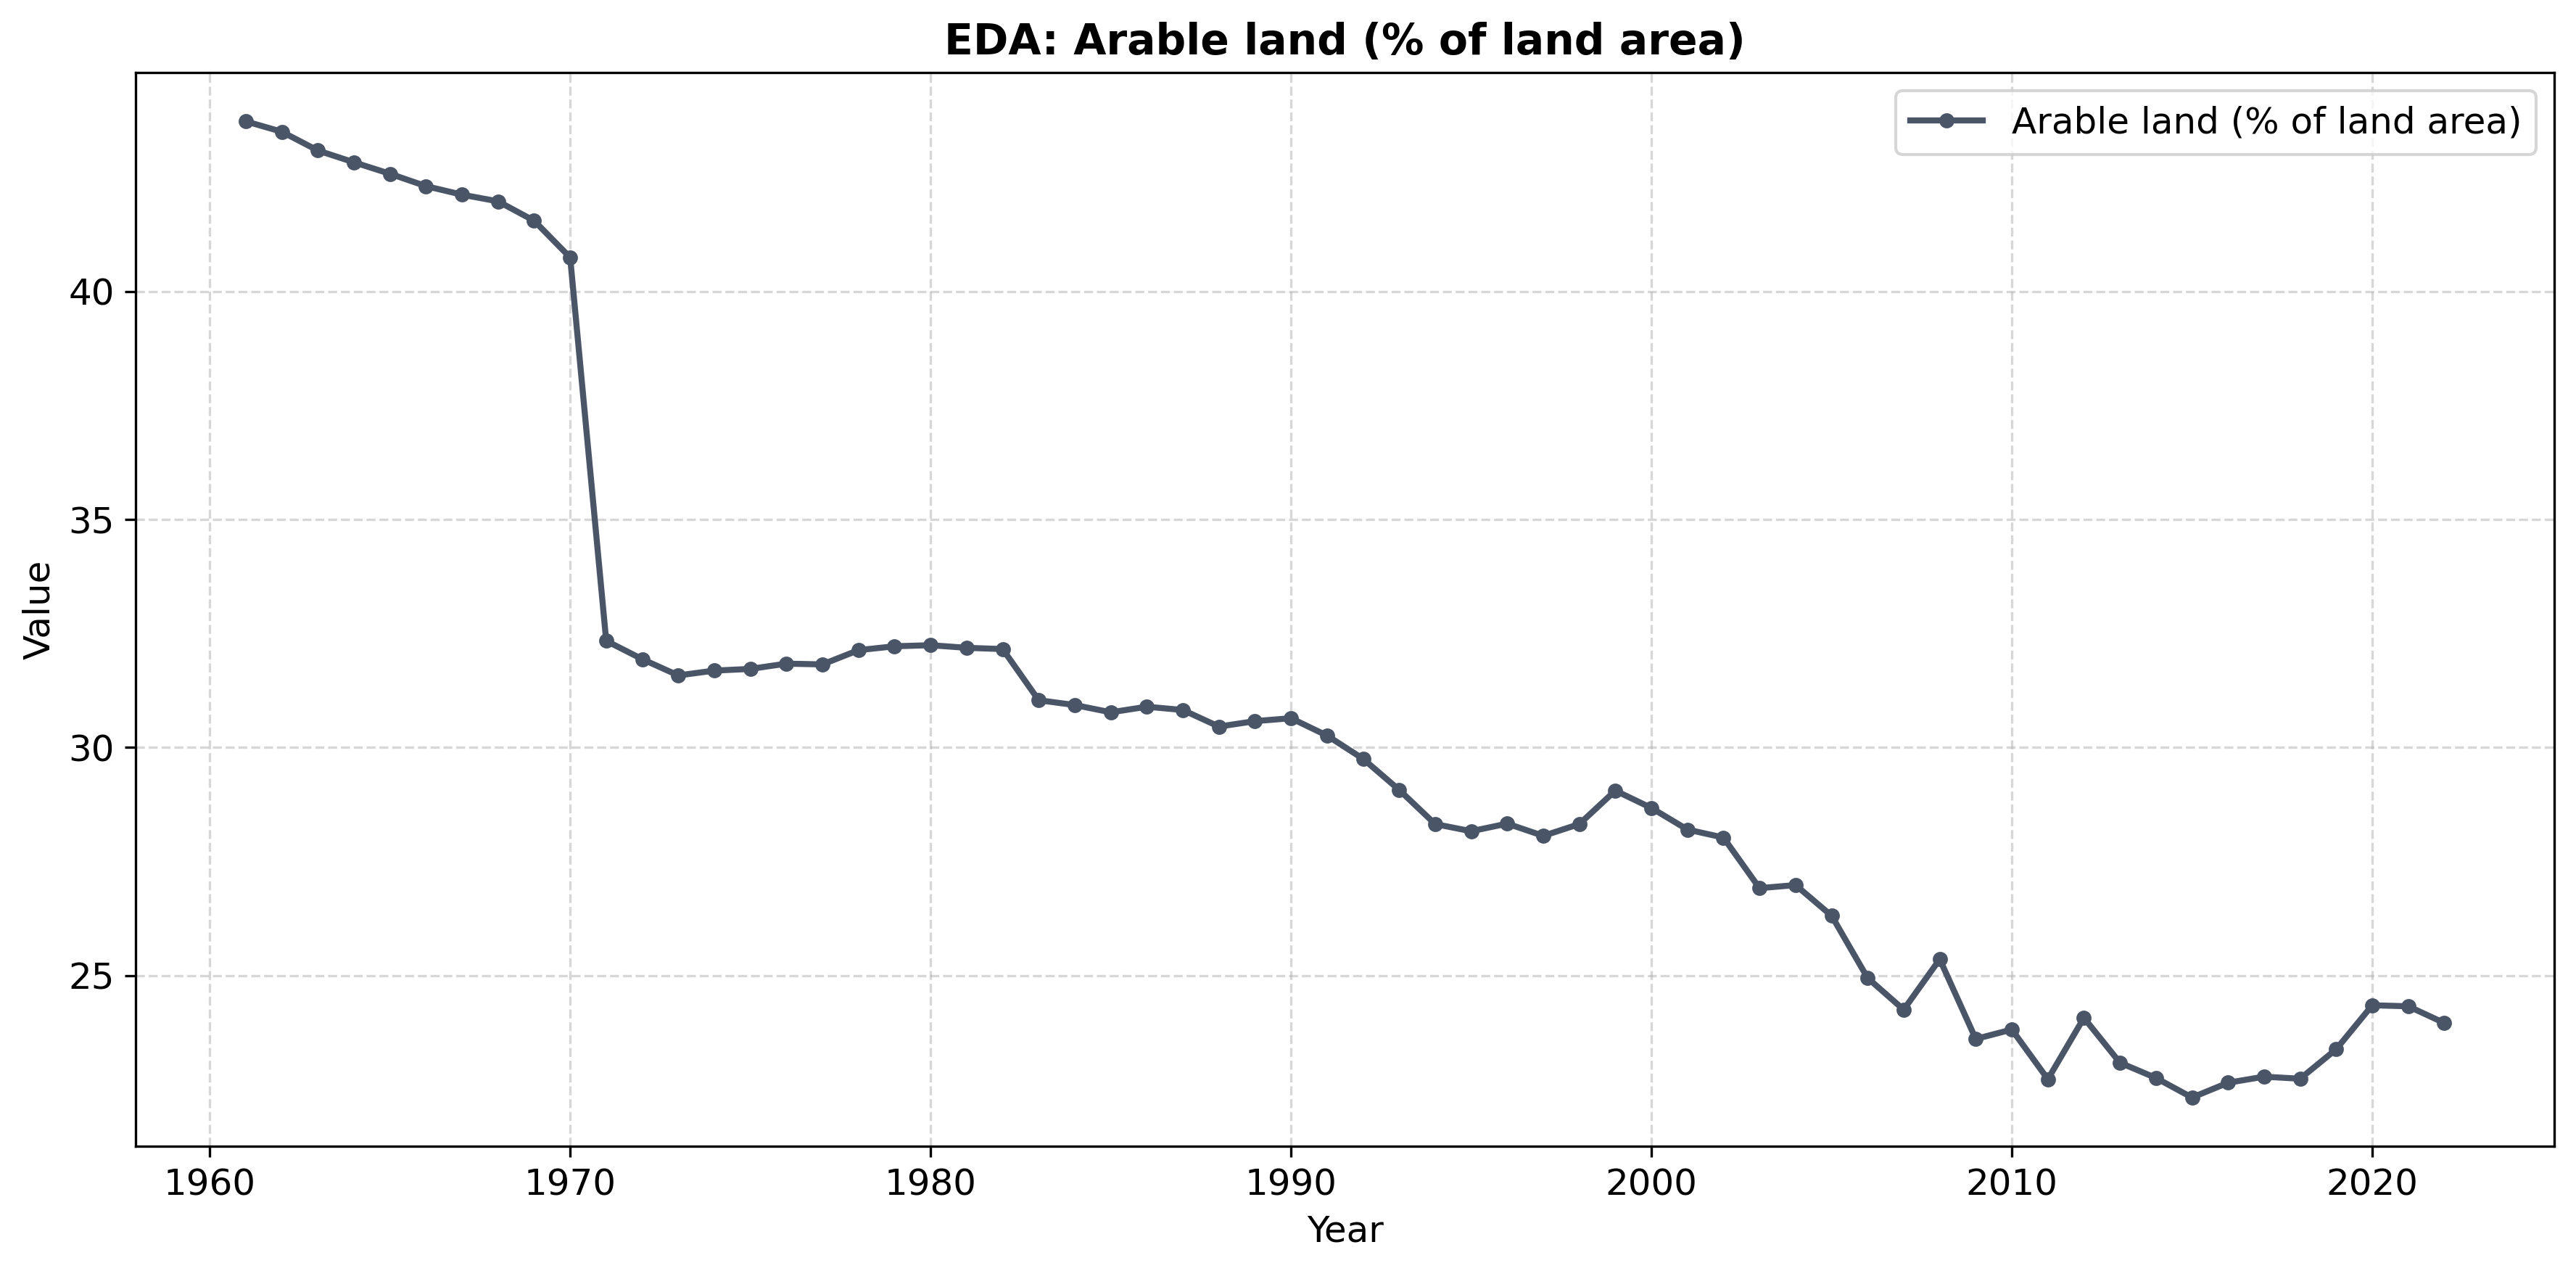

Saved: eda_arableland_person.png


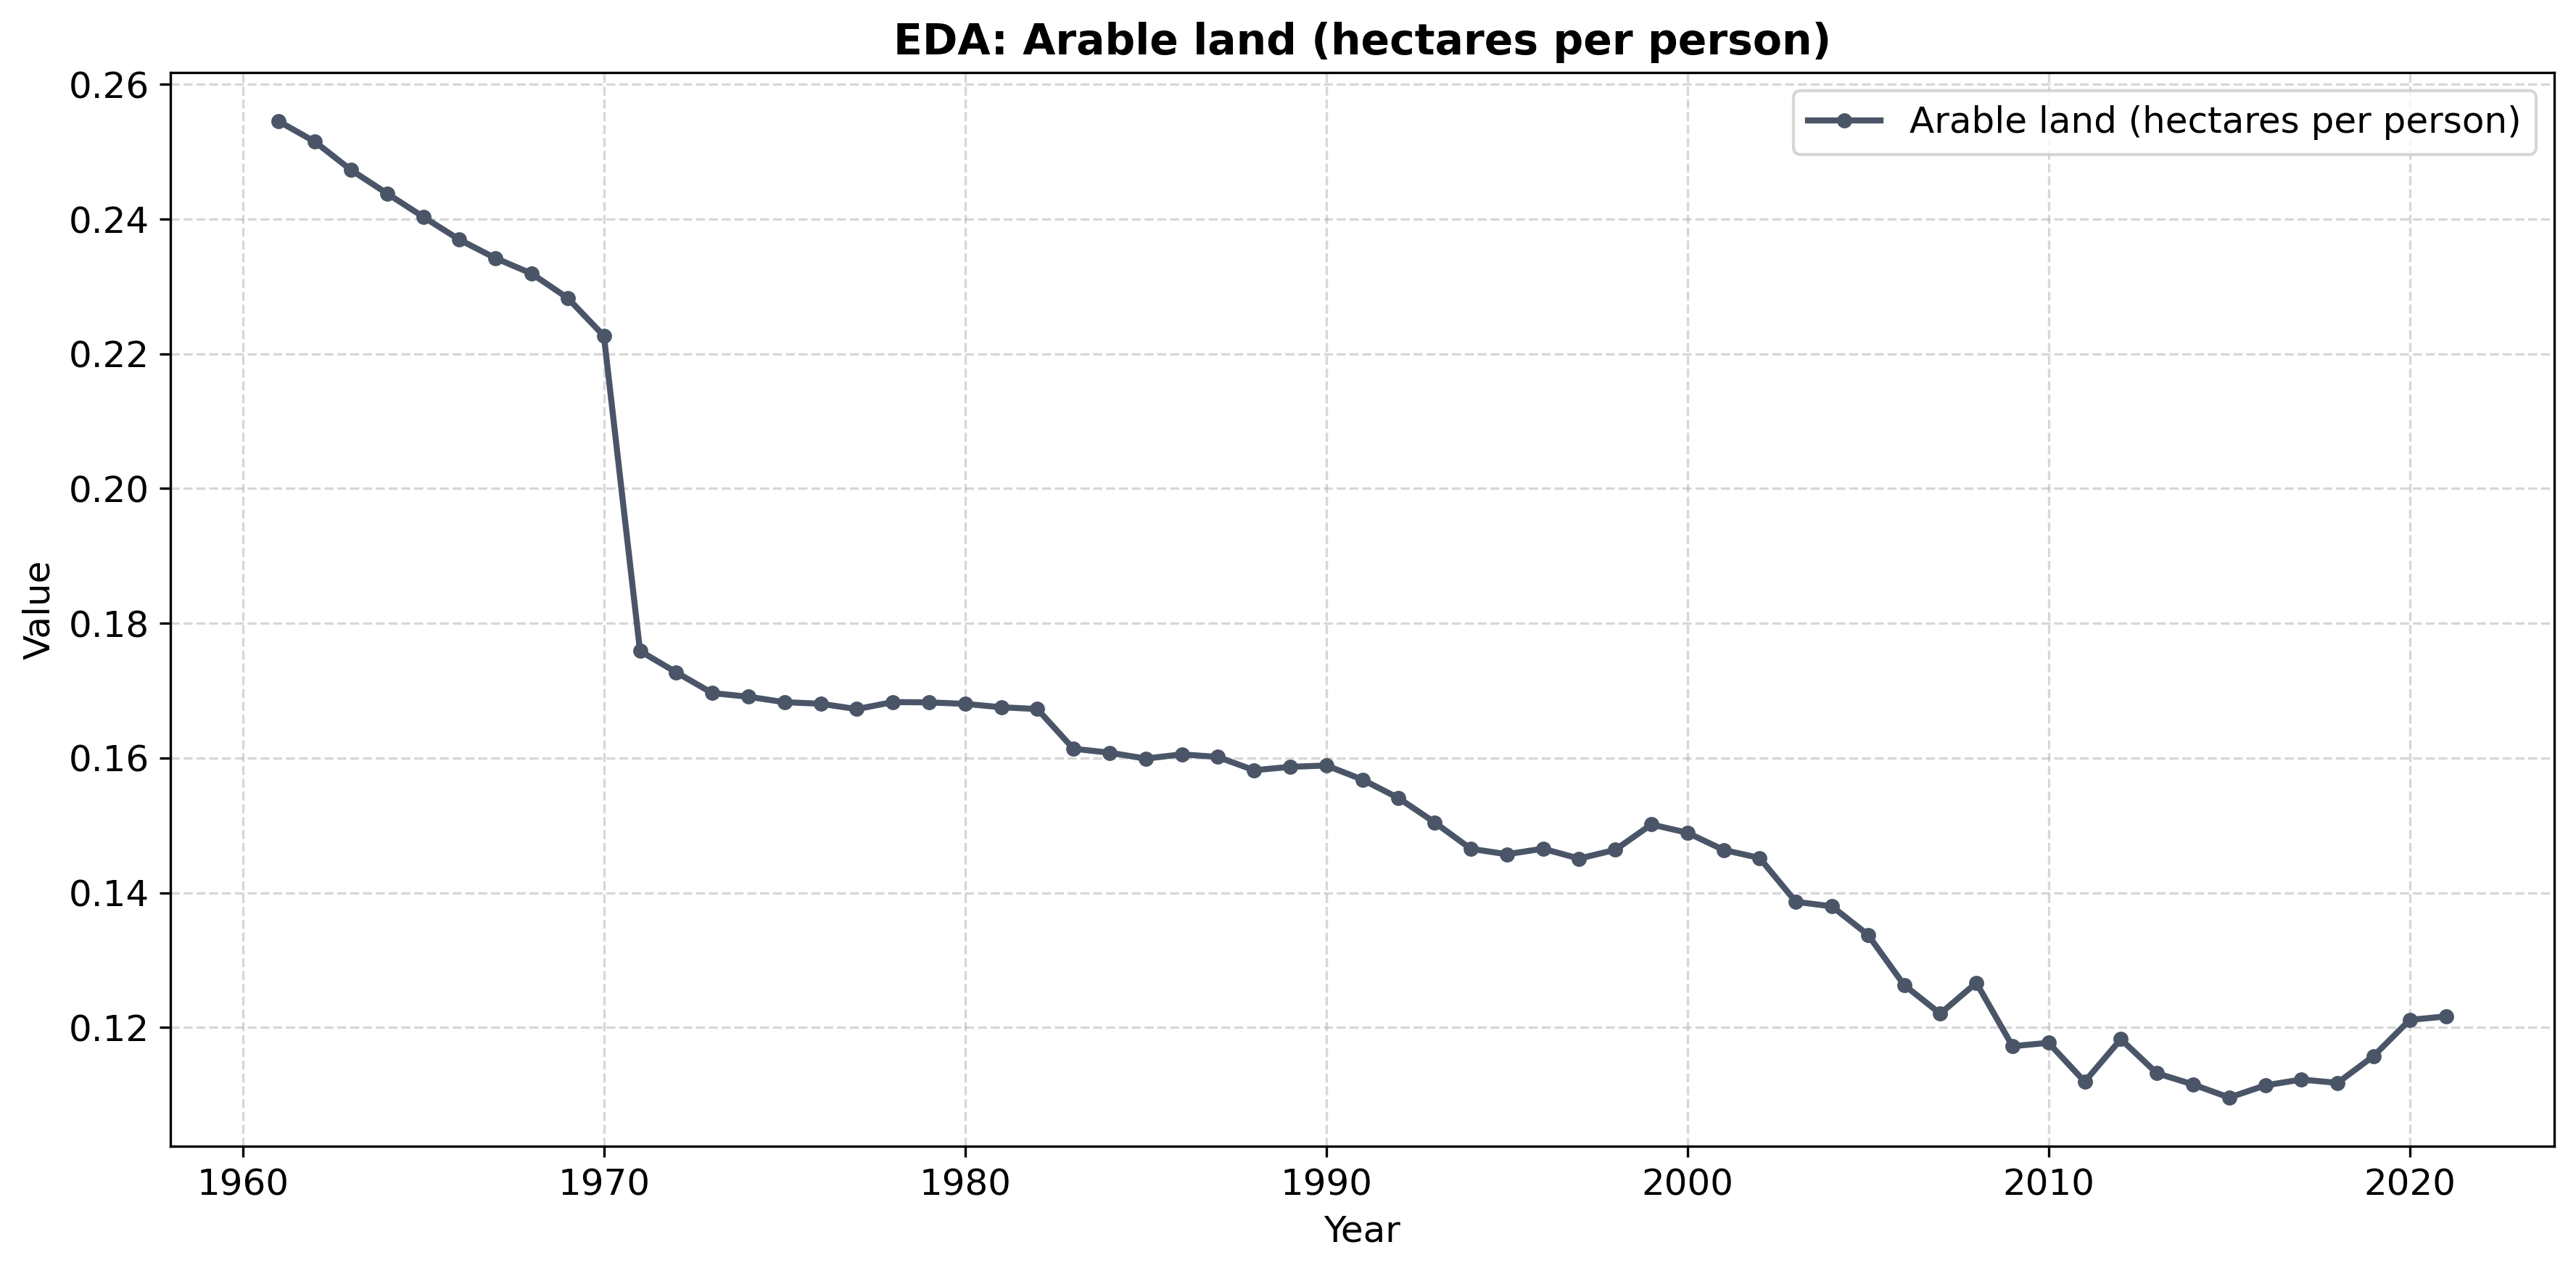

Saved: eda_arableland_abs.png


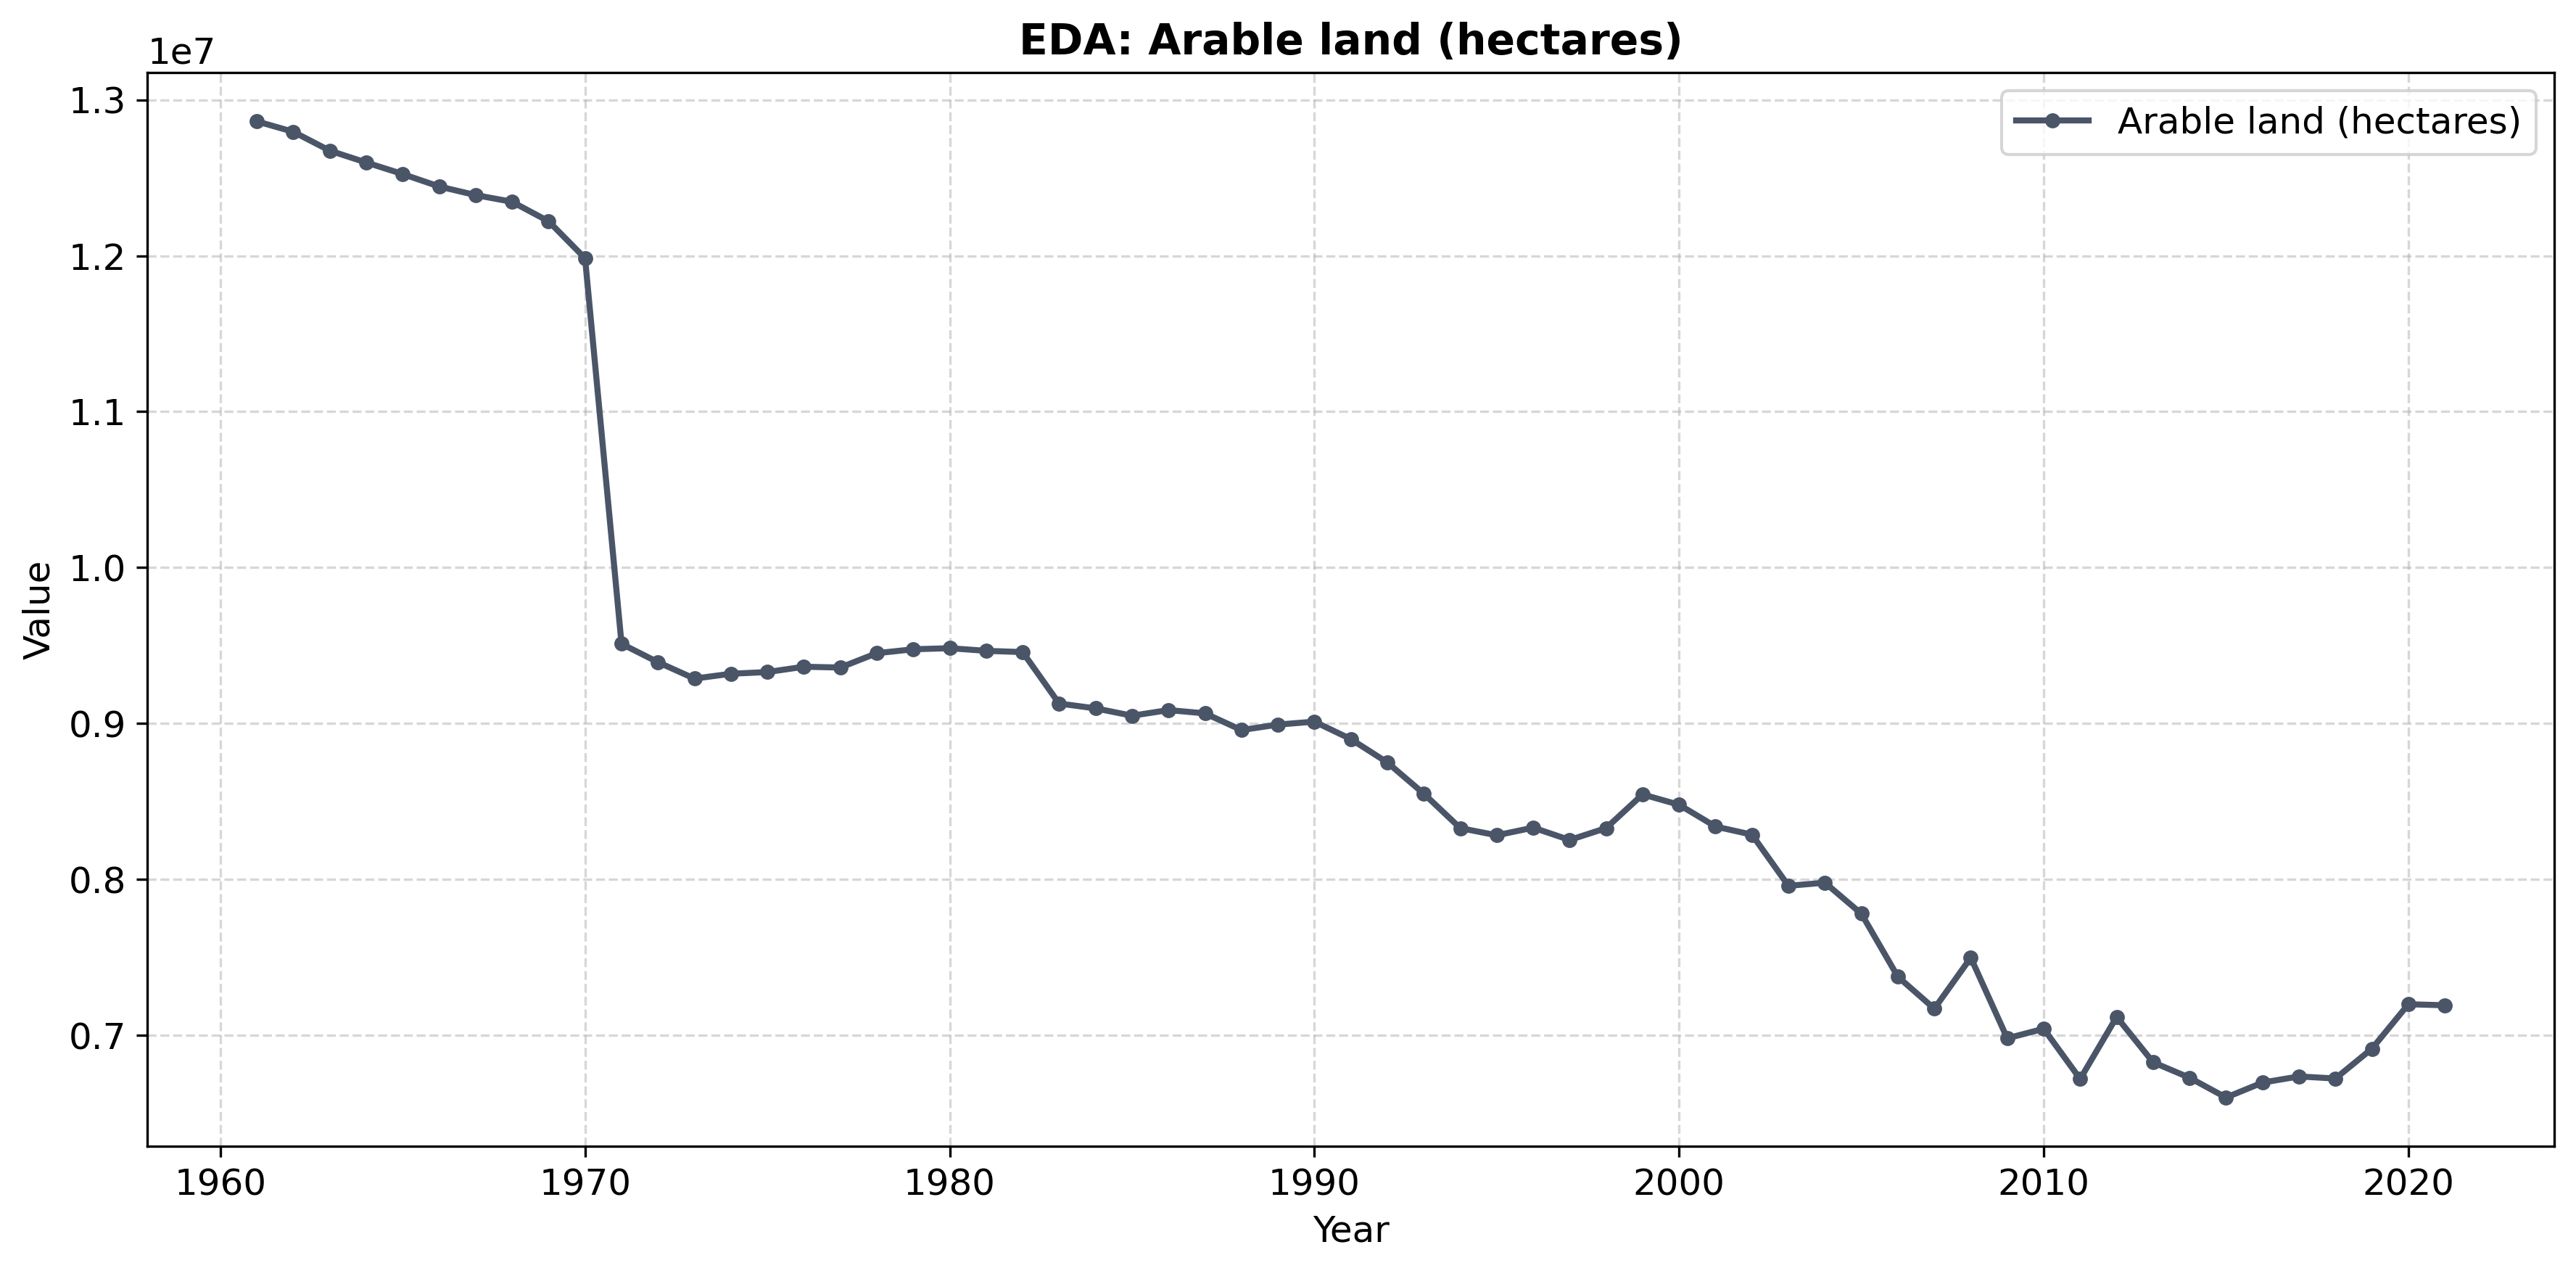

Saved: eda_cereal_production.png


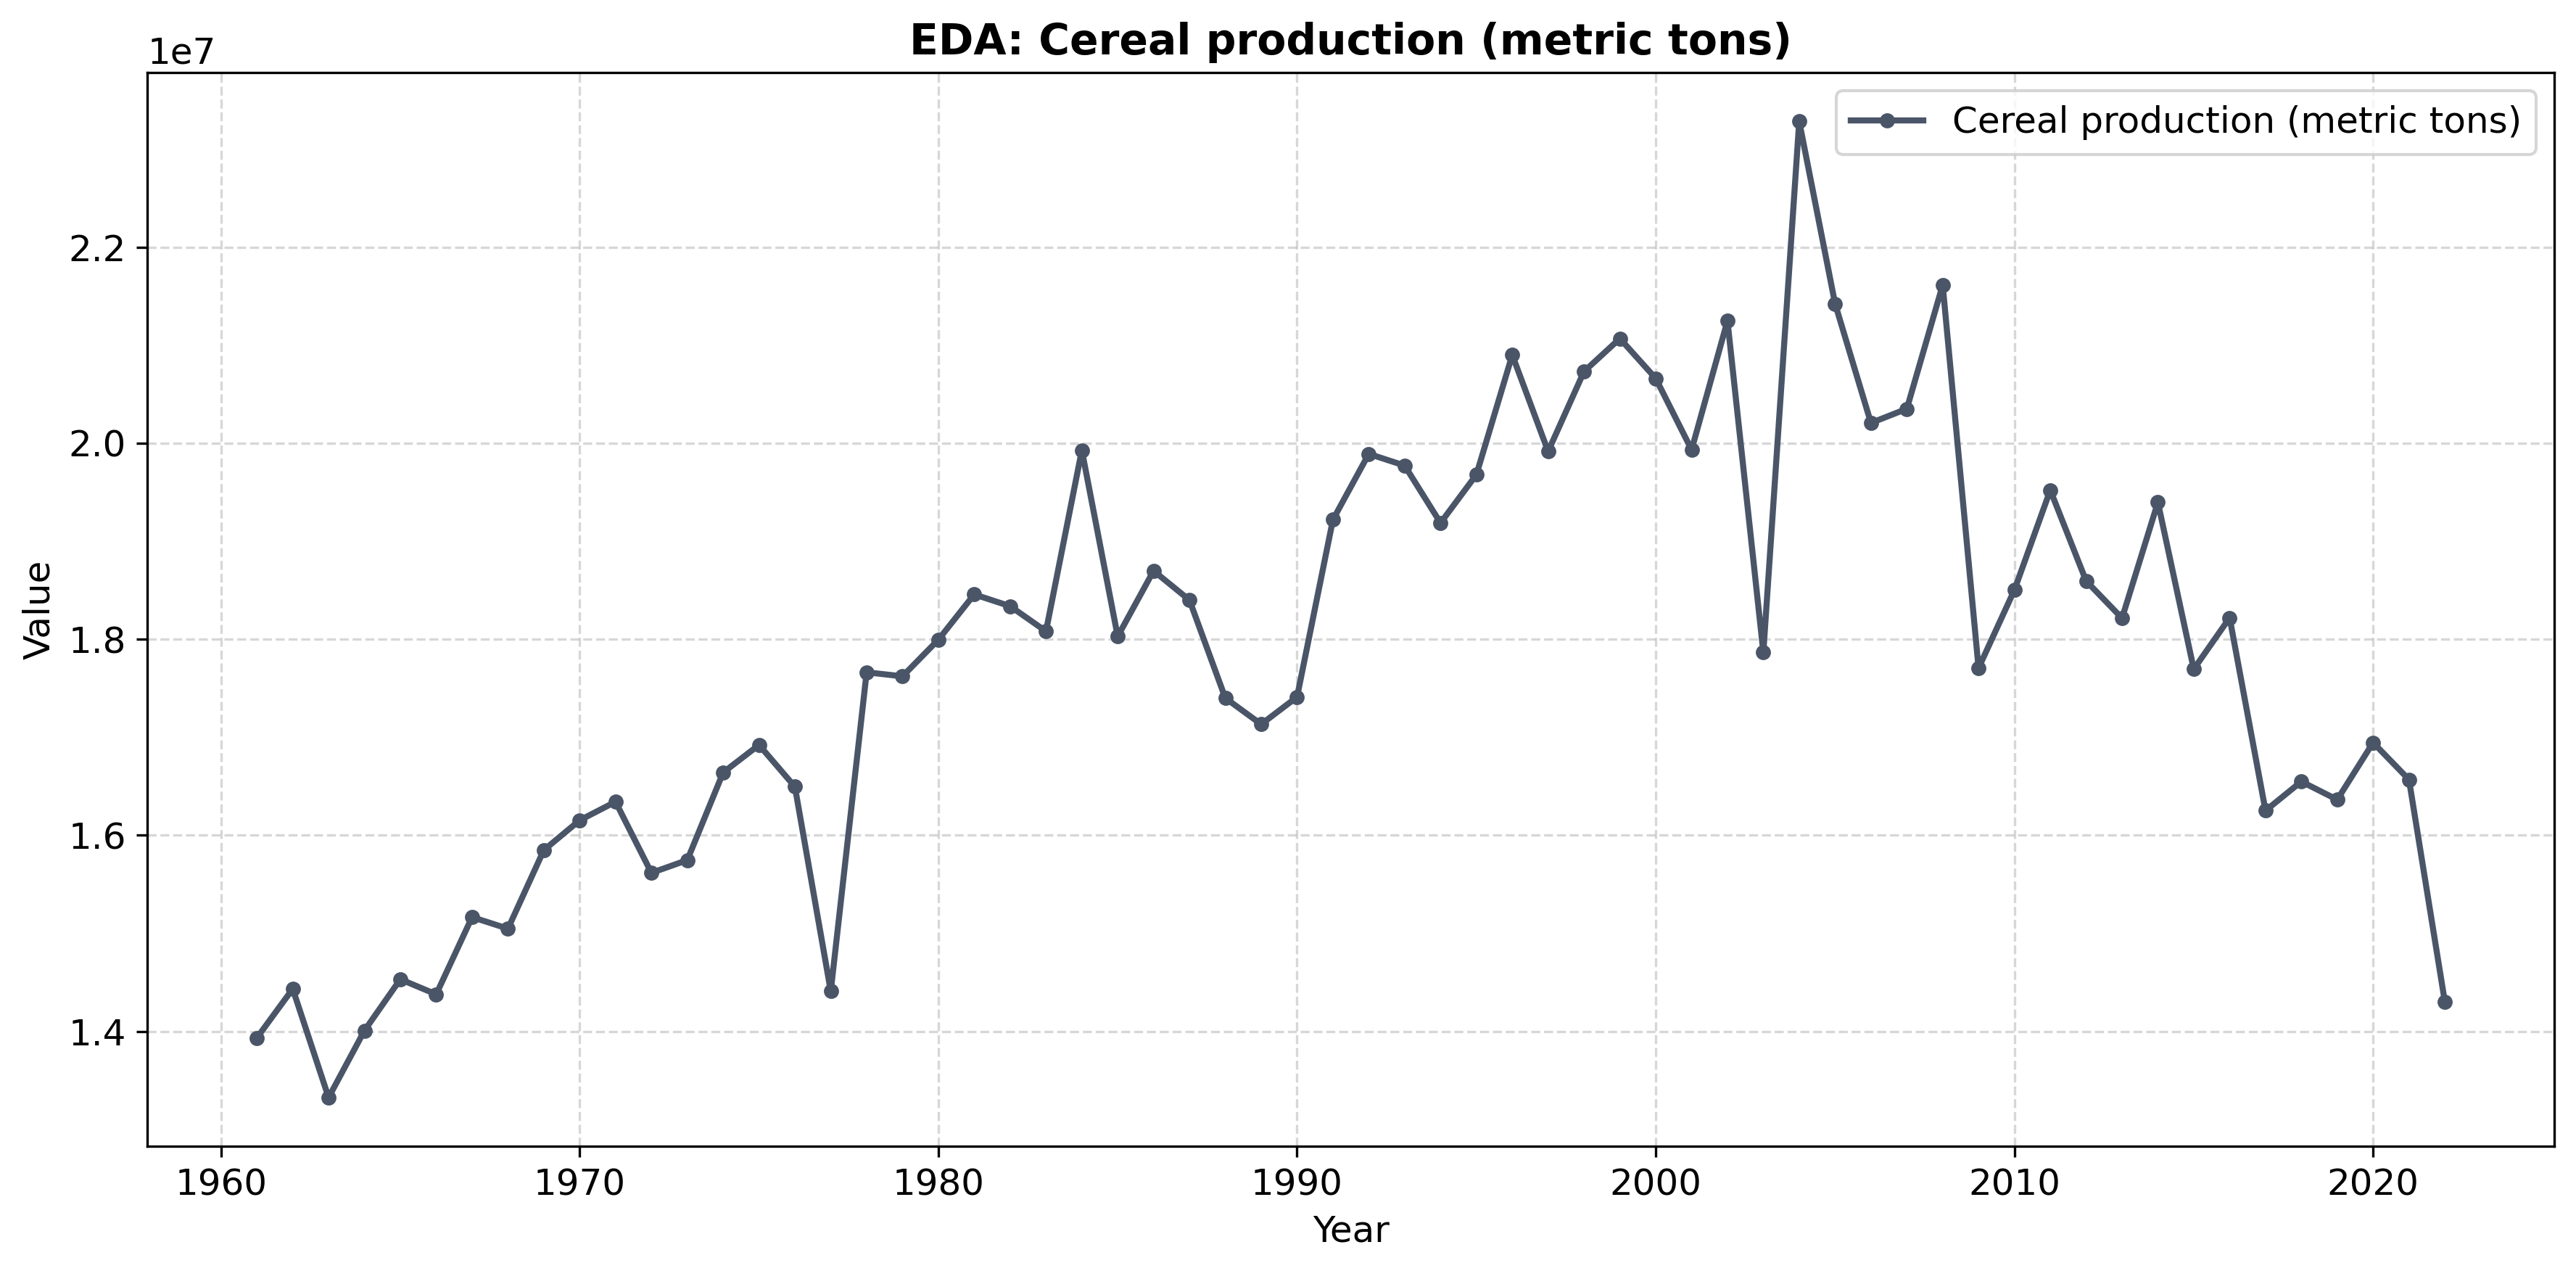

Saved: eda_cerealyield_abs.png


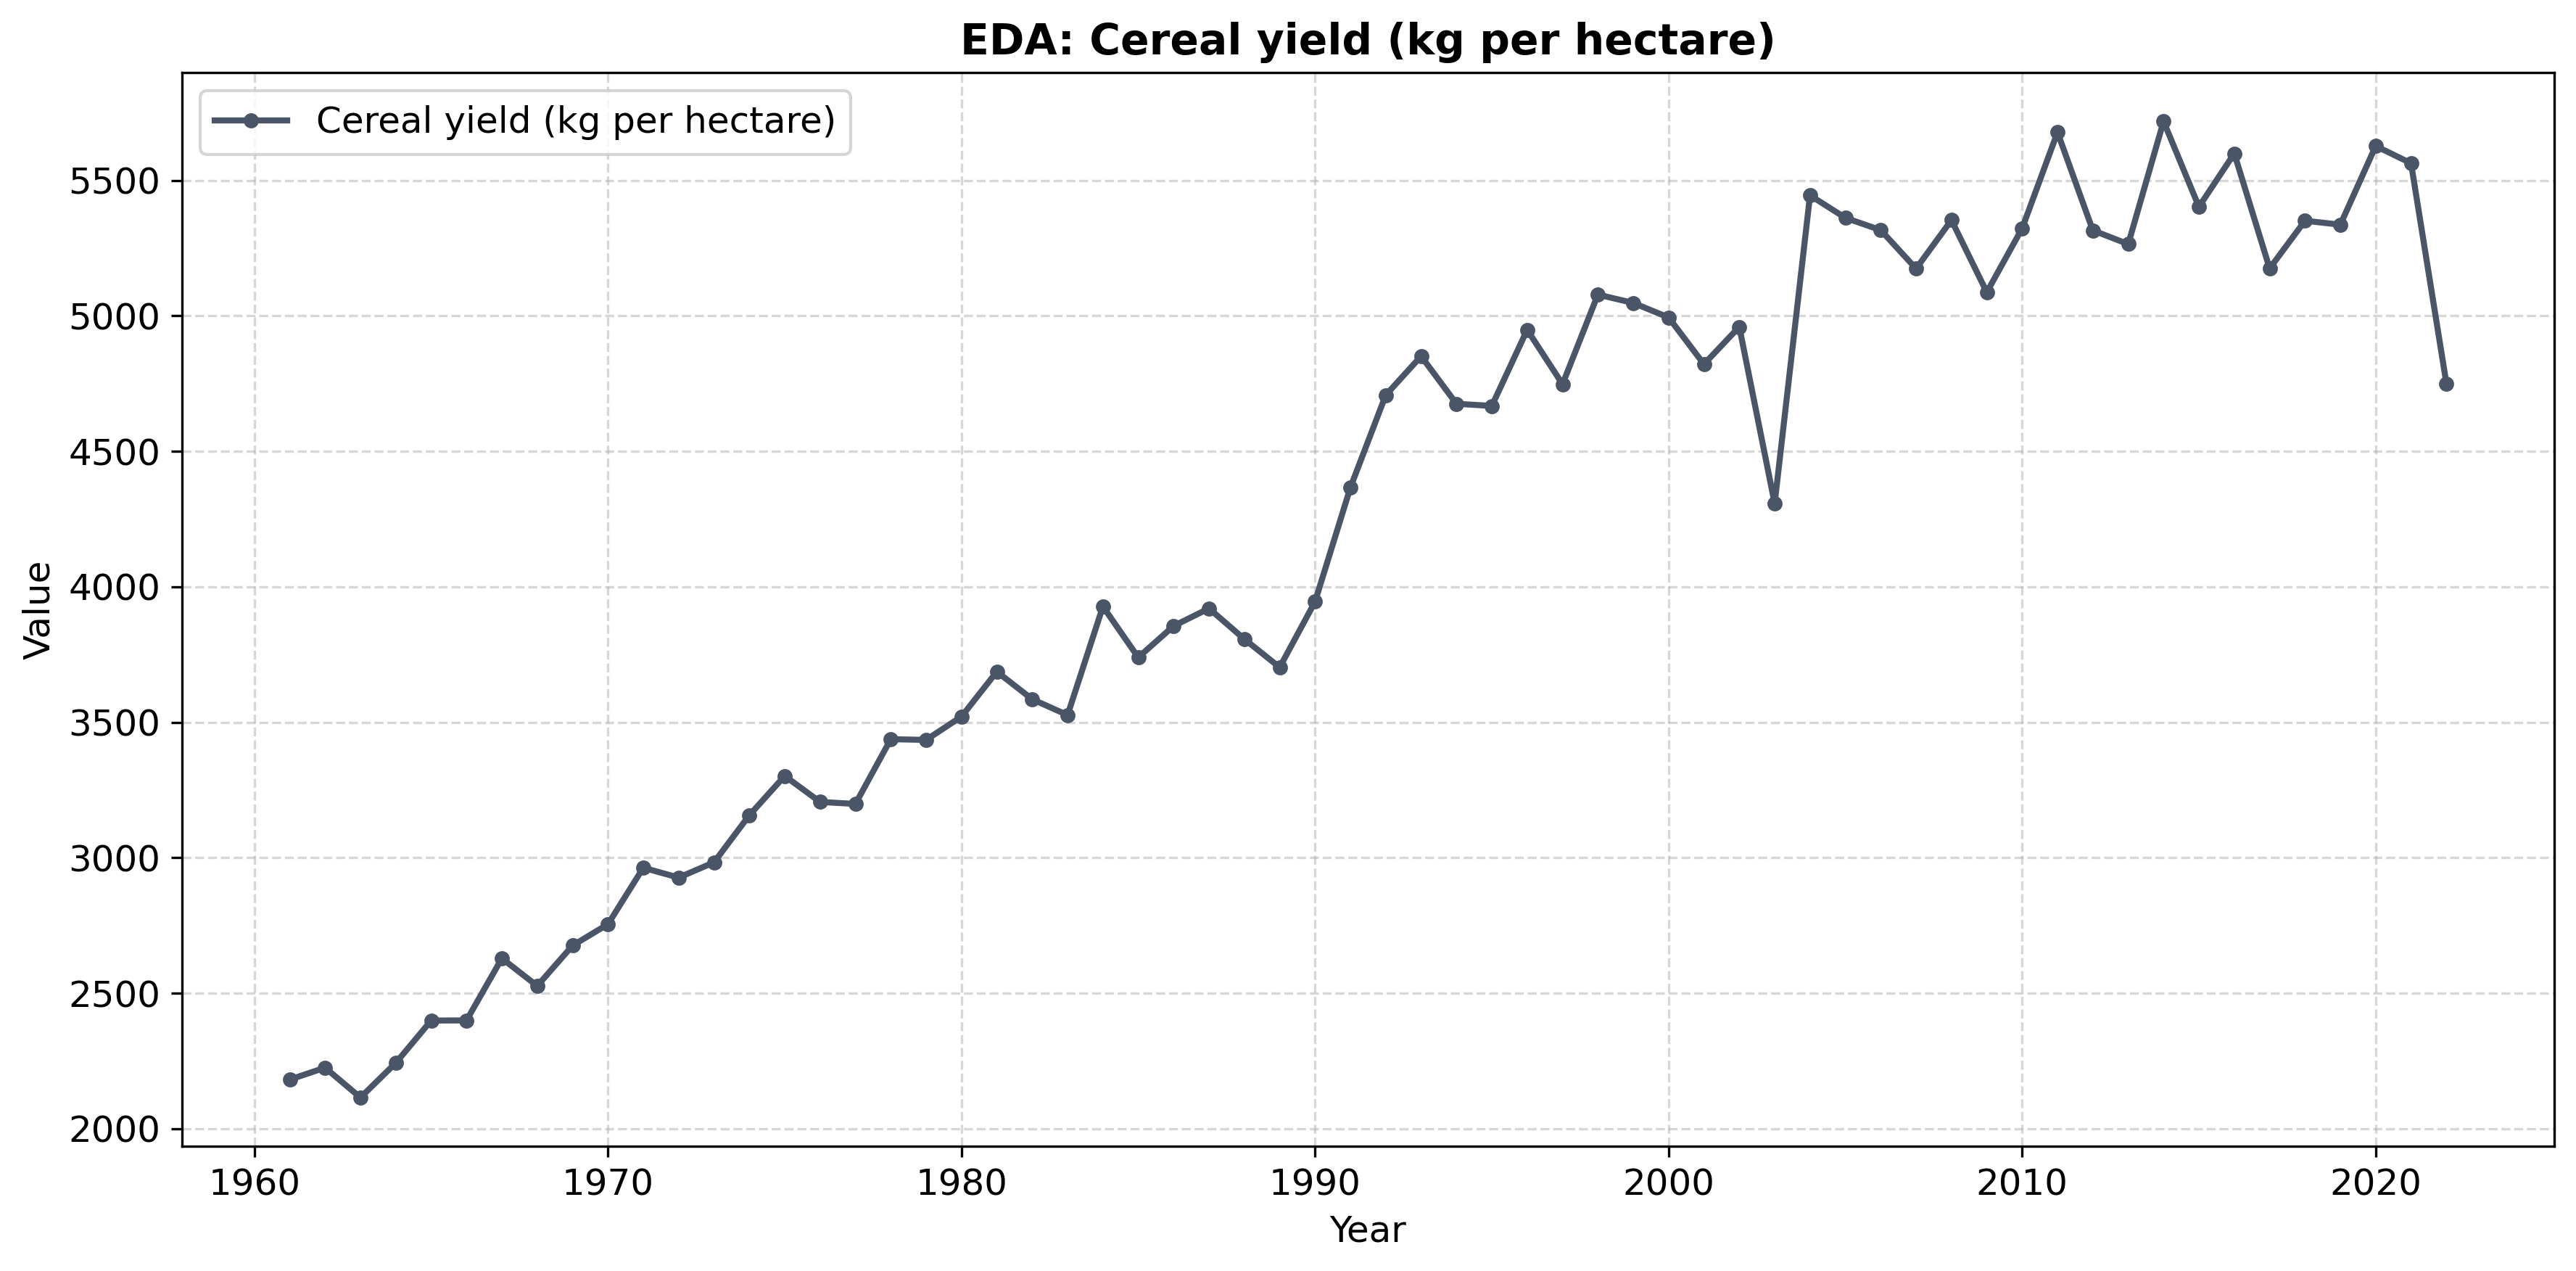

Saved: eda_crop_production_index.png


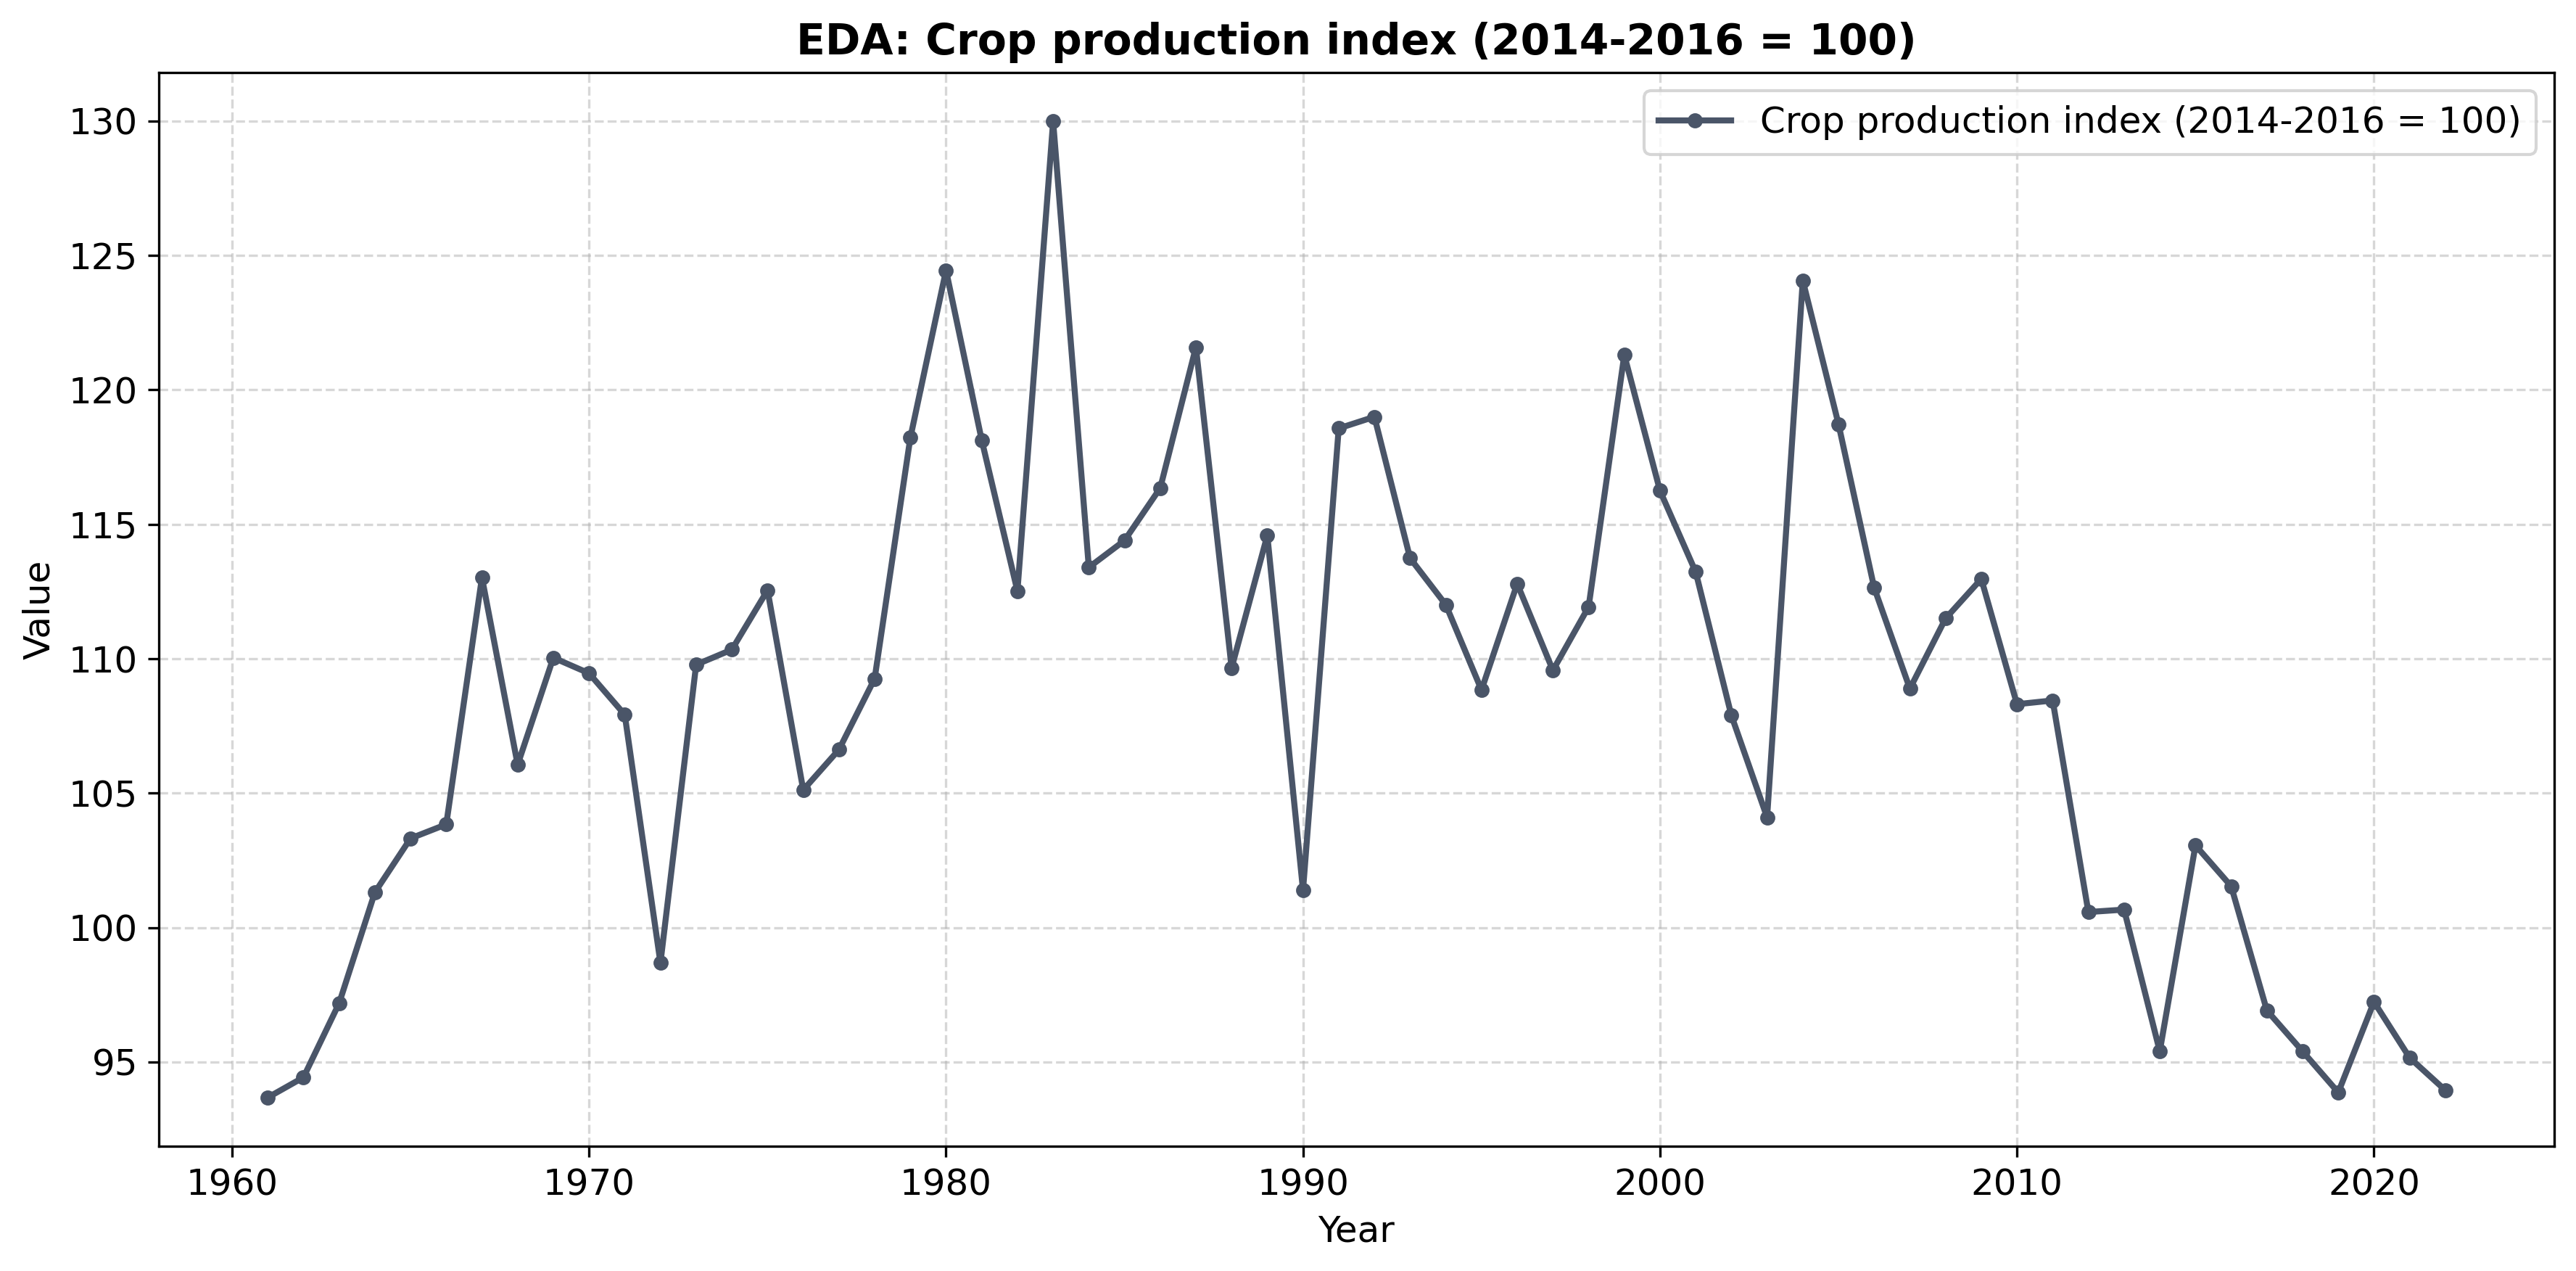

Saved: eda_employment_tot.png


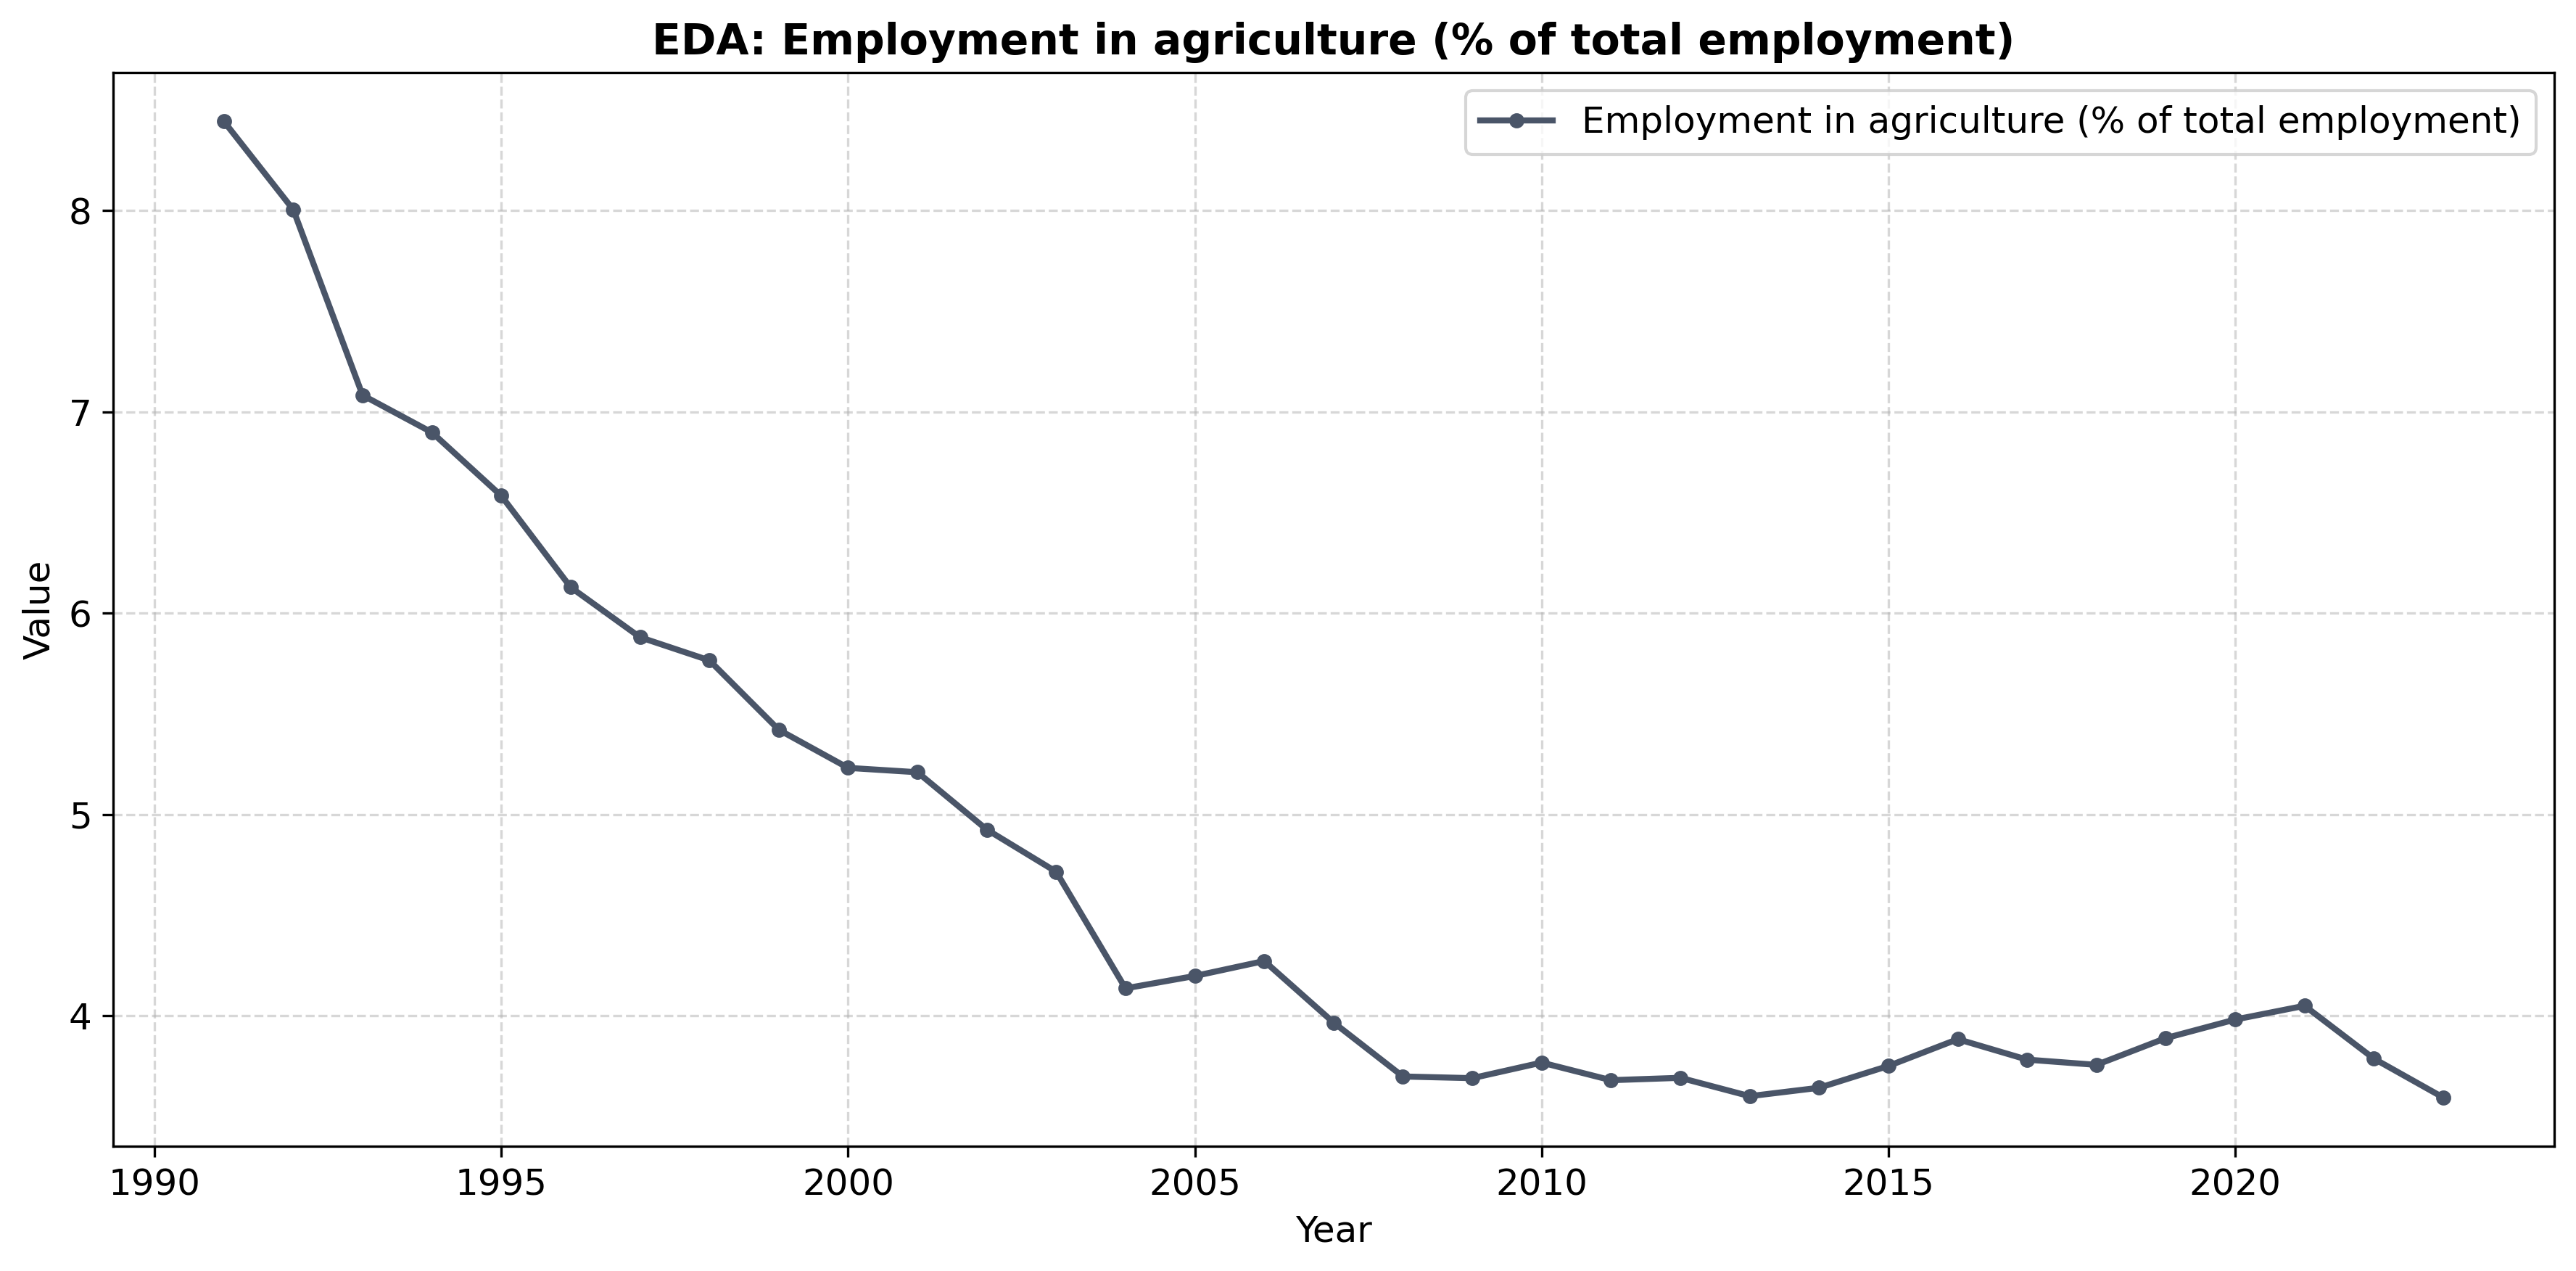

Saved: eda_employment_female.png


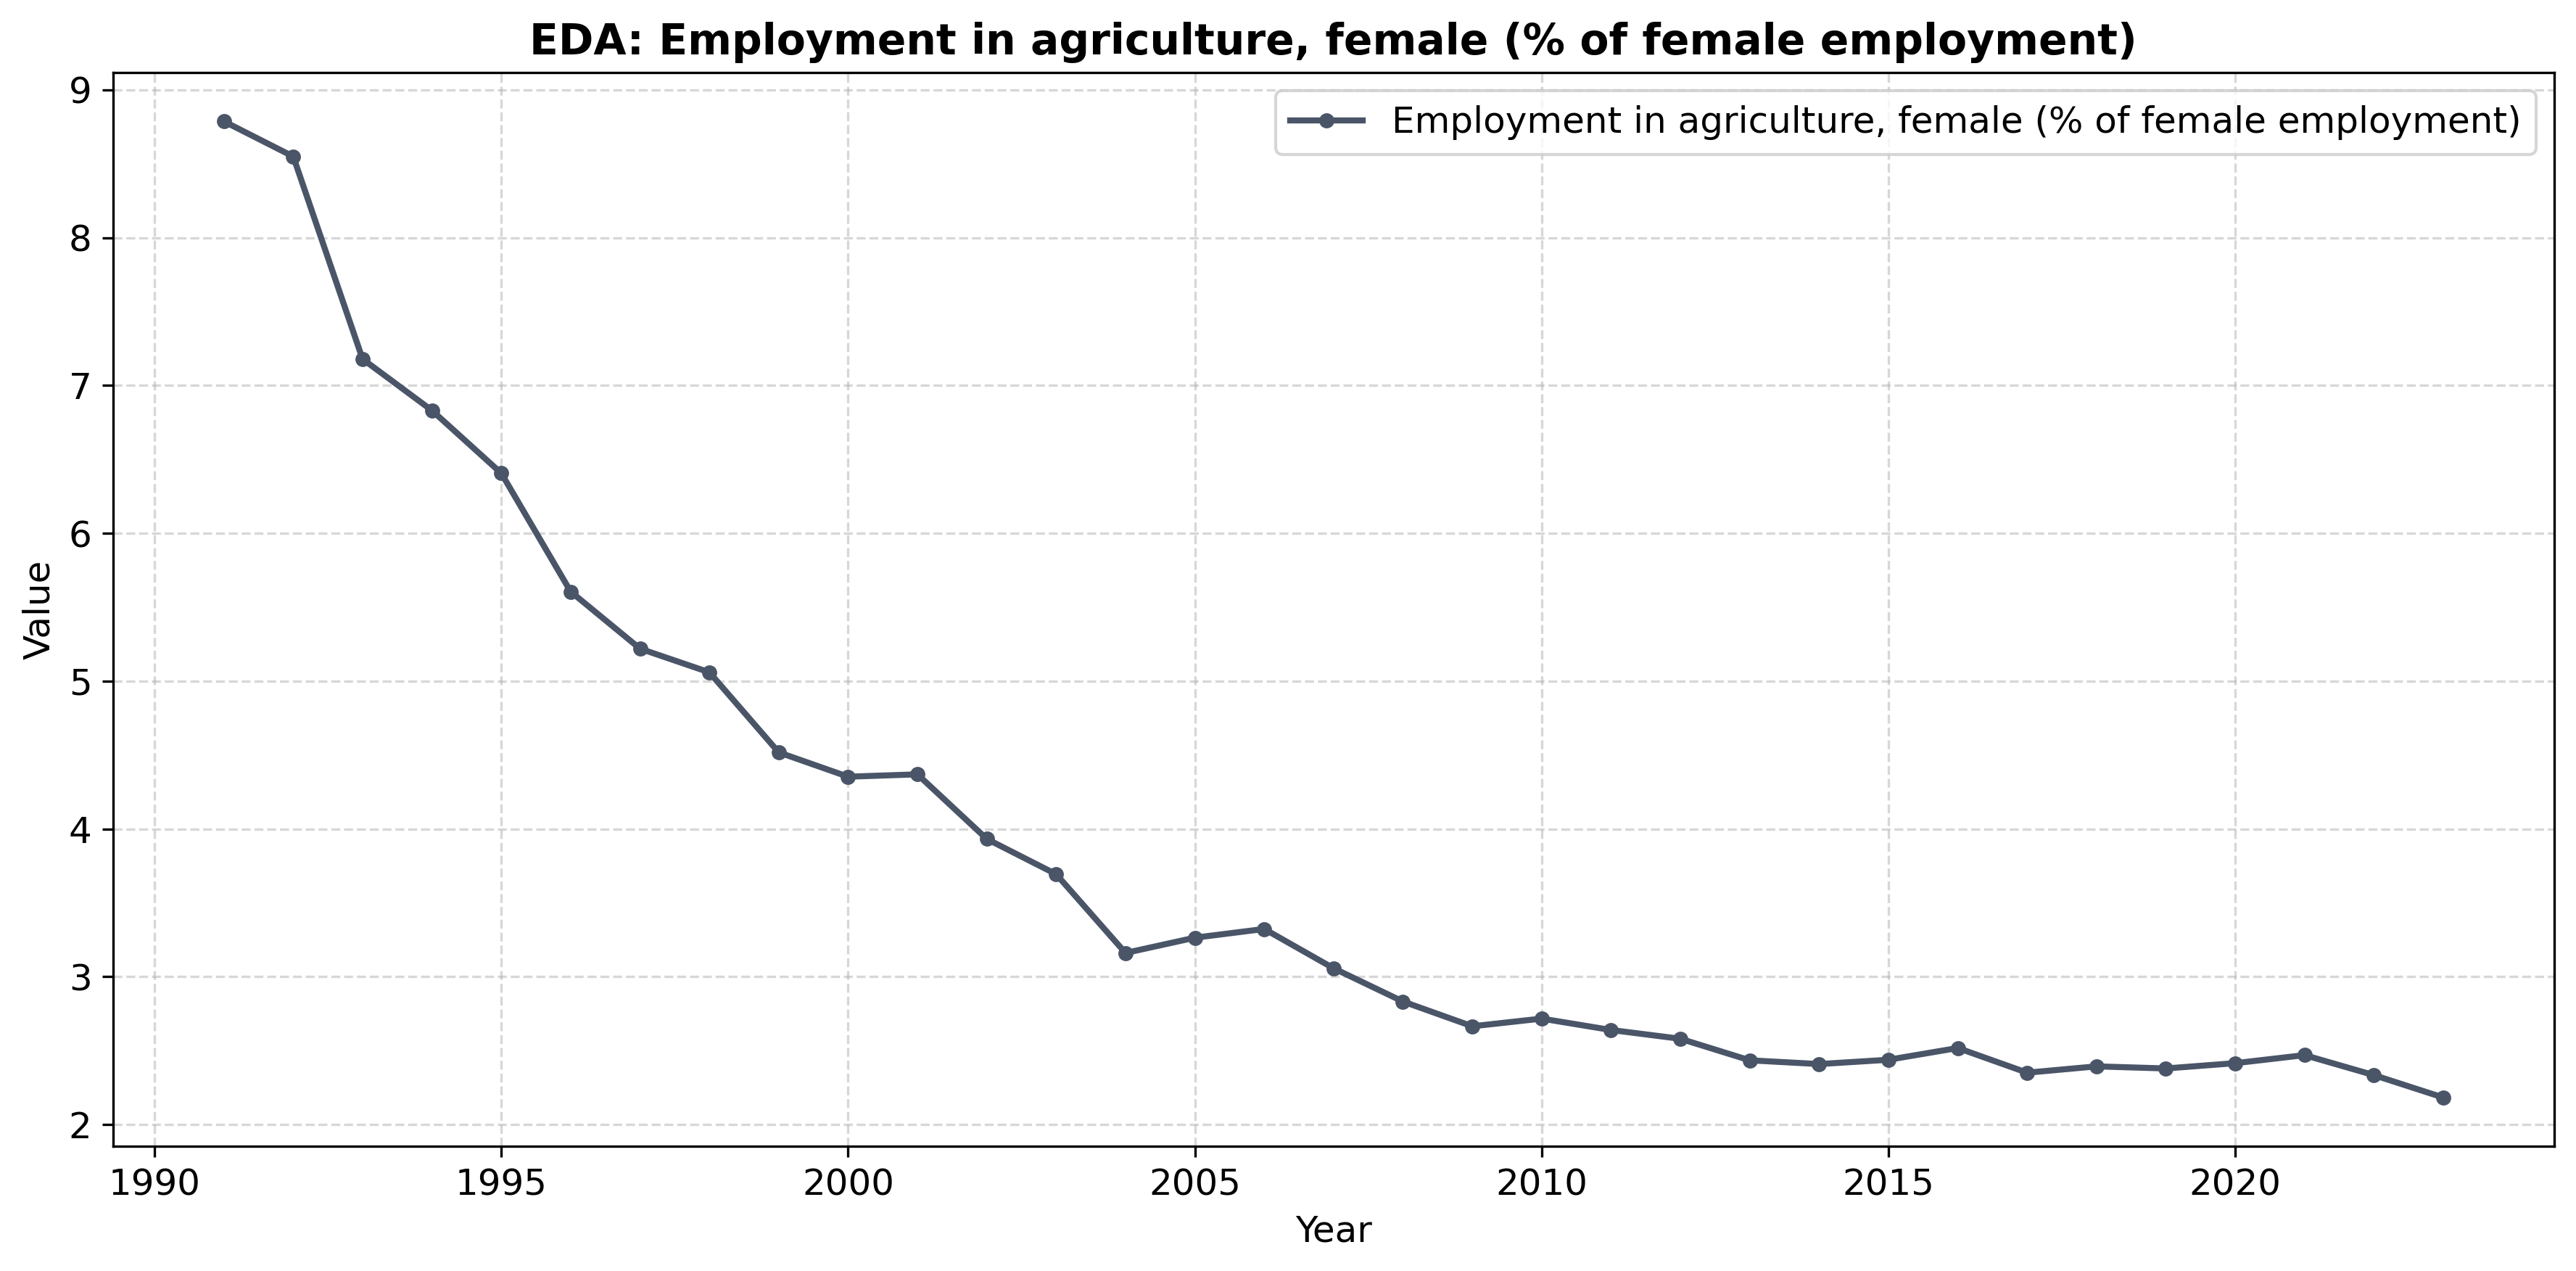

Saved: eda_employment_male.png


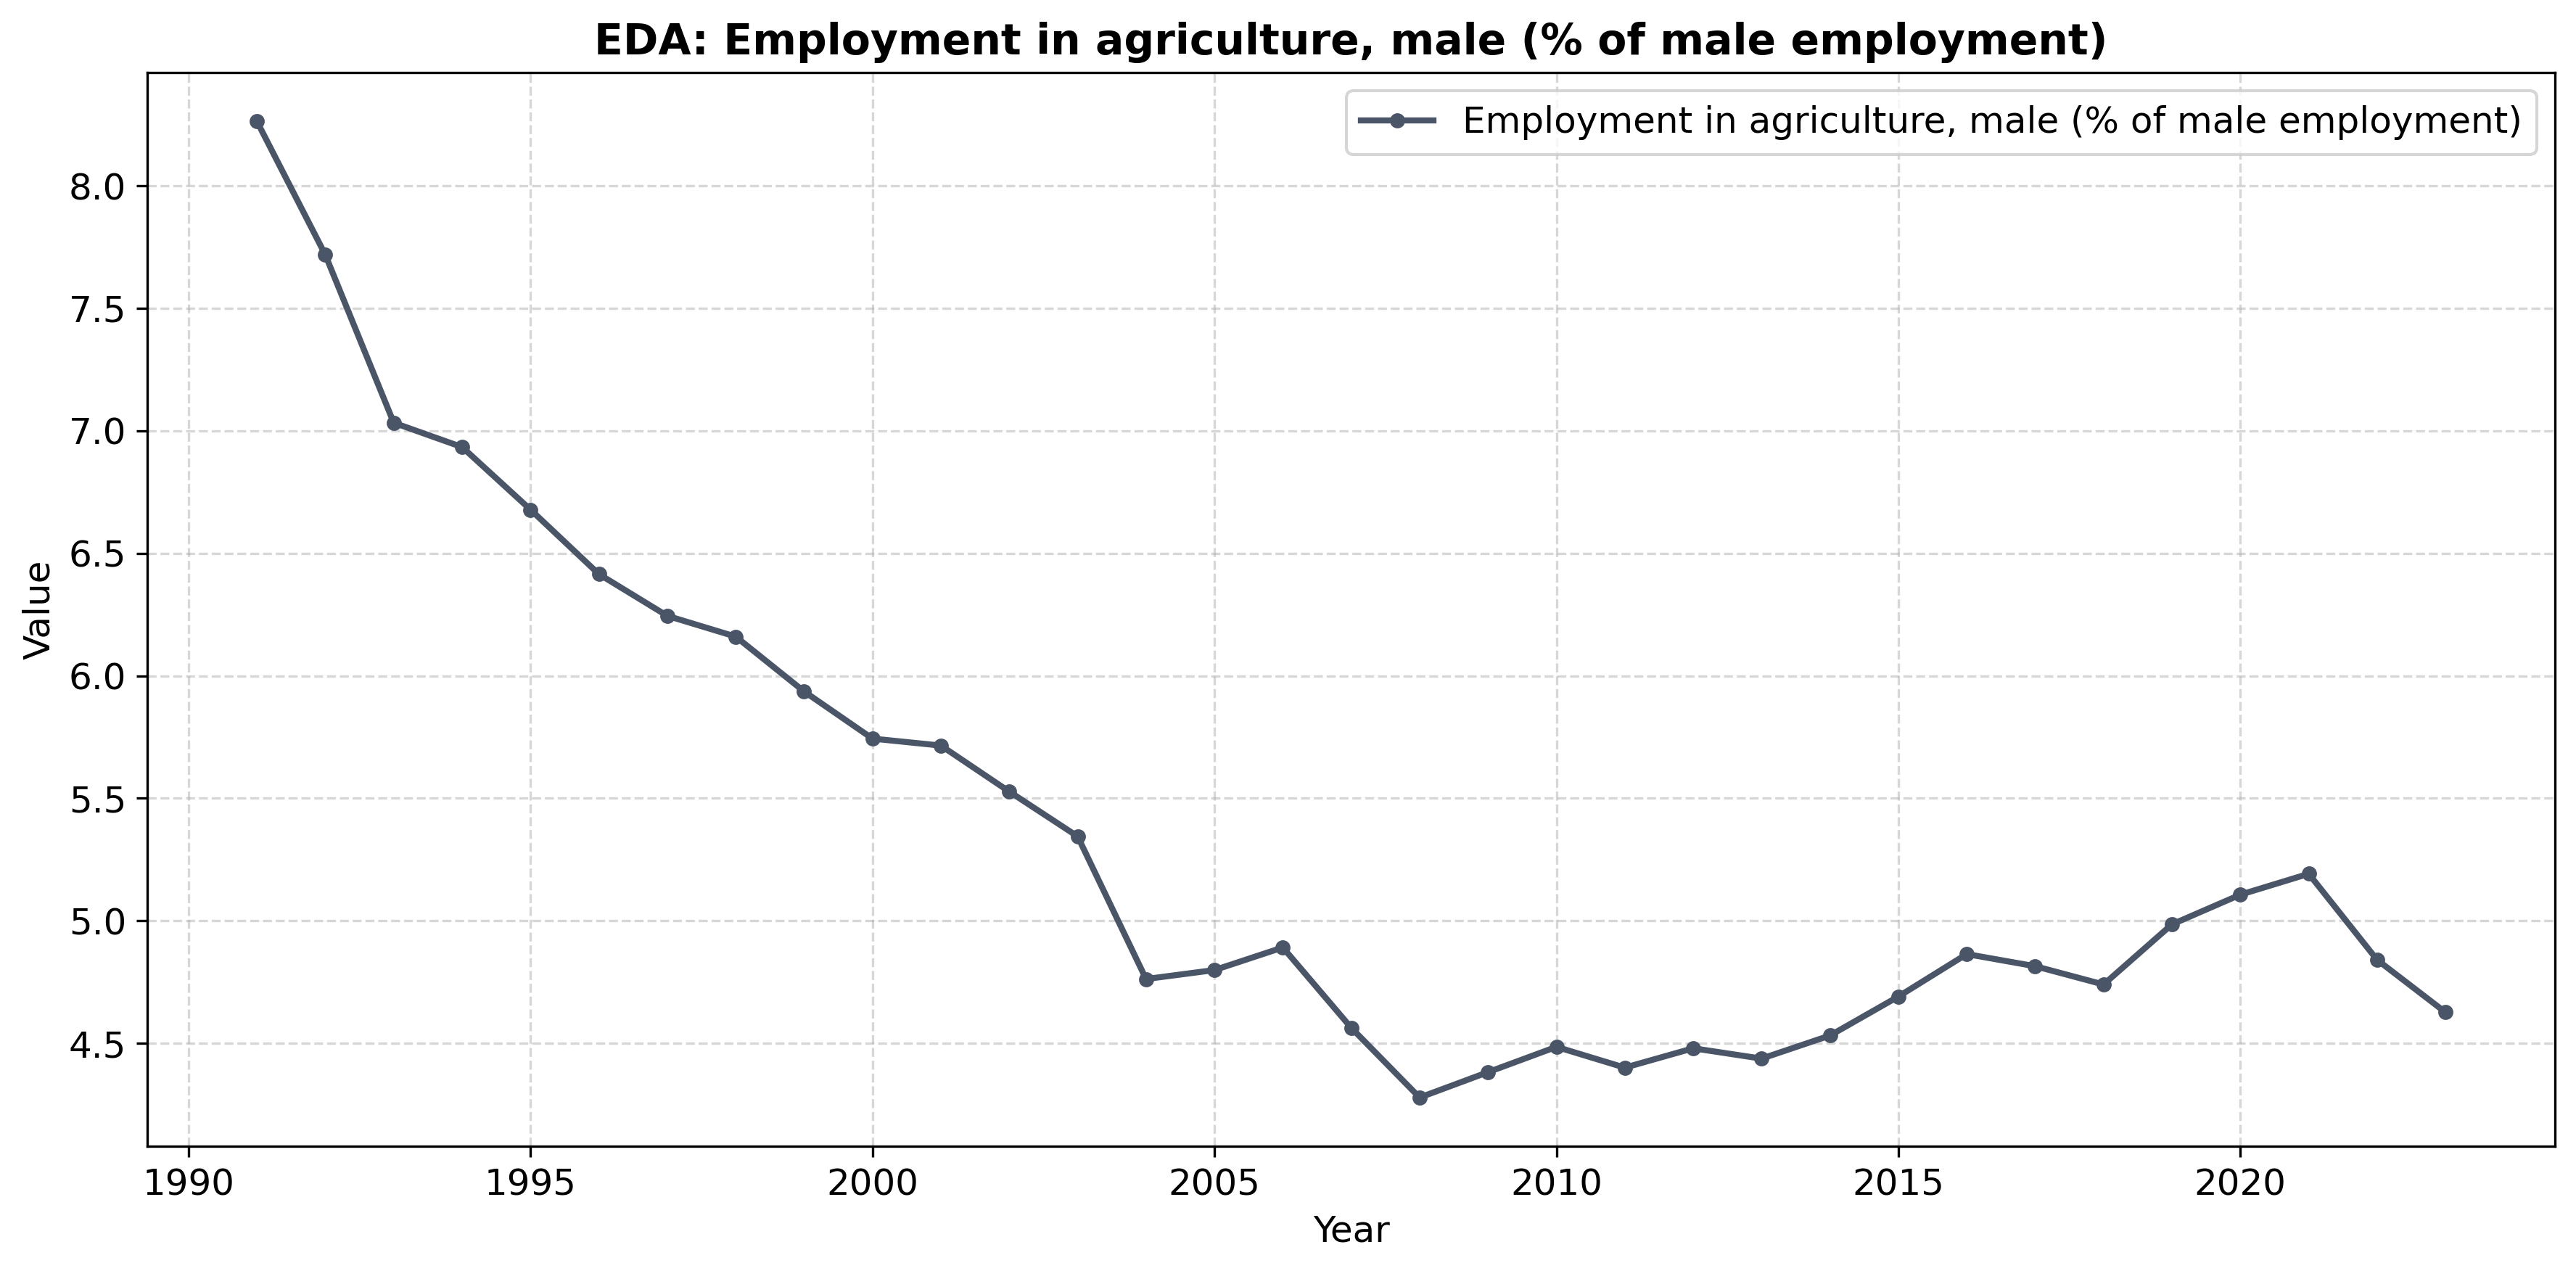

Saved: eda_fertilizer_percent.png


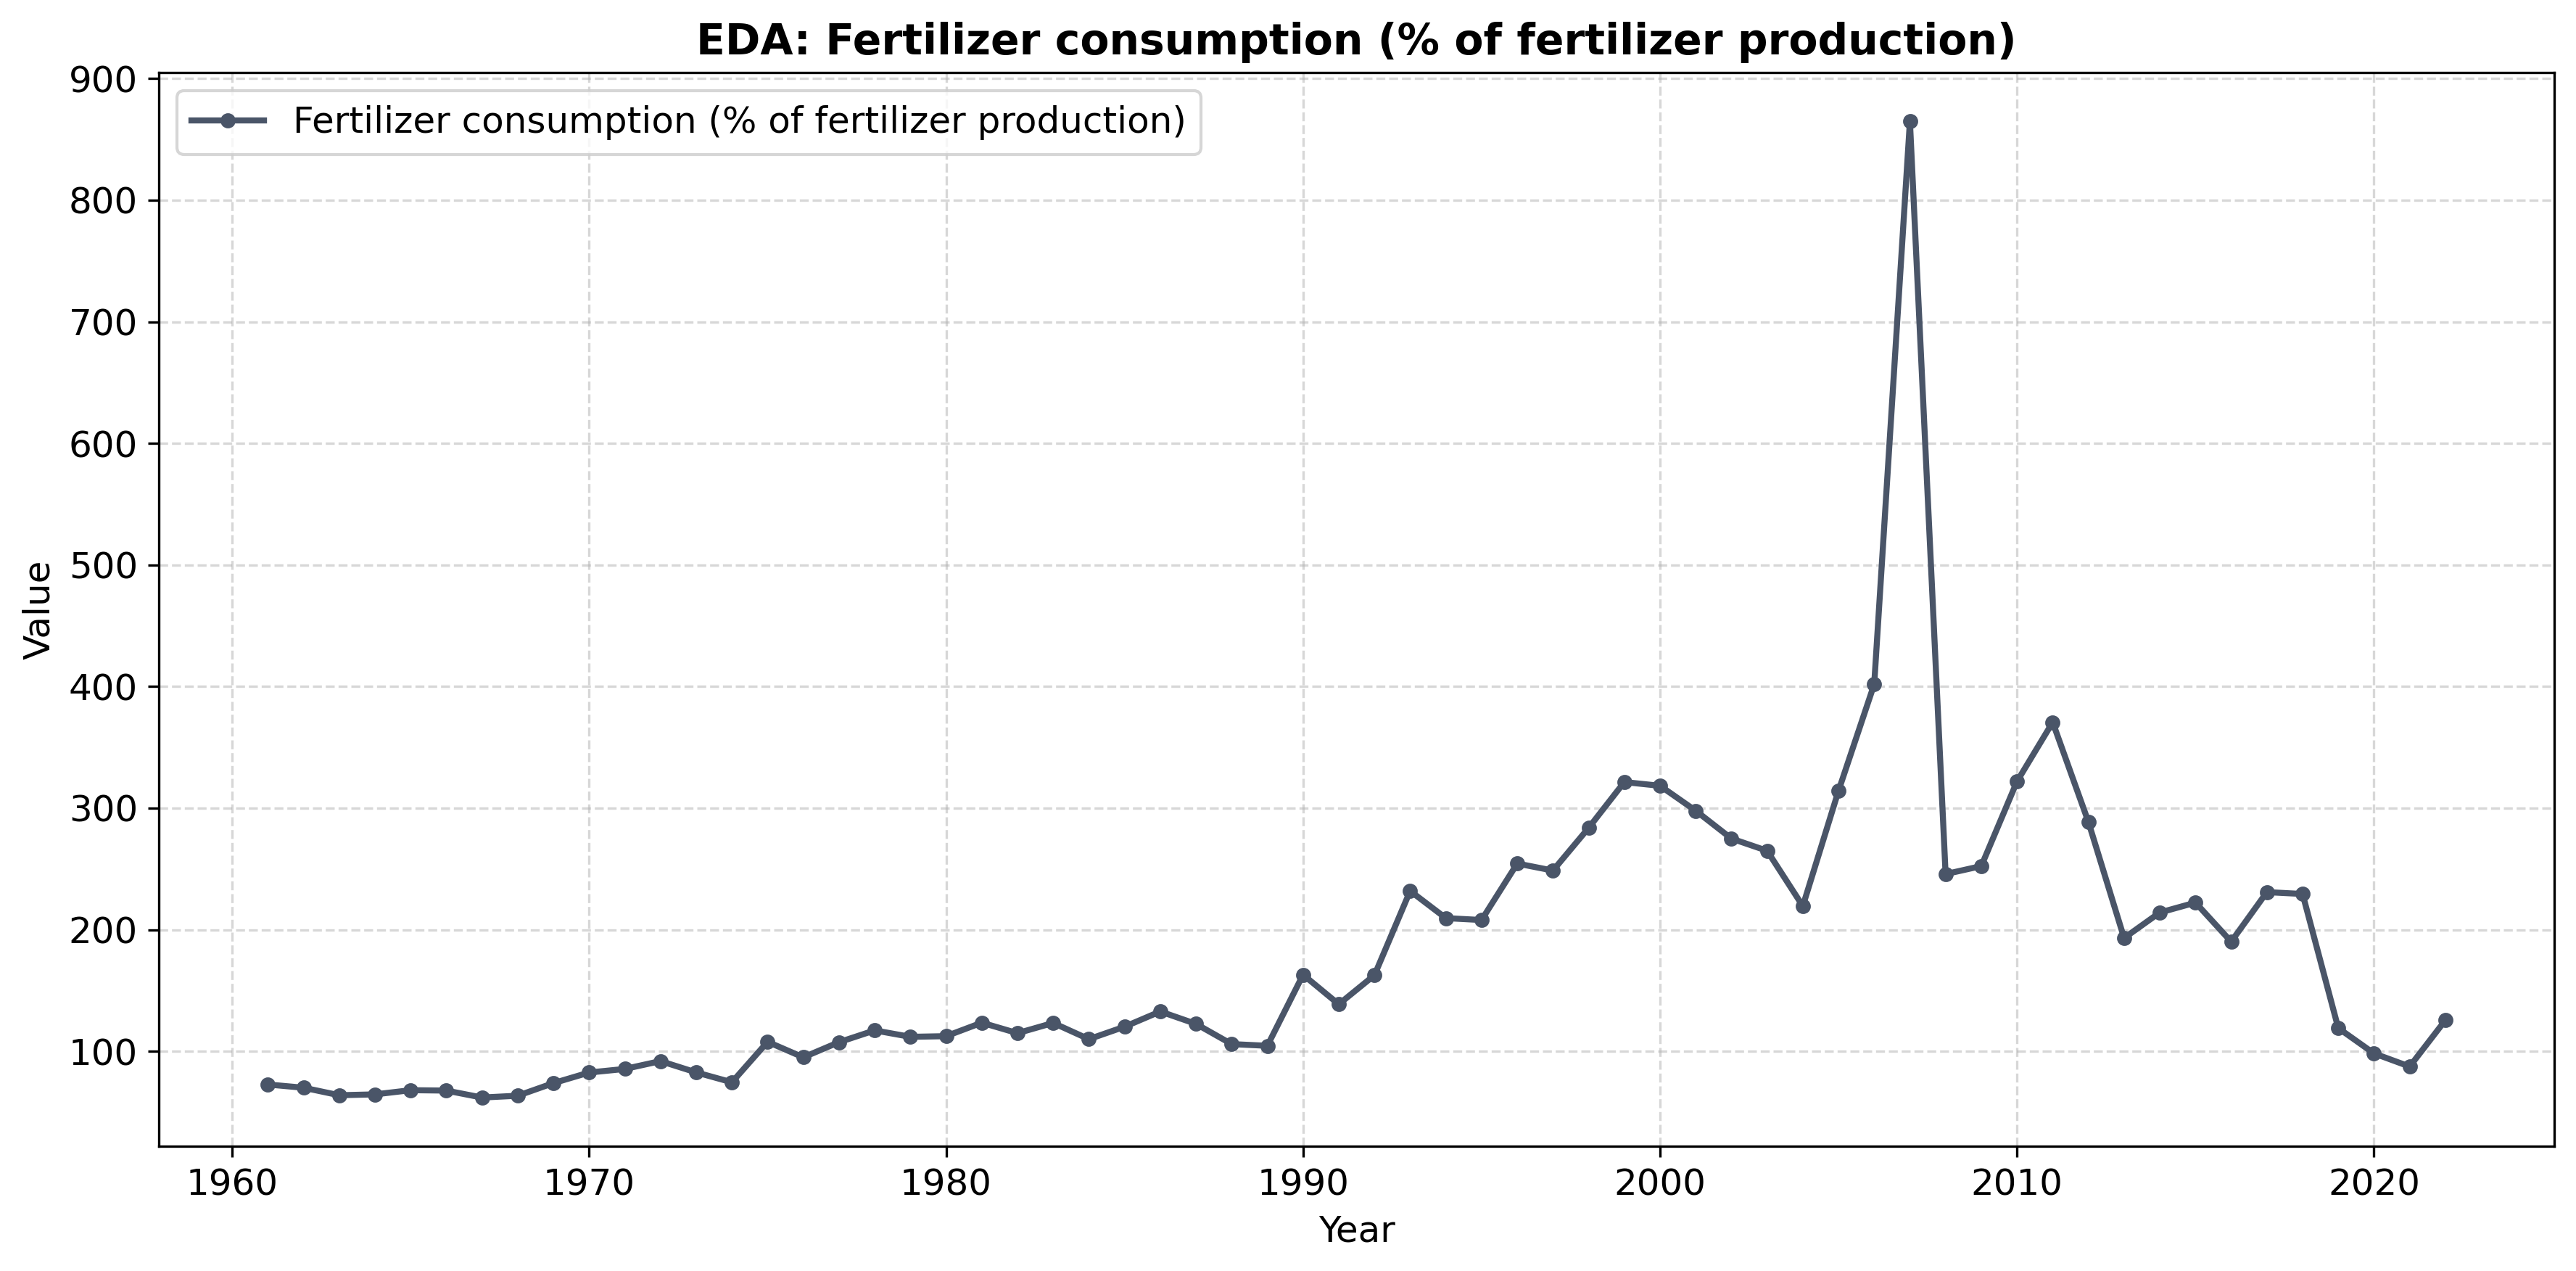

Saved: eda_fertilizer_abs.png


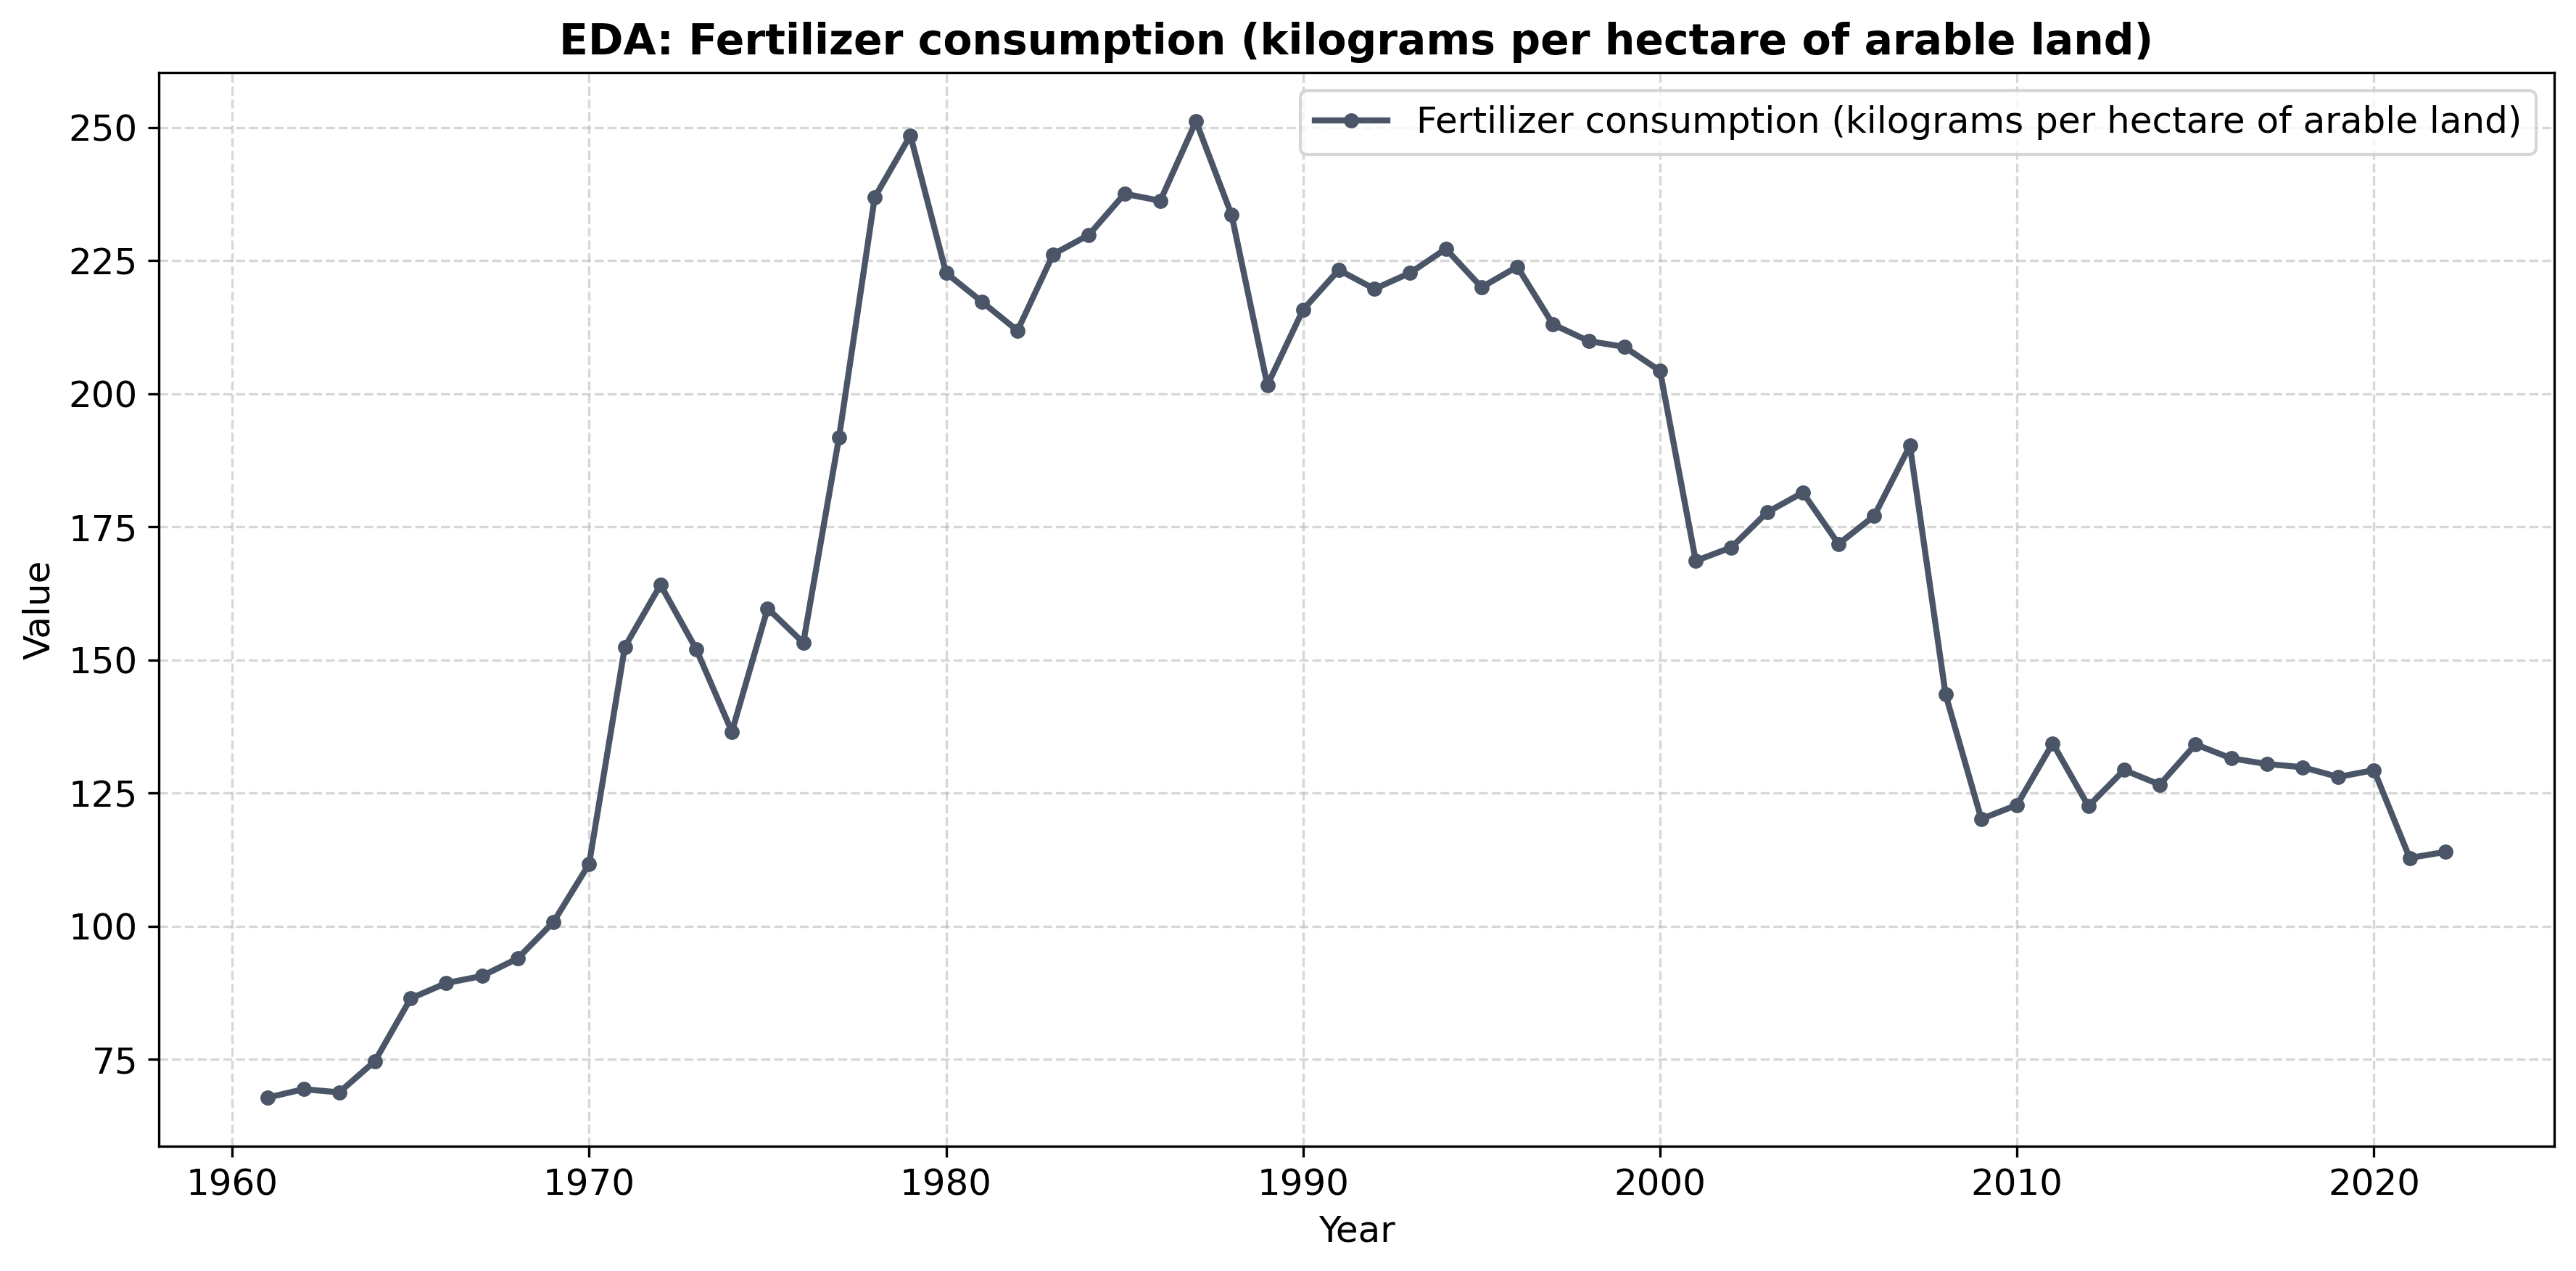

Saved: eda_food_production_index.png


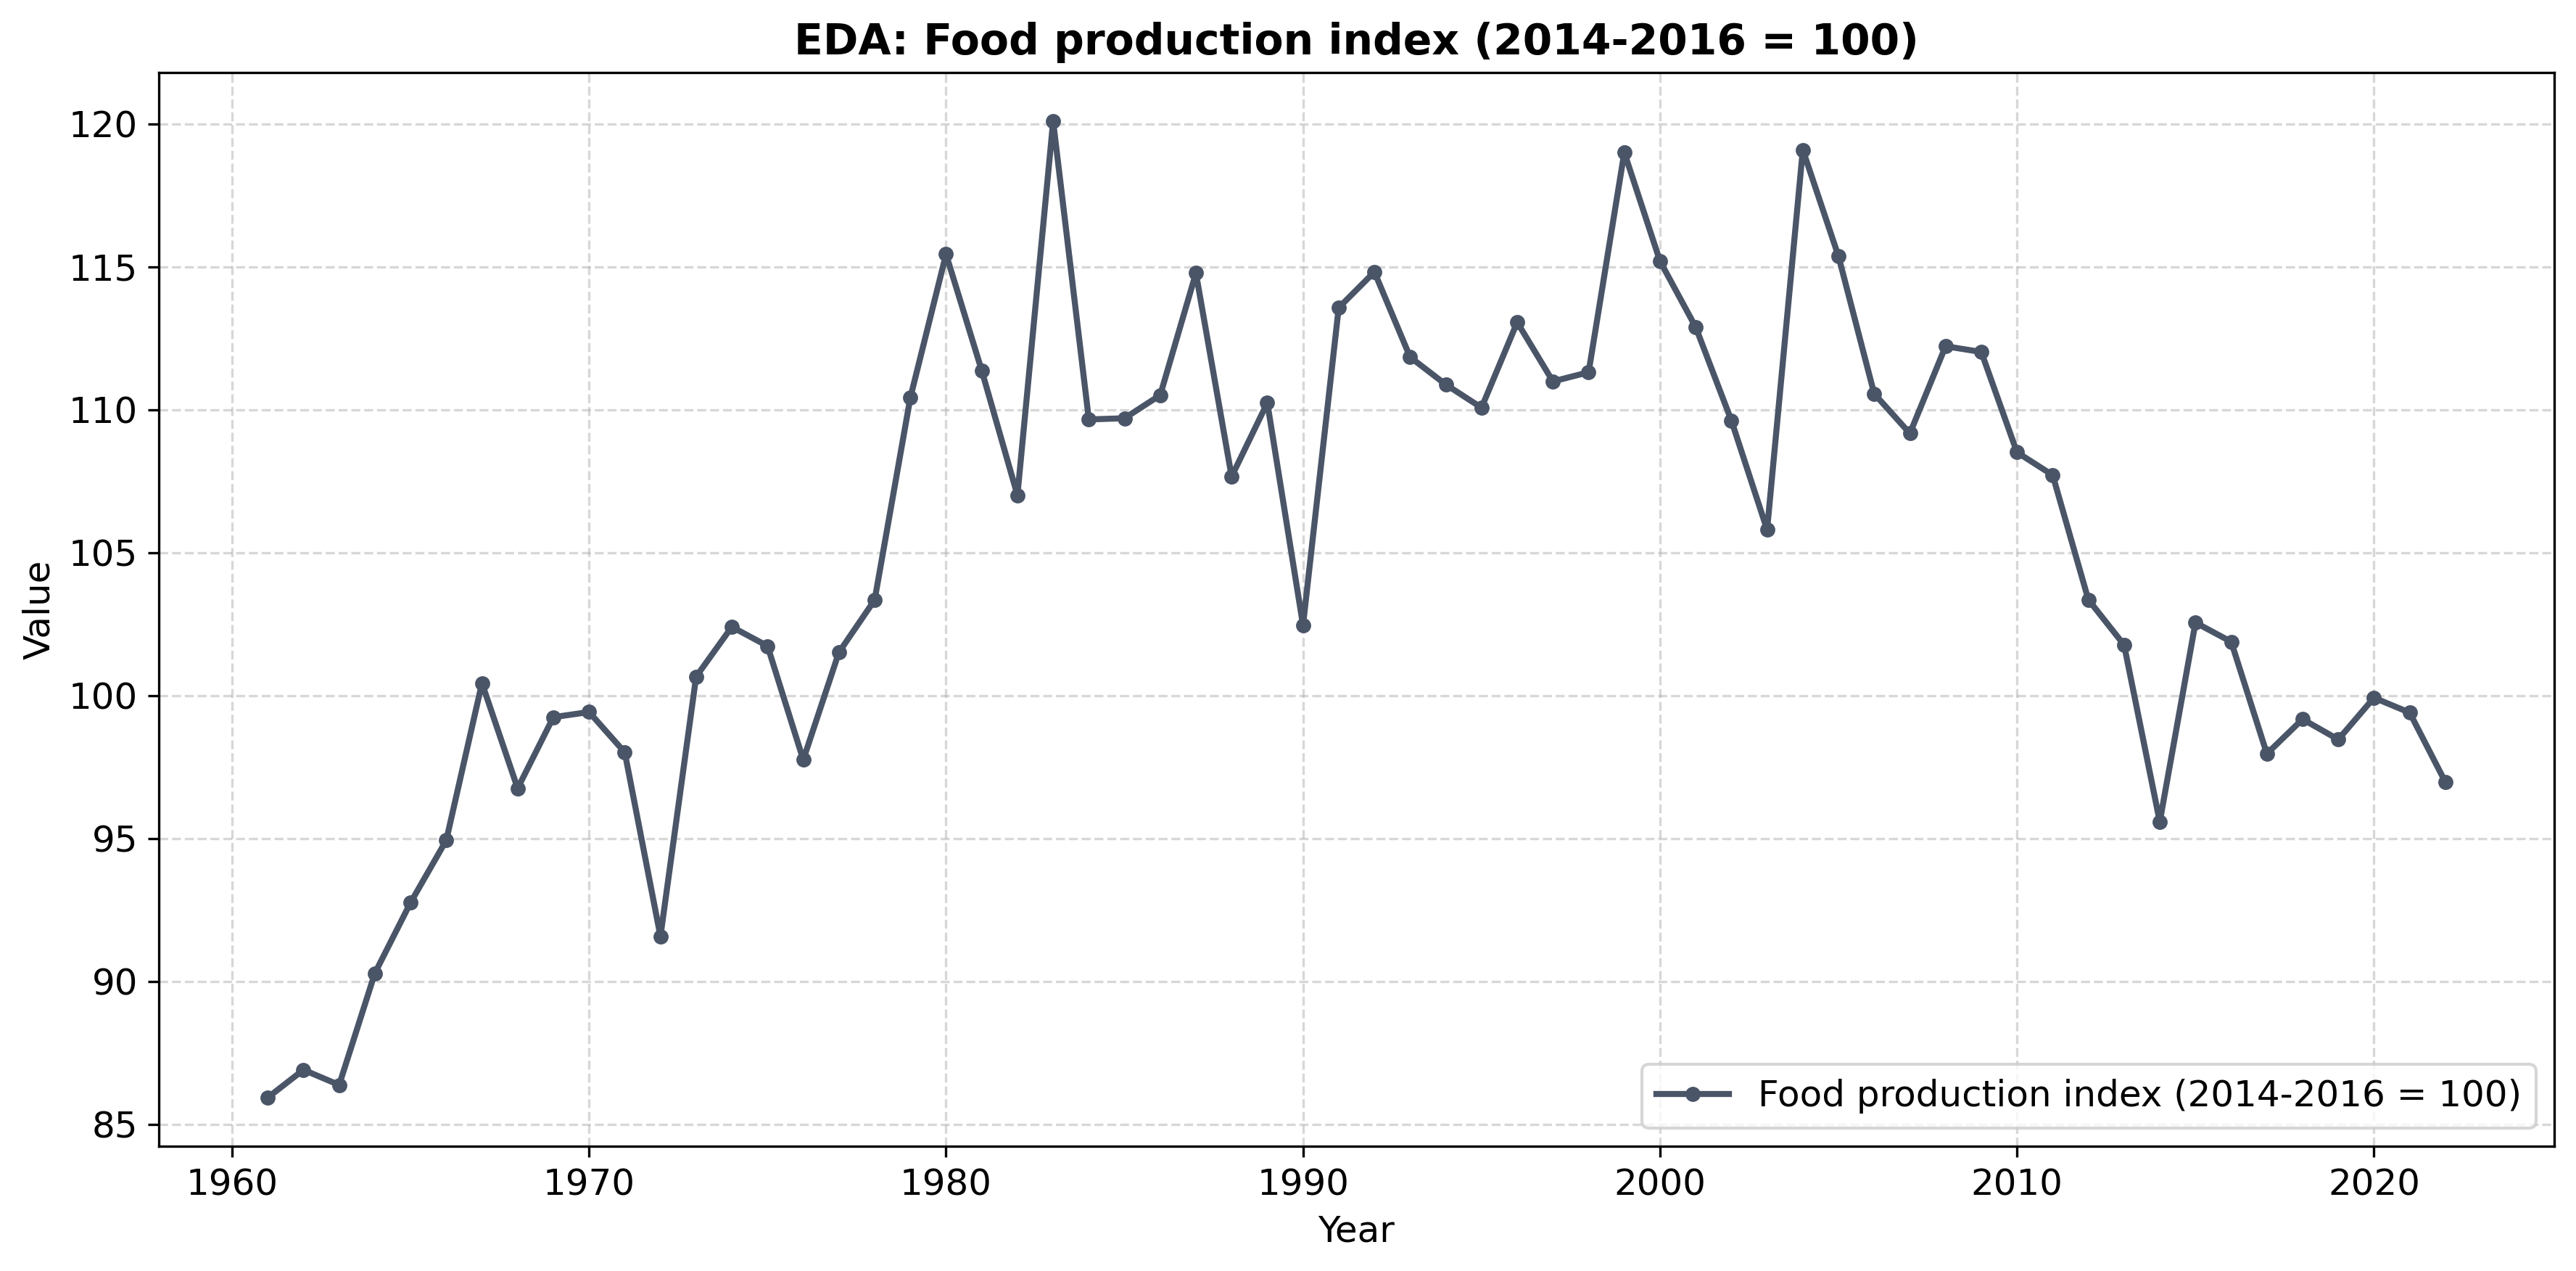

Saved: eda_forestarea_percent.png


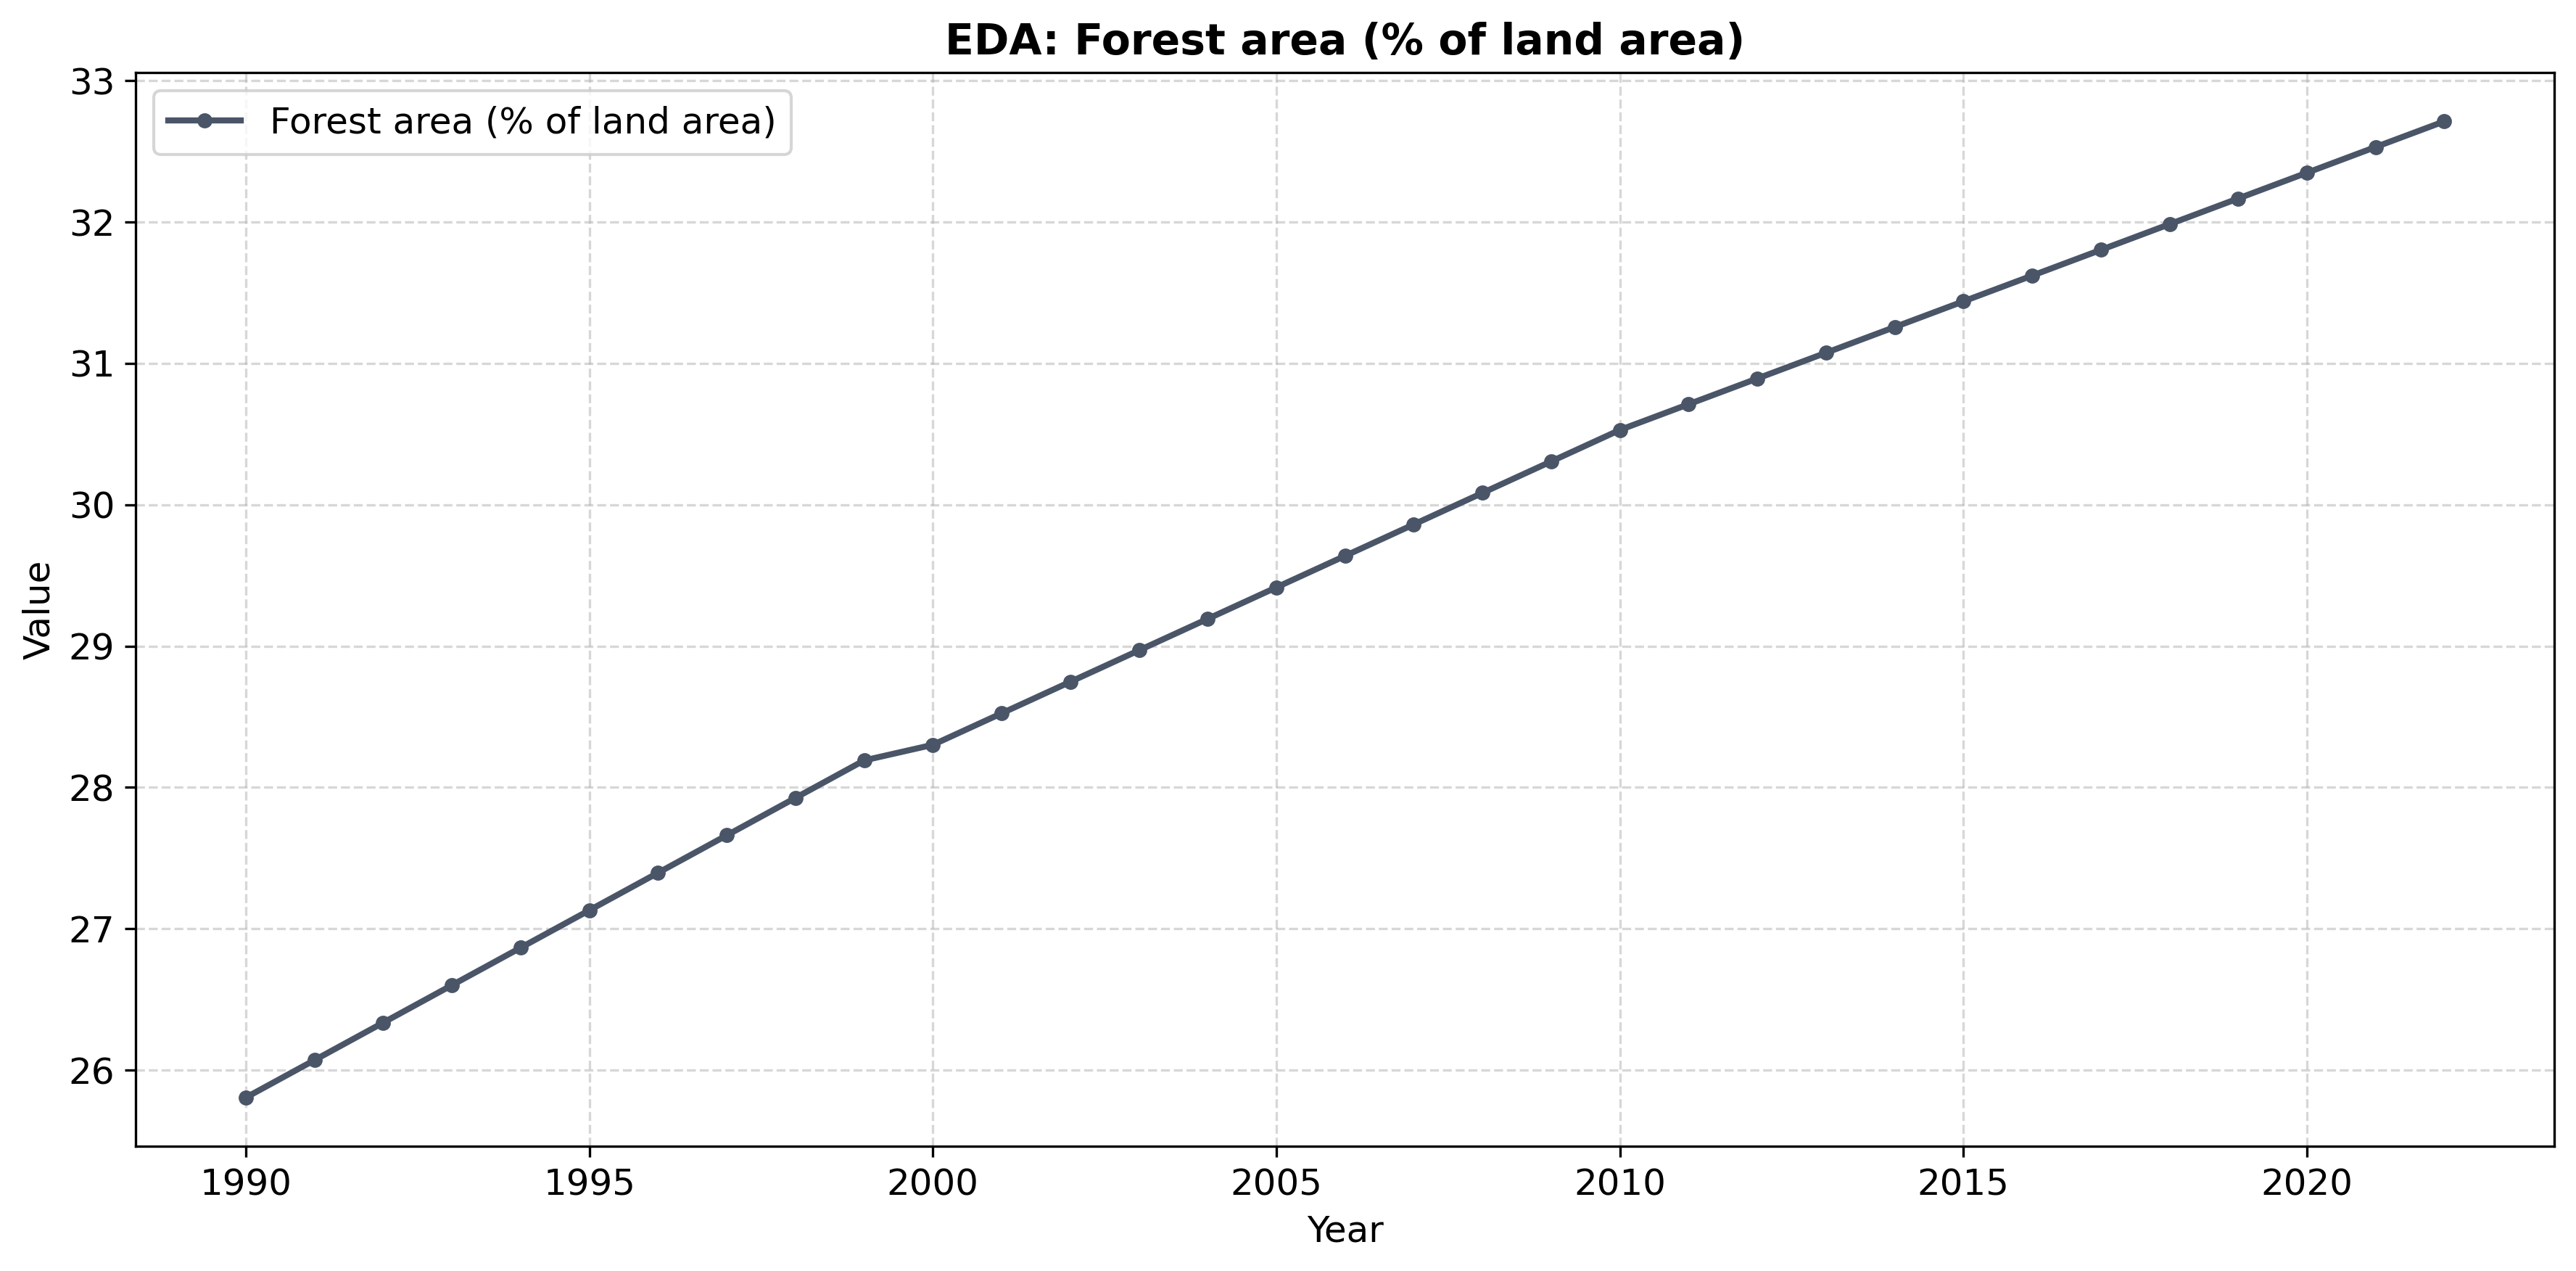

Saved: eda_forestarea_abs.png


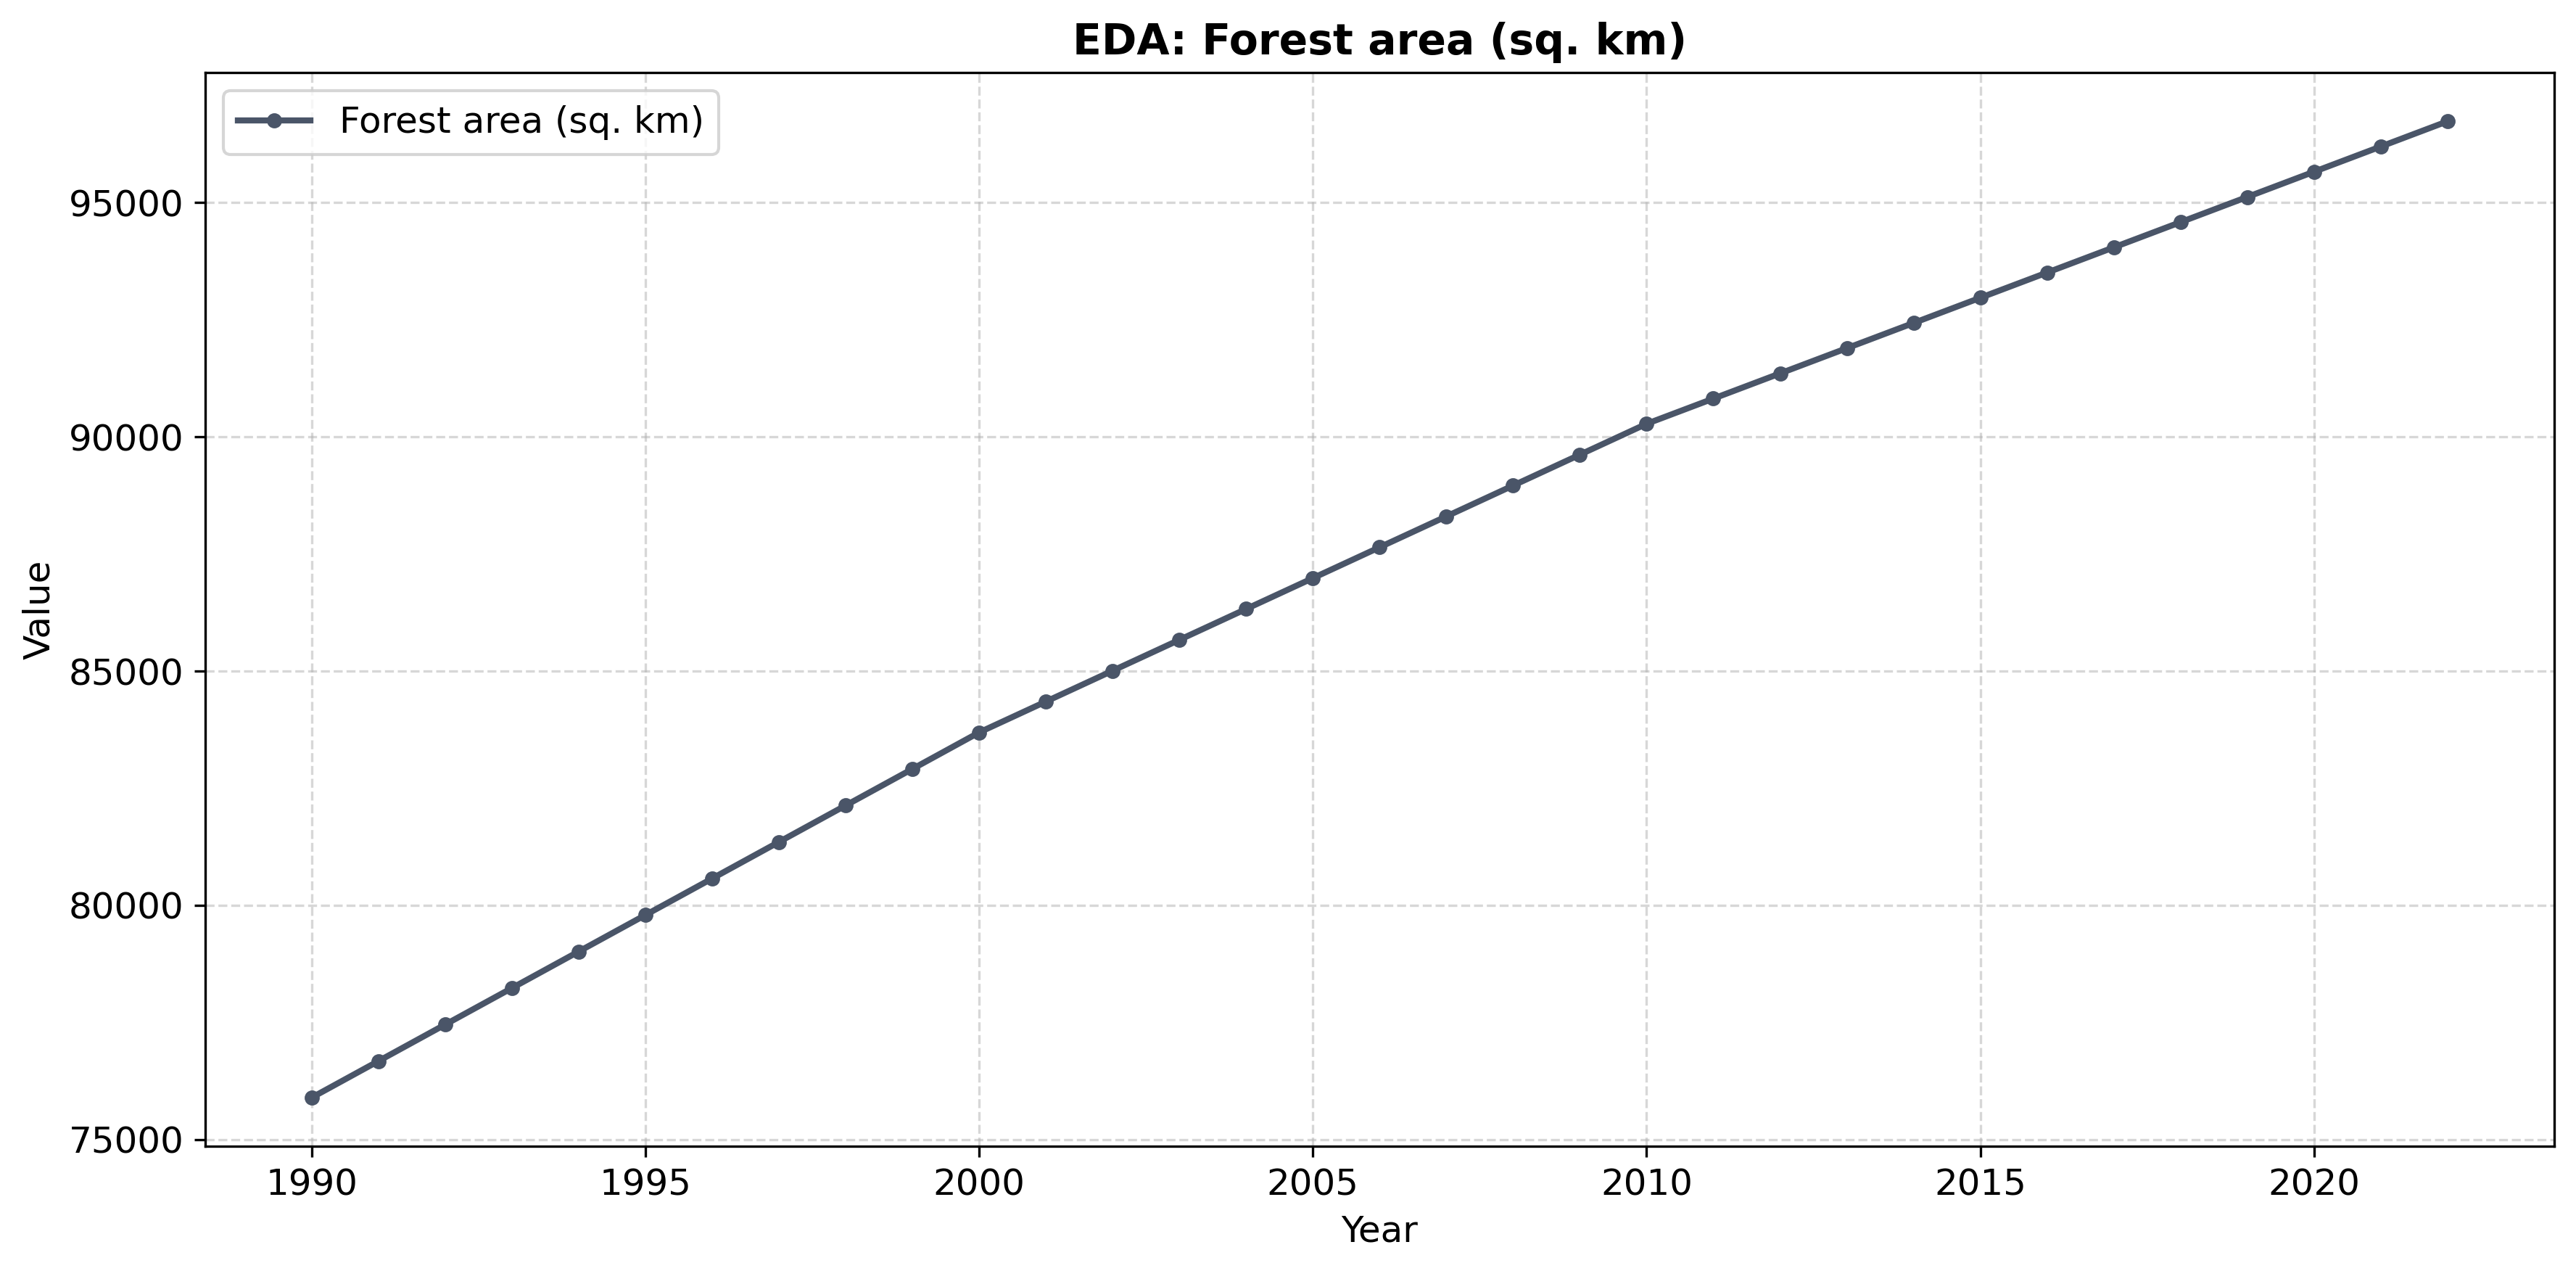

Saved: eda_cerealland_abs.png


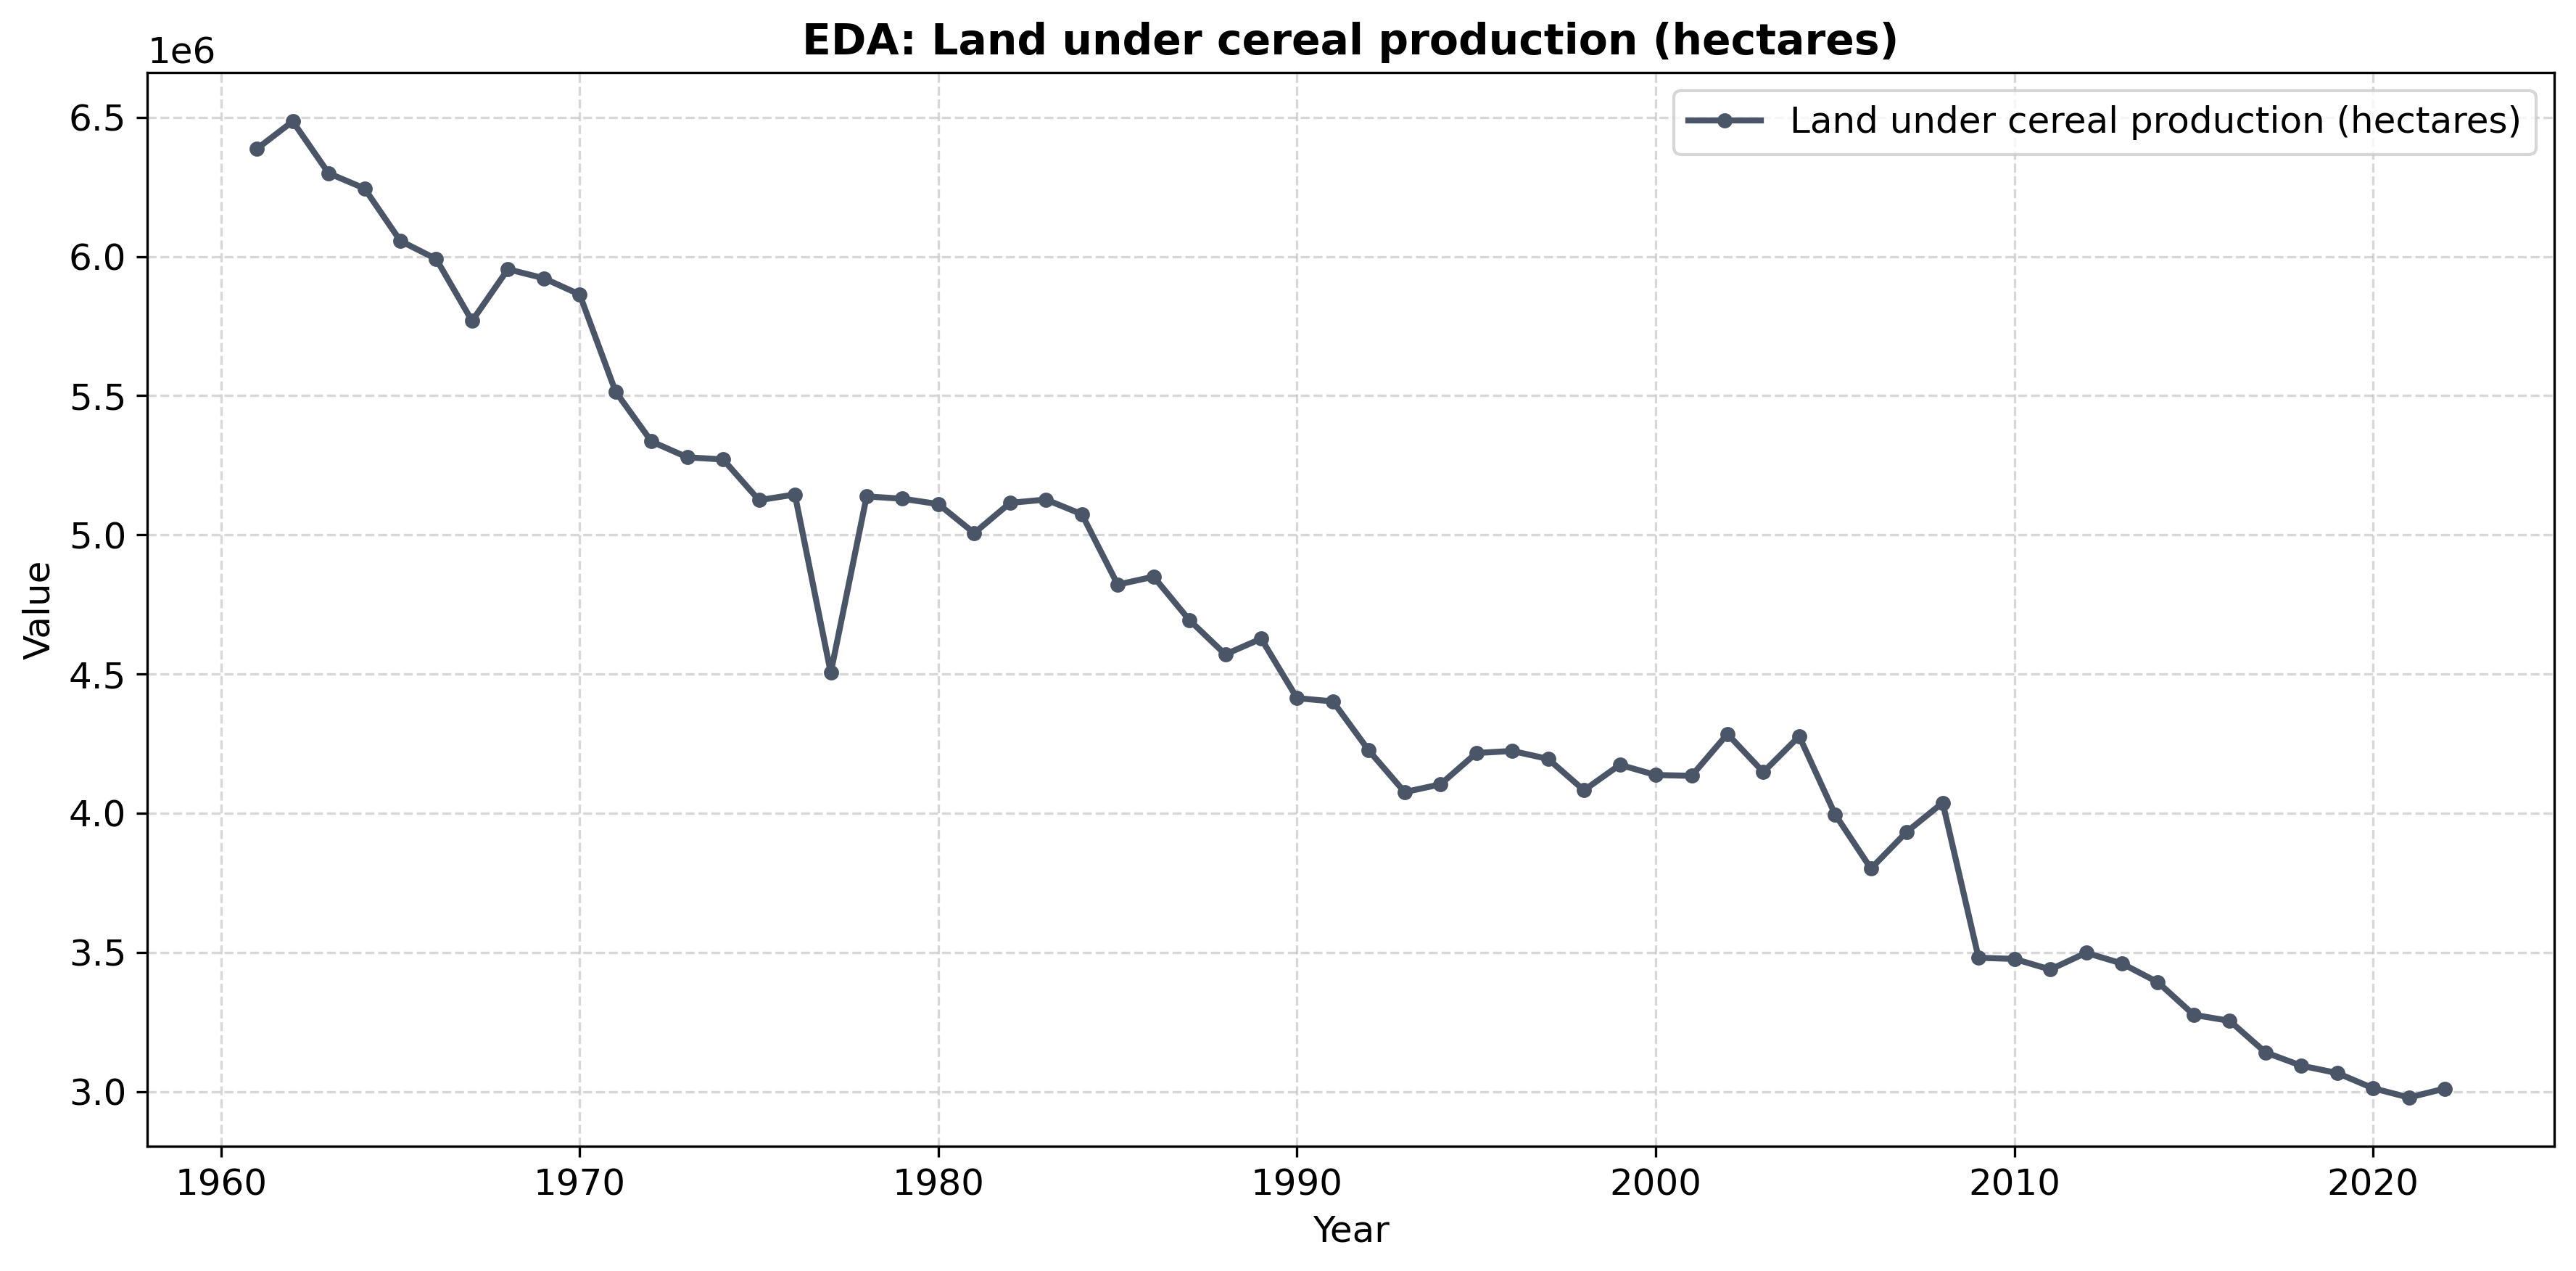

Saved: eda_livestock_production_index.png


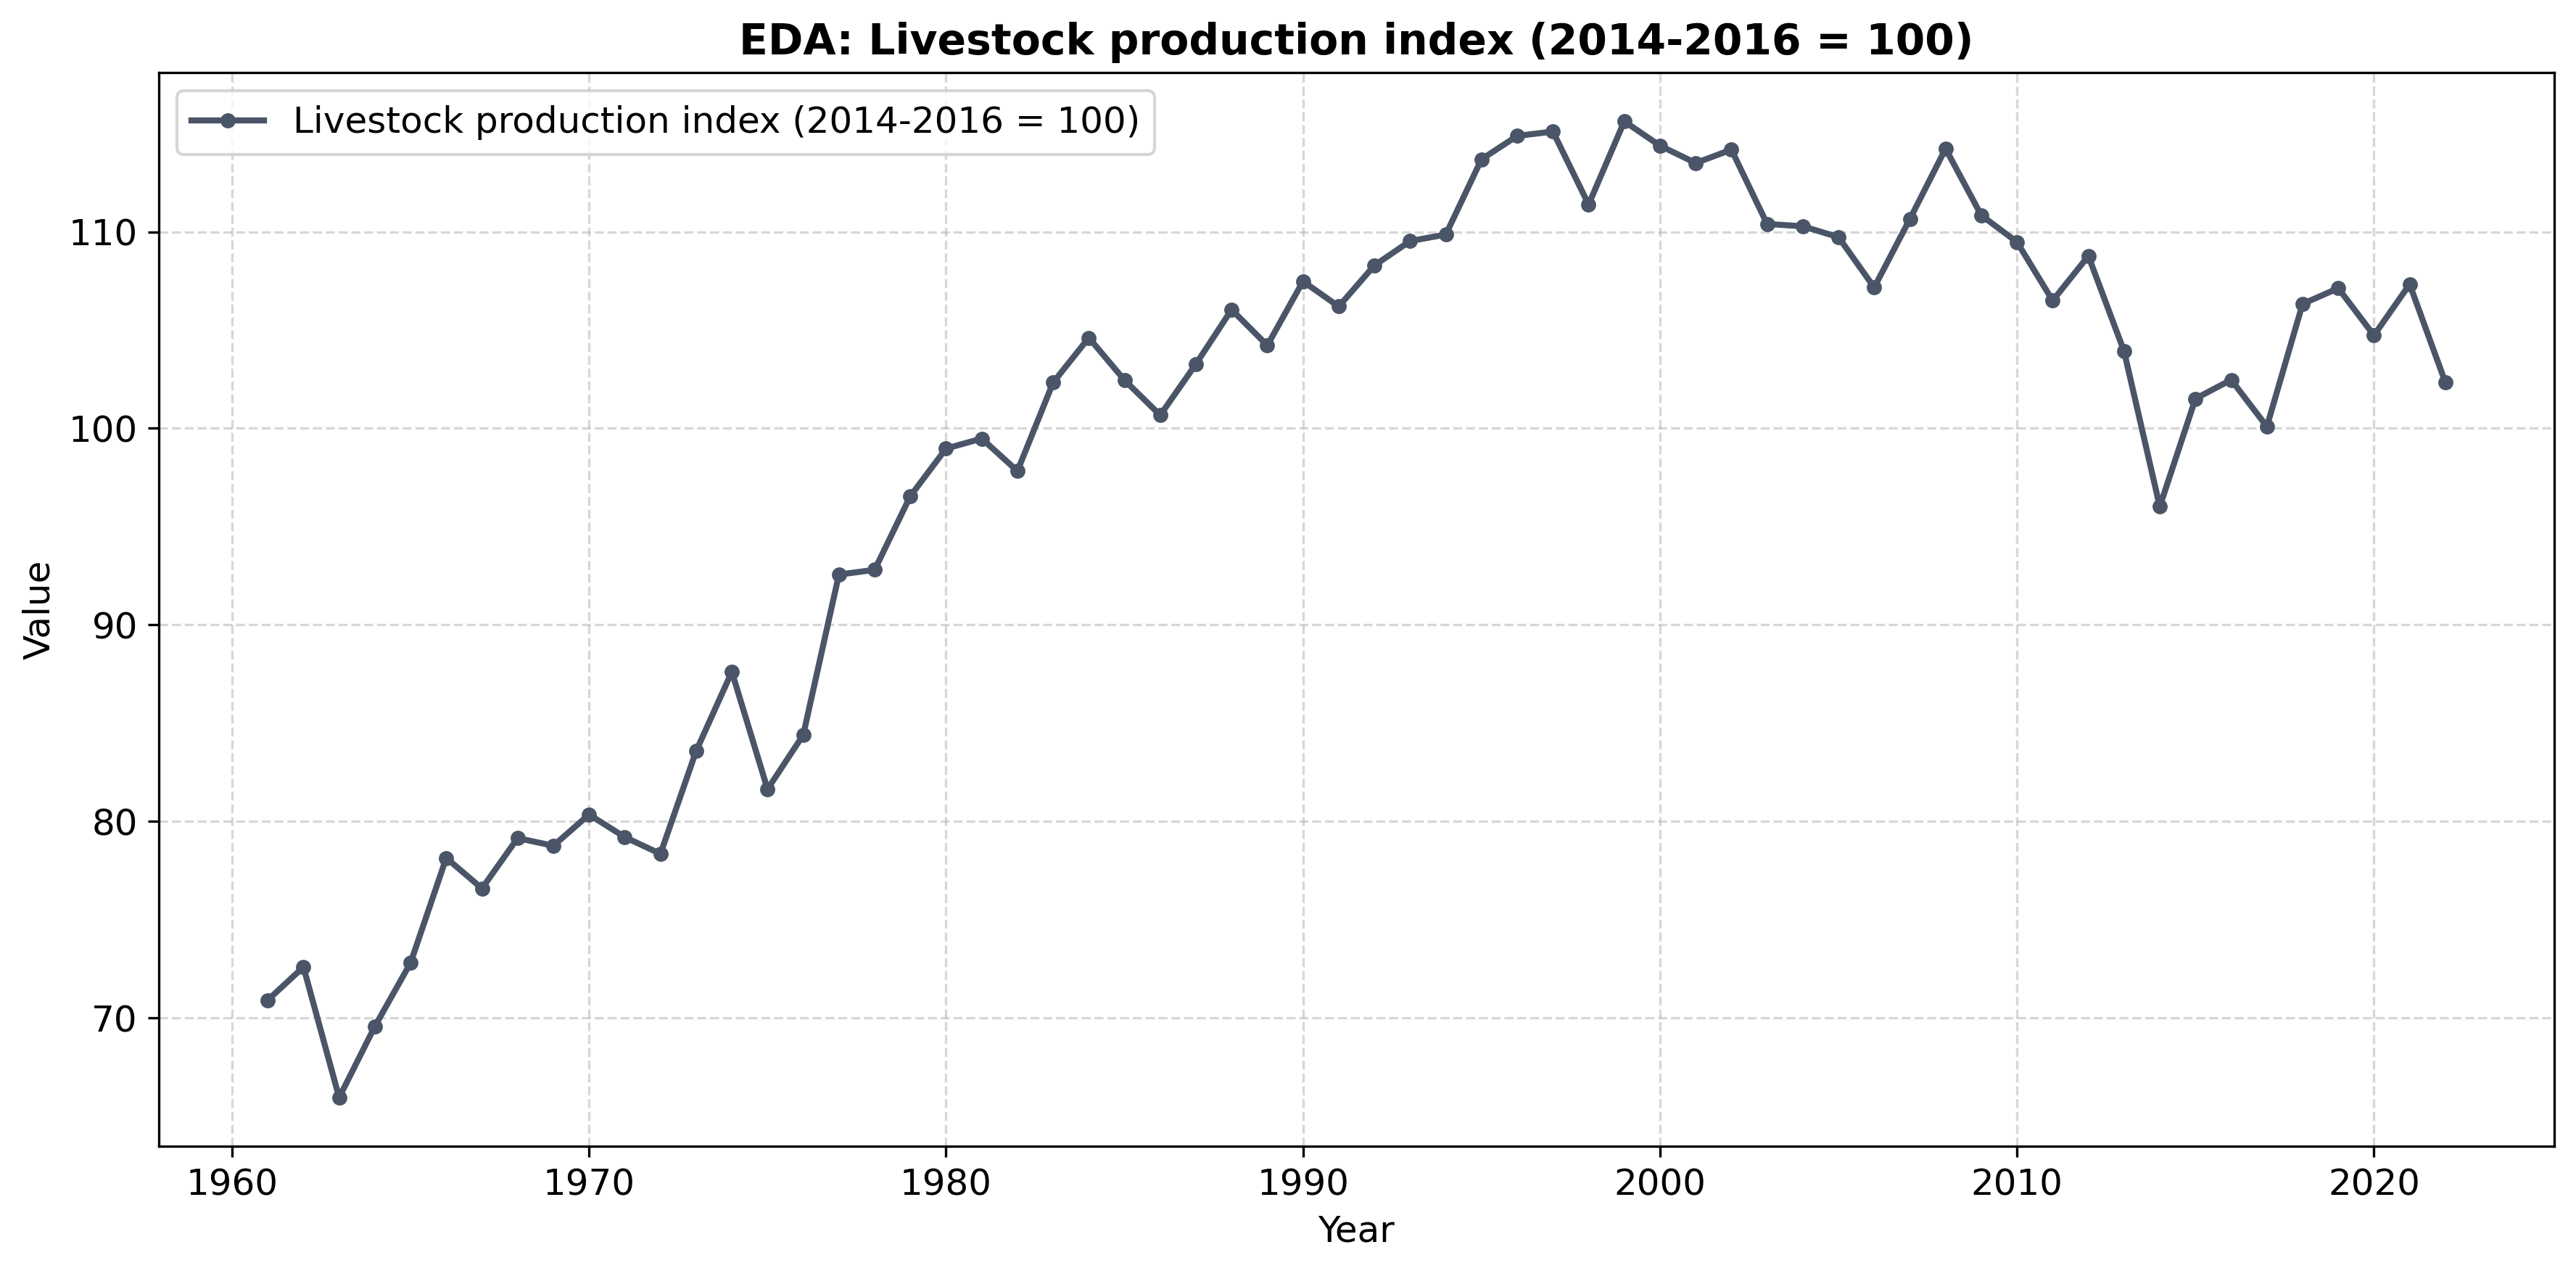

Saved: eda_cropland_percent.png


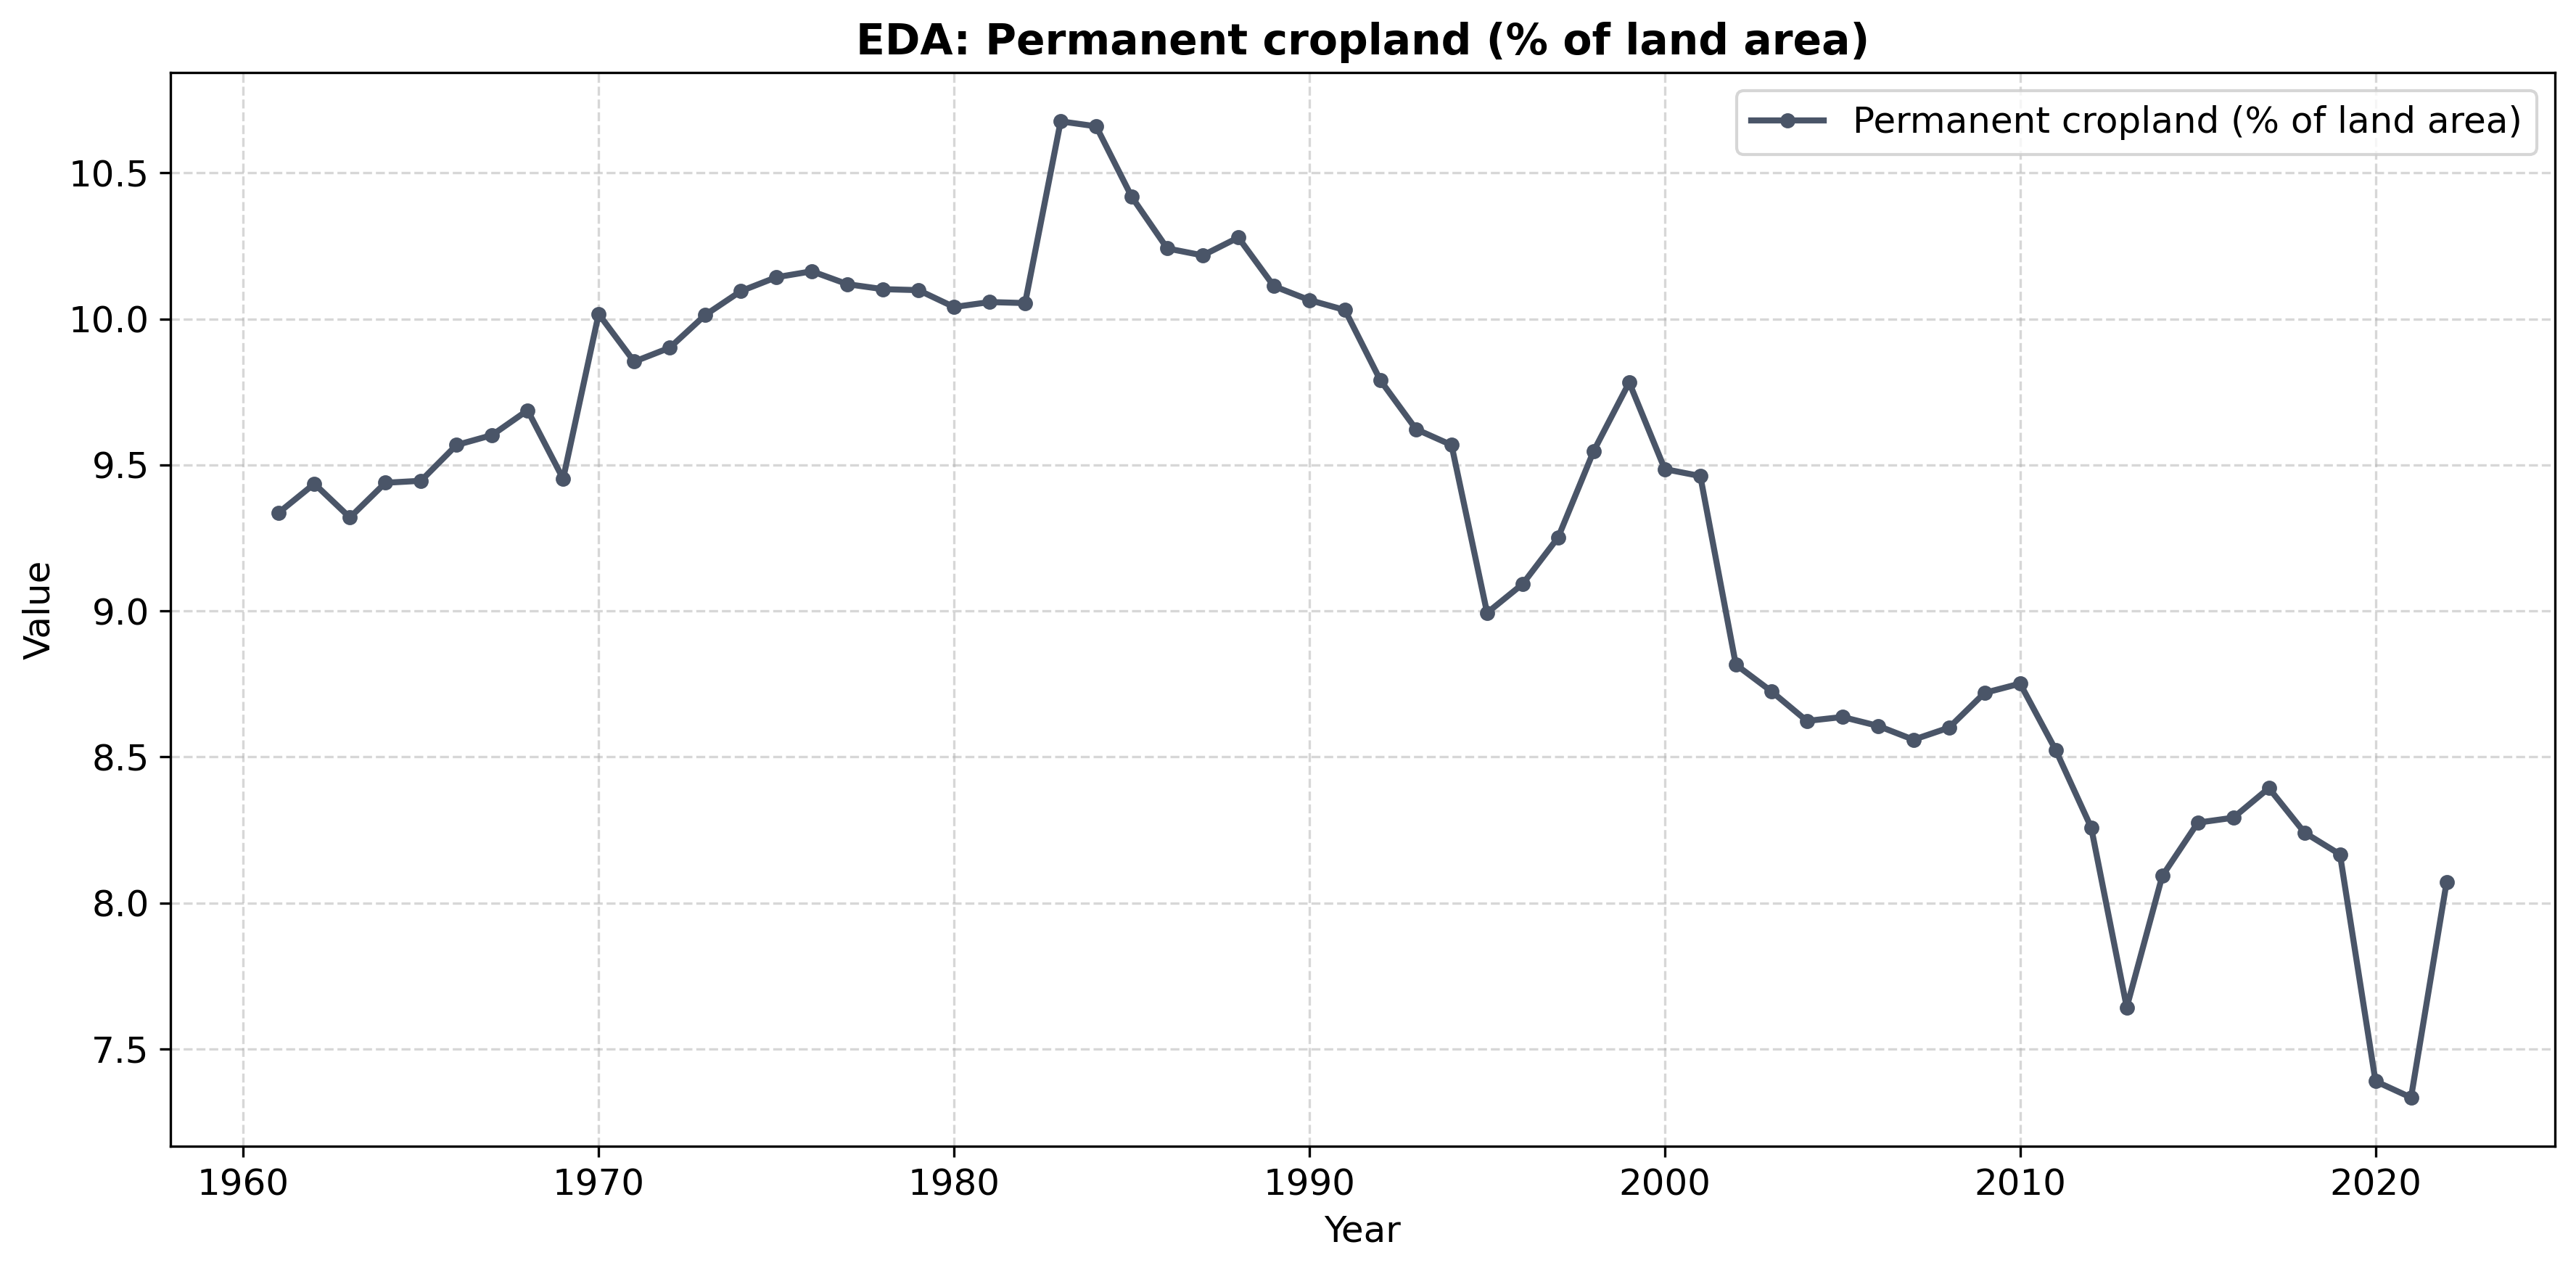

Saved: eda_population_abs.png


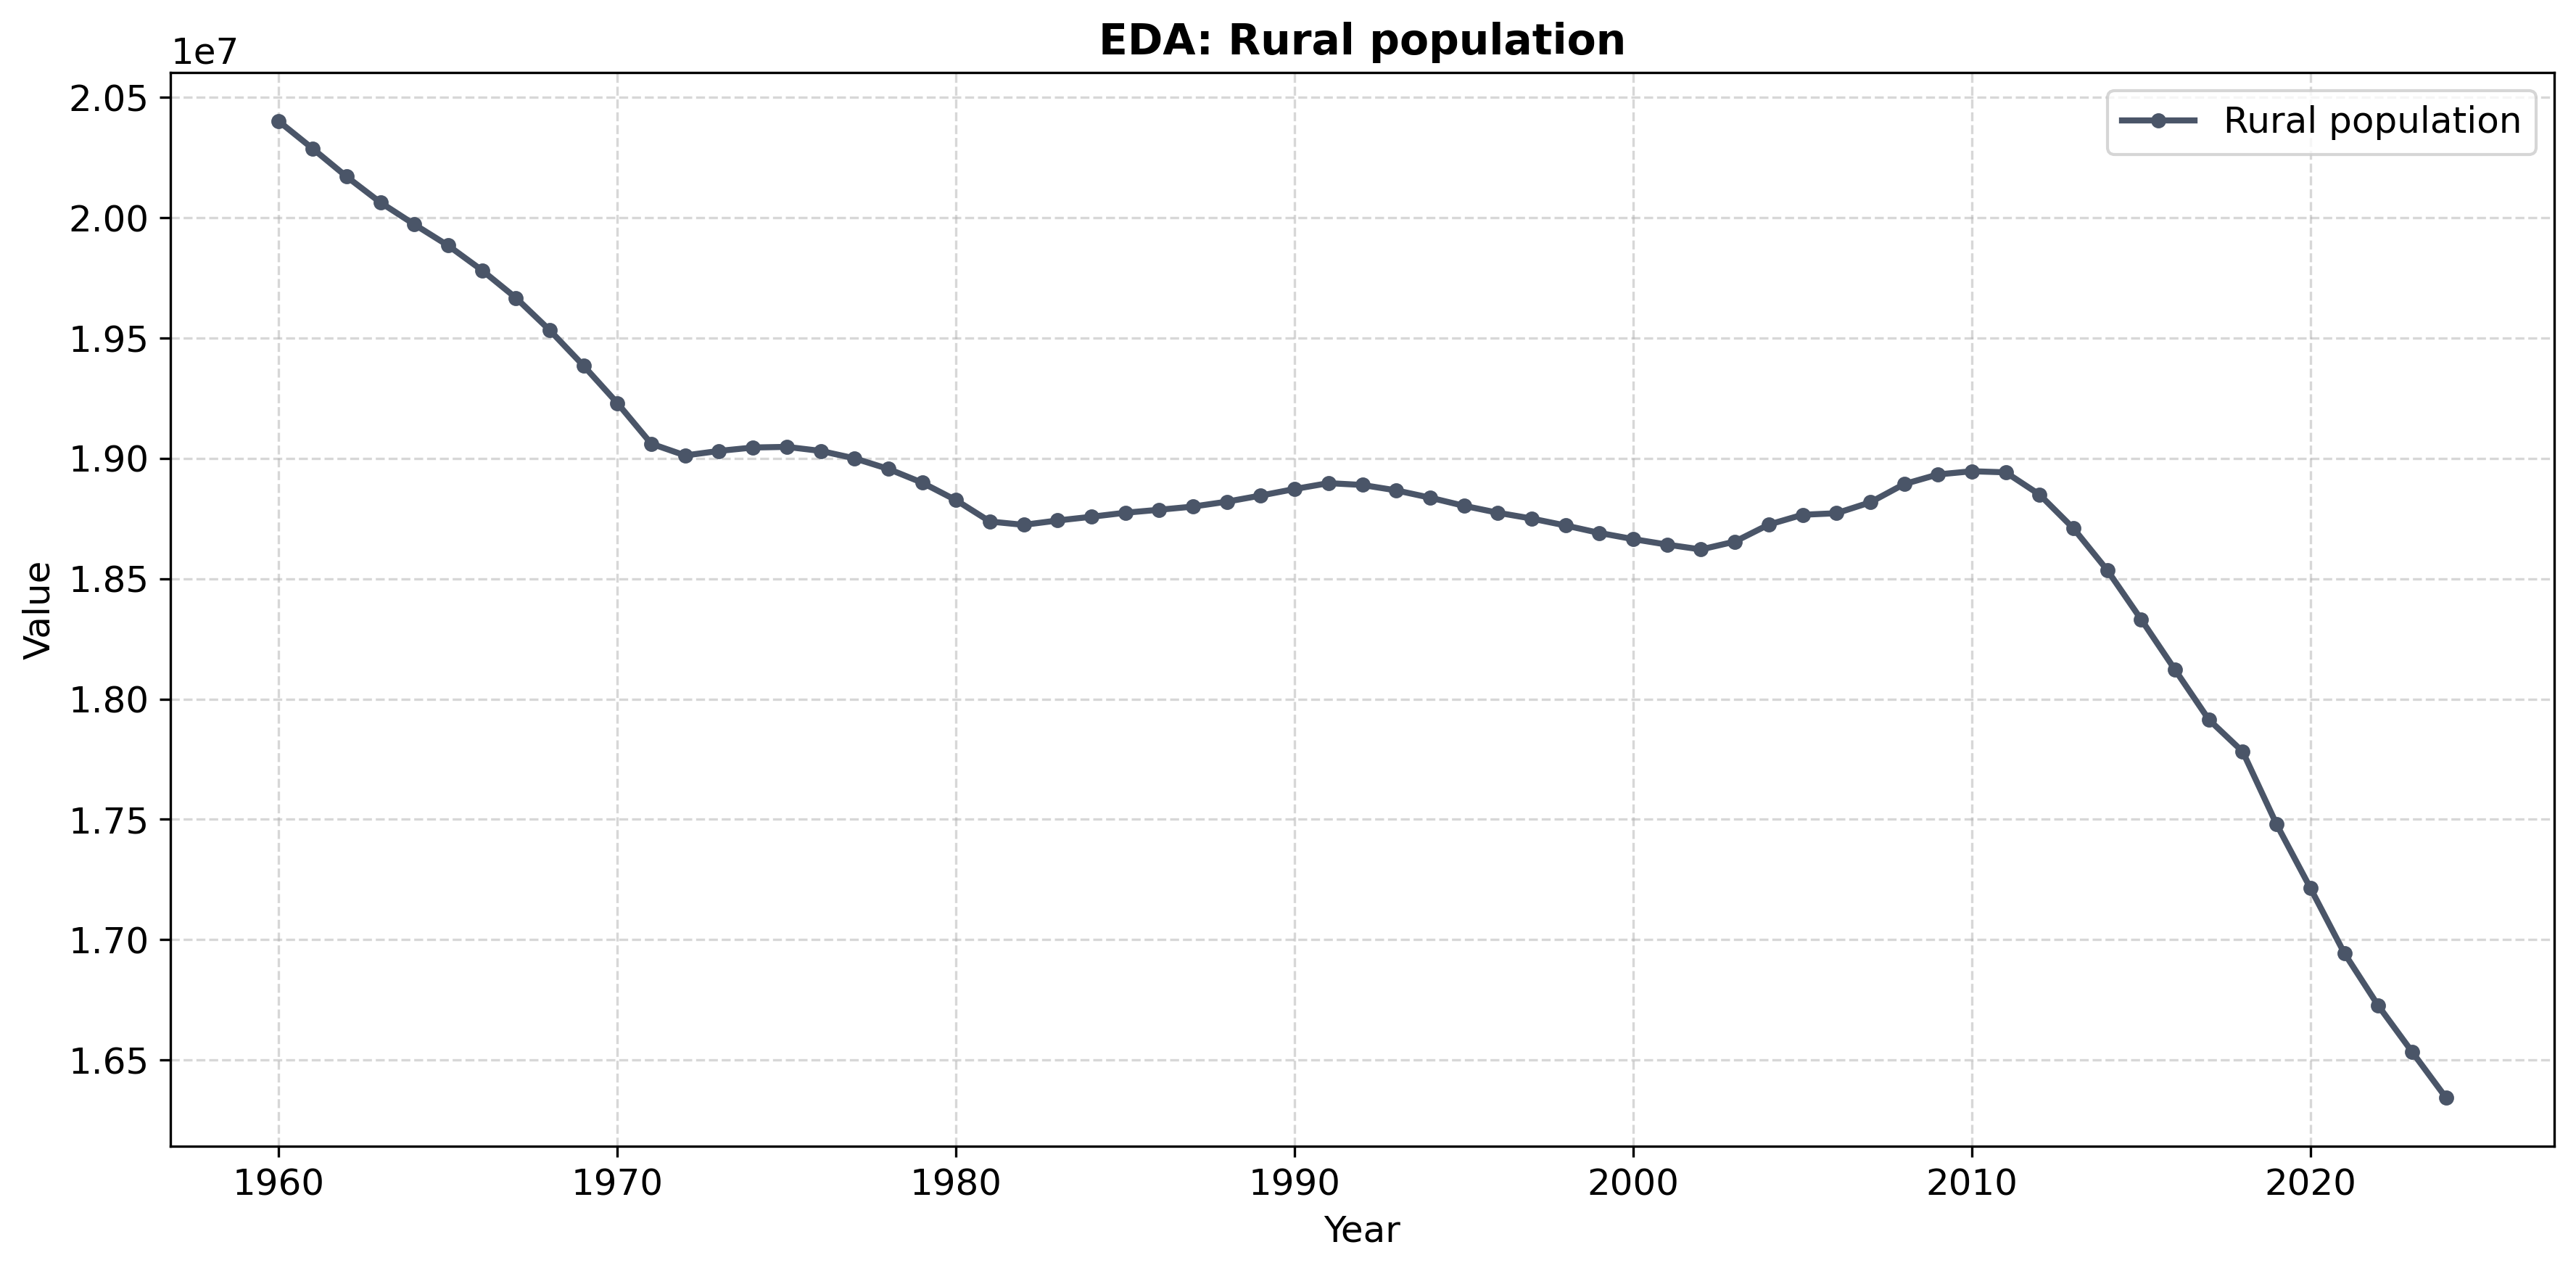

Saved: eda_population_percent.png


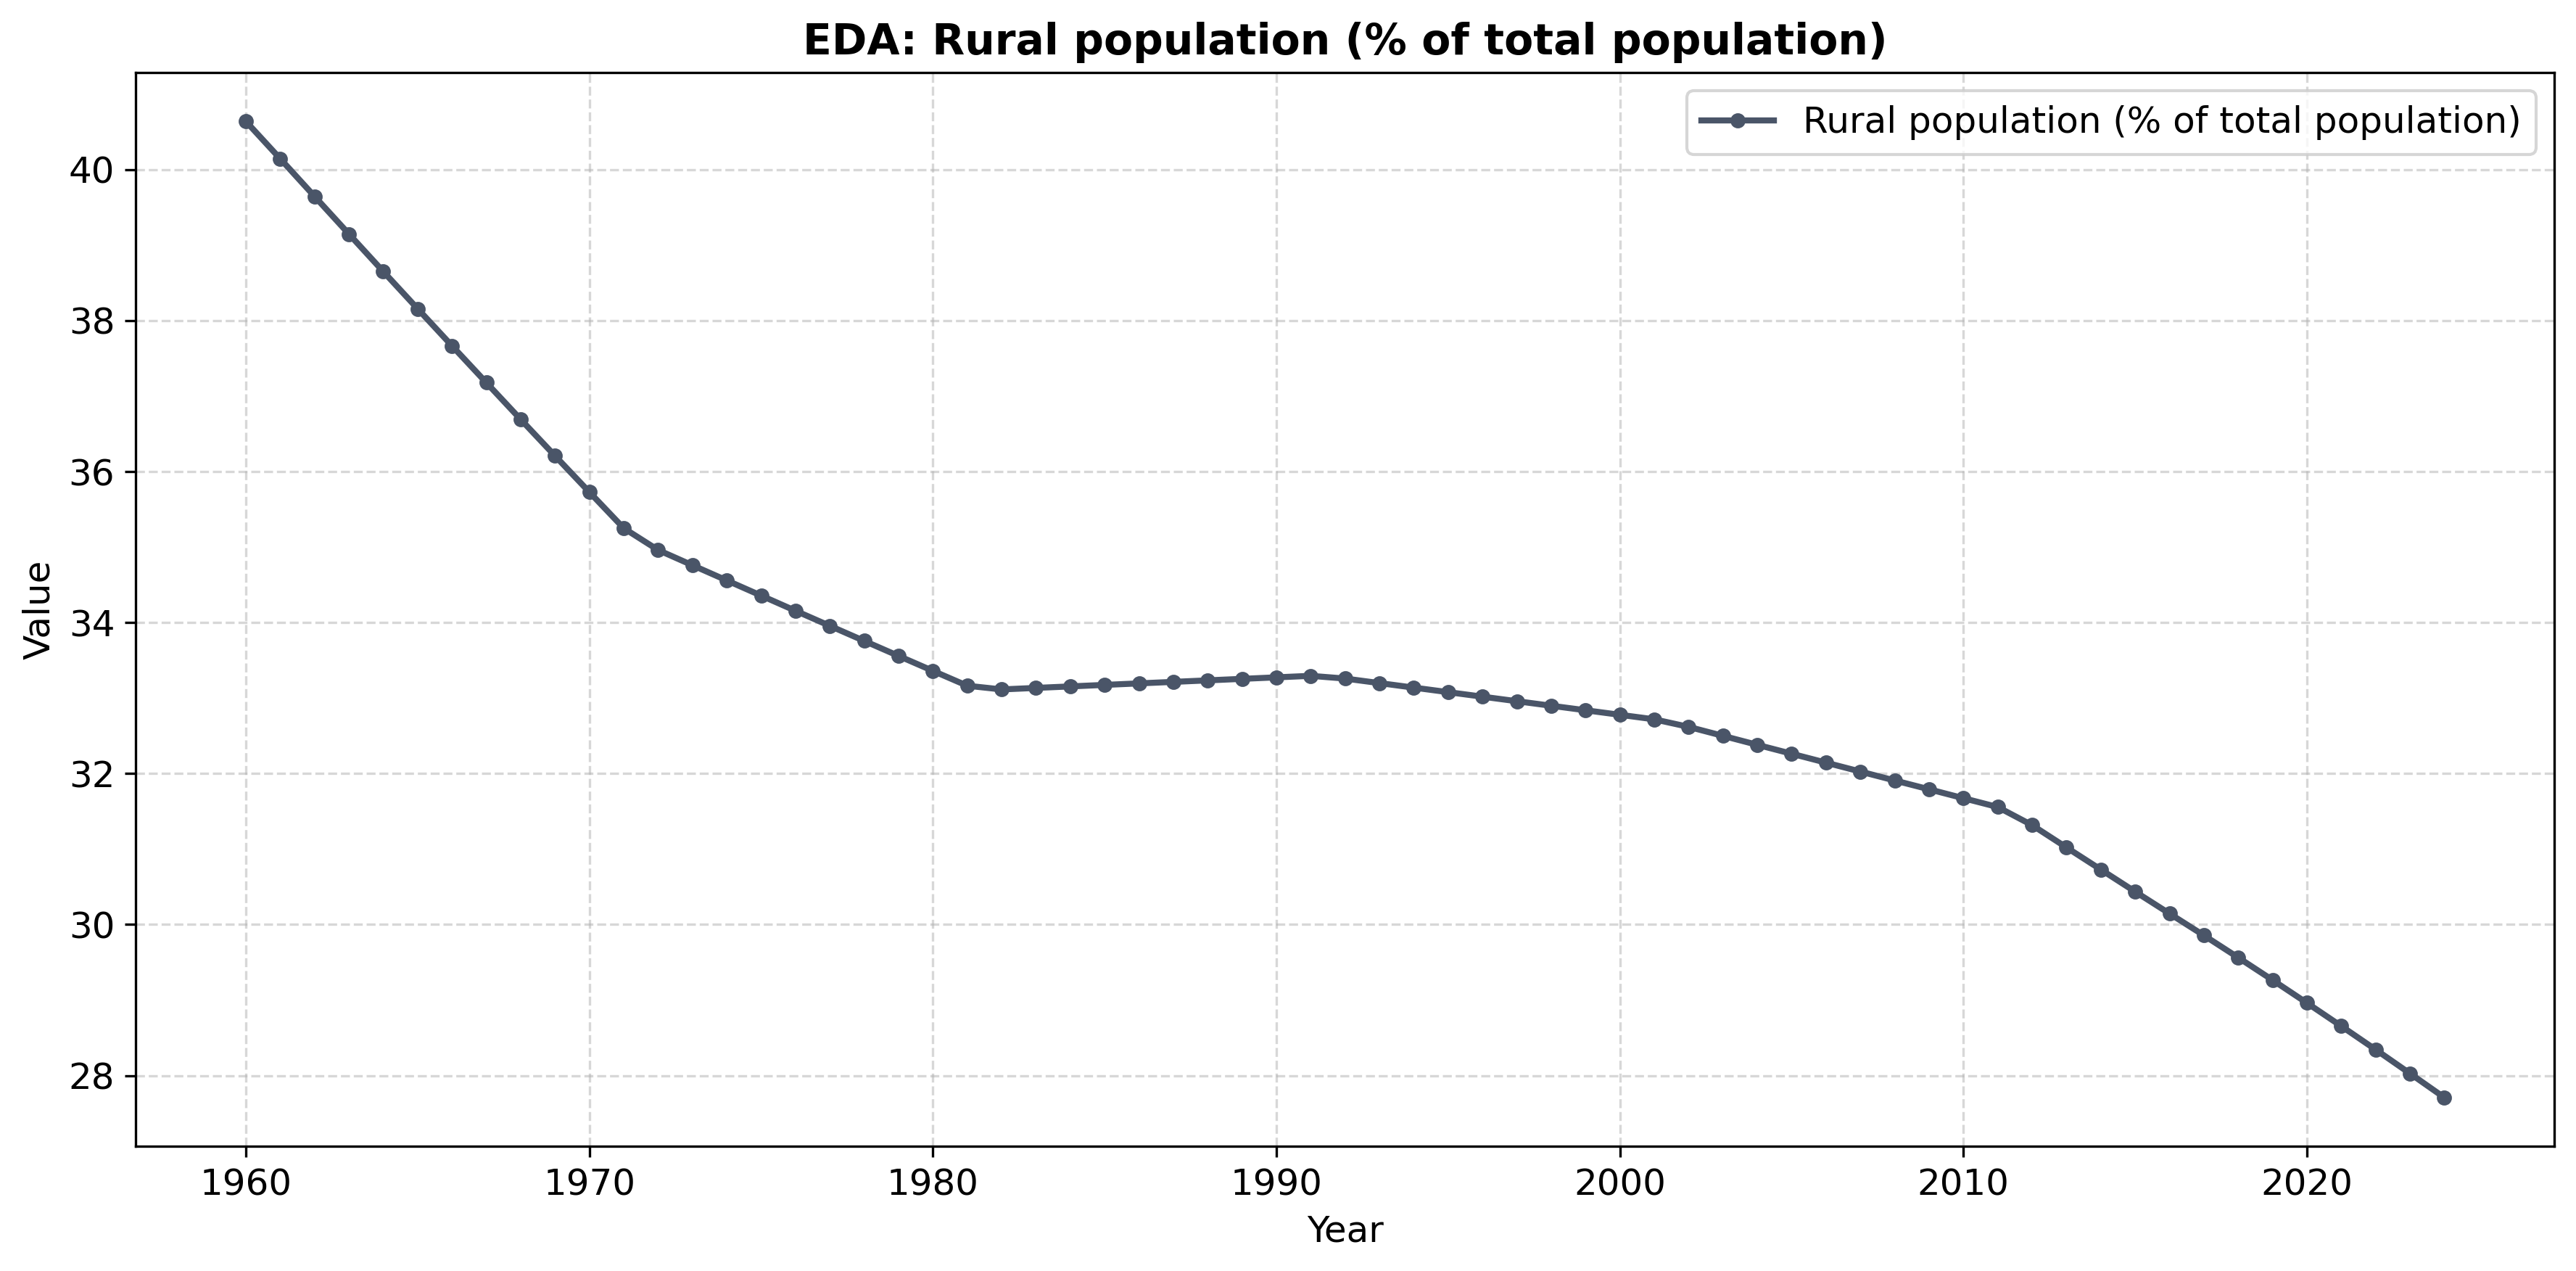

Saved: eda_population_growth.png


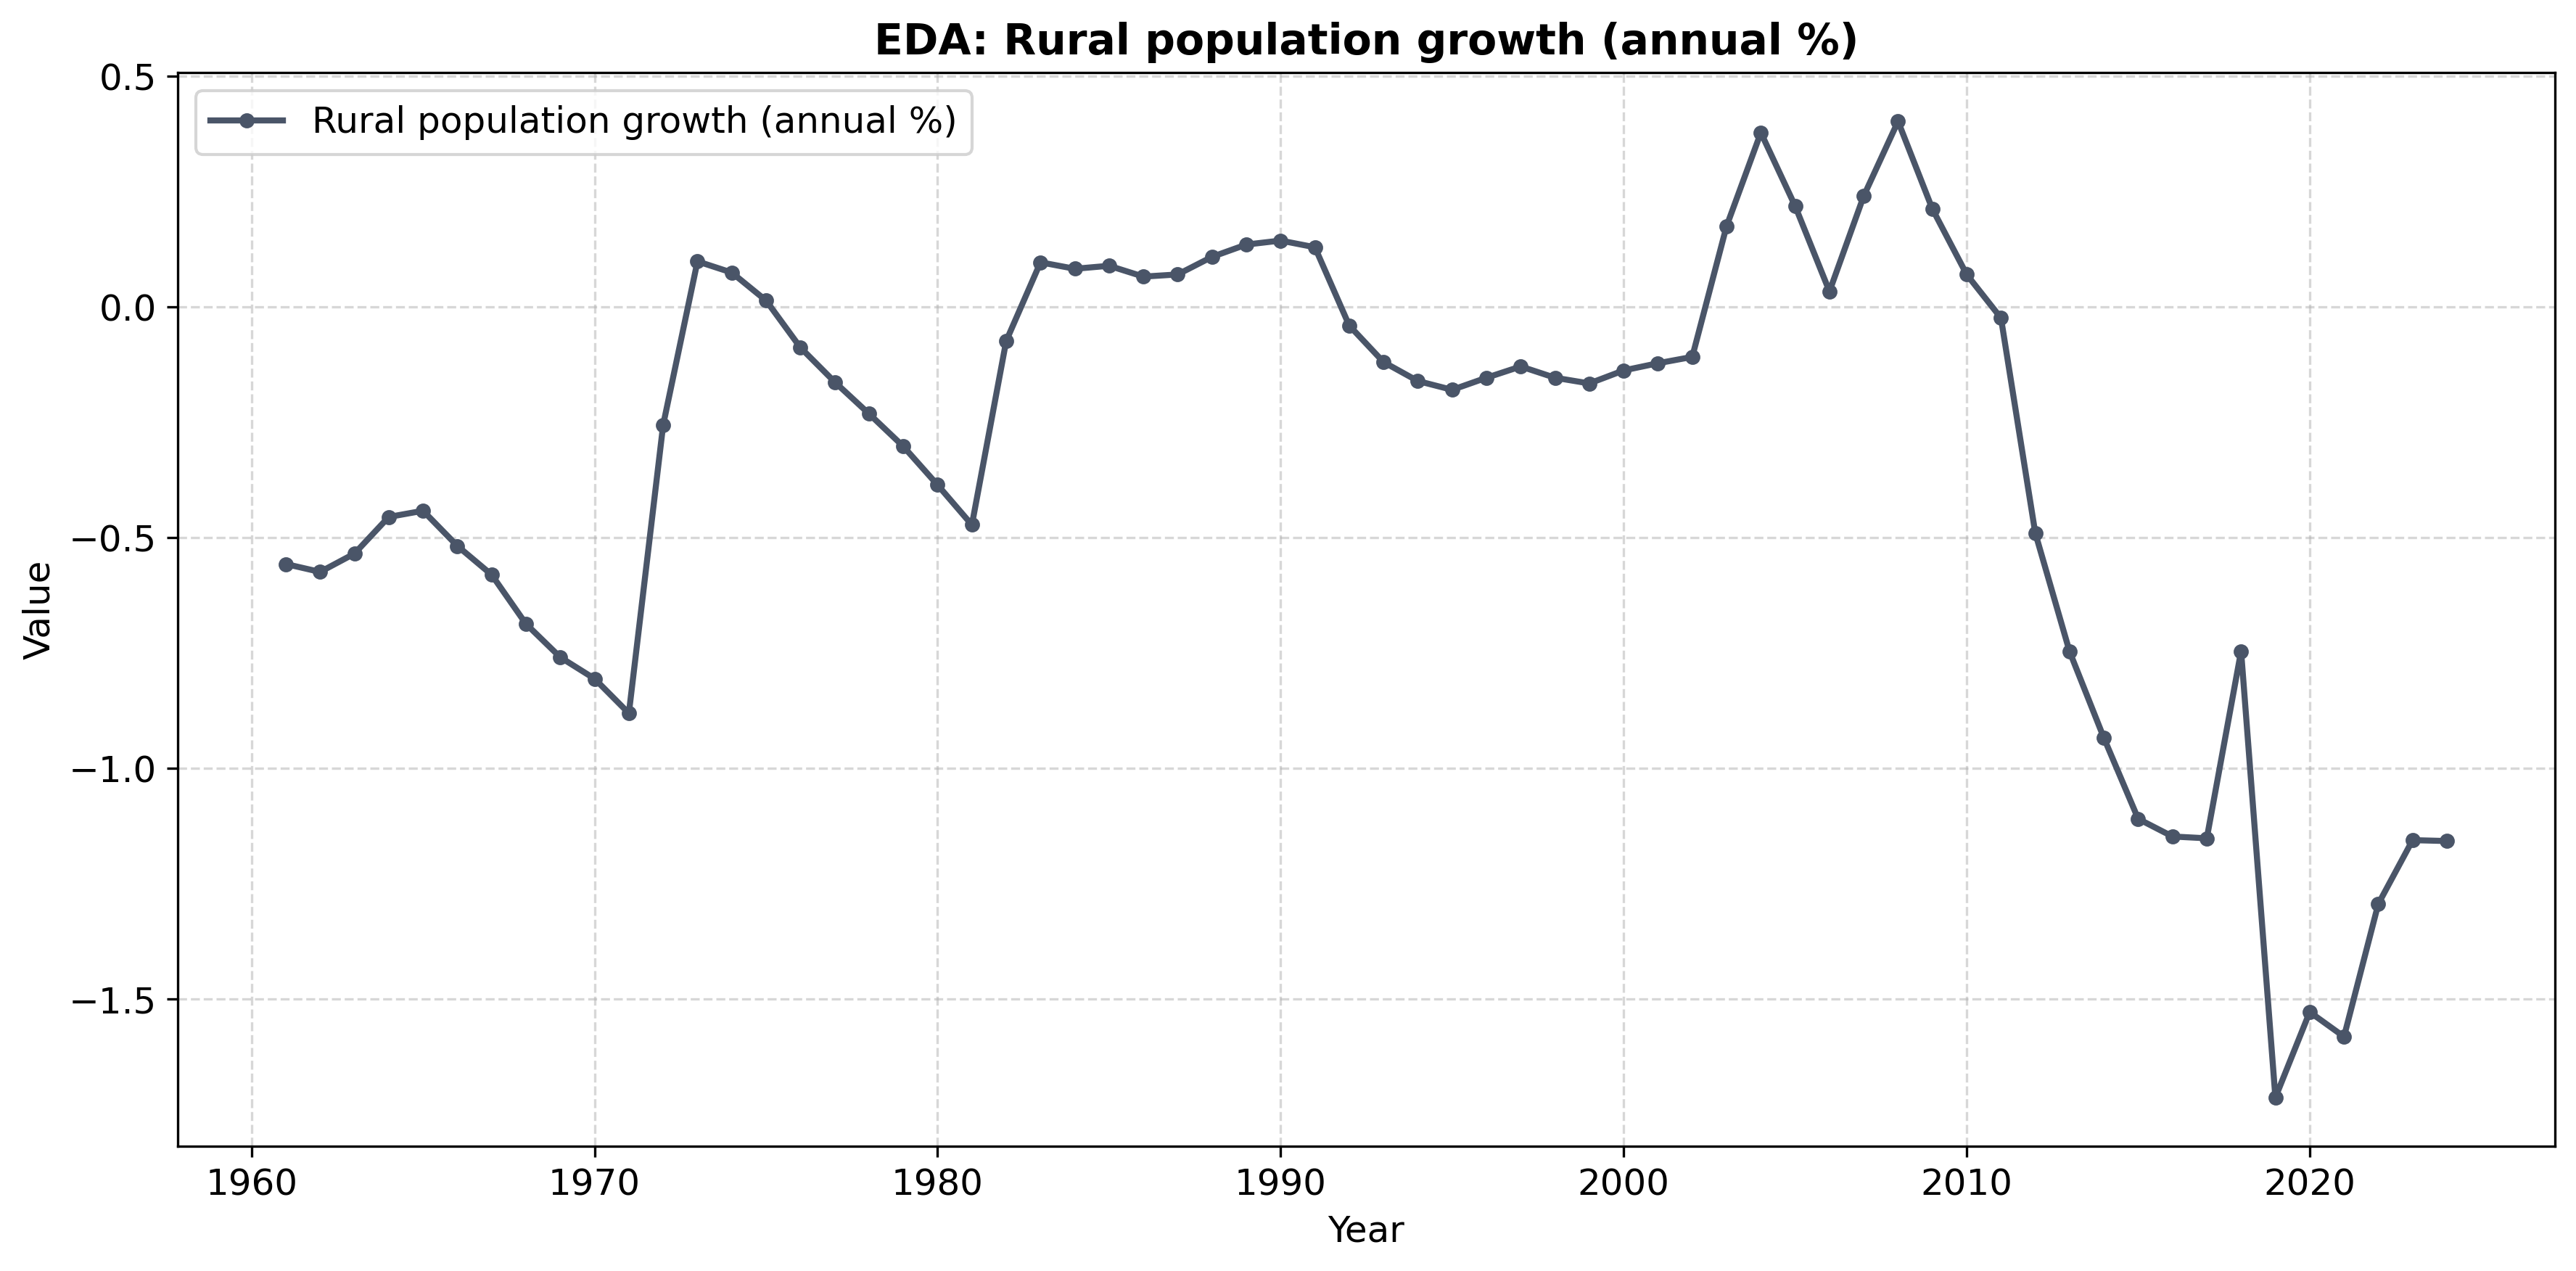

In [10]:
visual.plot_exploratory_time_series(
    df, 
    save_plots=True, 
    folder_name="00_EDA"
)

## <a id='toc1_4_'></a>[First attempt - plot of one variable](#toc0_)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

            value
NaT          4.00
NaT          1.00
1960-01-01    NaN
1961-01-01  70.91
1962-01-01  72.59


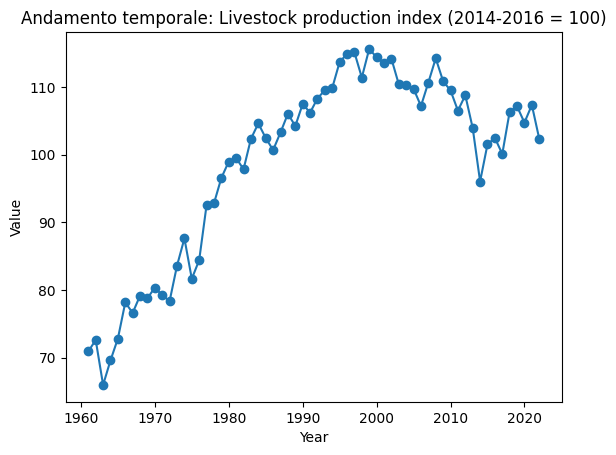

In [6]:
df = pd.read_excel("../COPY_rural_development_dataset.xlsx", sheet_name="Data")

proxy_name = "Livestock production index (2014-2016 = 100)"
country_name = "Italy"

row = df[(df['Indicator Name'] == proxy_name) & (df['Country Name'] == country_name)]

# Seleziona solo le colonne numeriche (anni)
values = row.select_dtypes(include=['number']).T
values.columns = ['value']

# Se ci sono intestazioni di anni come stringhe, le convertiamo in numeri o date
values.index = pd.to_datetime(values.index, errors='coerce', format='%Y')
print(values.head())

plt.plot(values.index, values['value'], marker='o')
plt.title(f"Andamento temporale: {proxy_name}")
plt.xlabel("Year")
plt.ylabel("Value")
plt.show()